# EDA — Thermal Drone YOLOv8 Dataset
### Calibrating a Target-Agnostic Diffusion Loss for Super-Resolution (ResShift / DifIISR)

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import glob
import os
import re
import json
import zipfile
from pathlib import Path
from scipy import signal, ndimage

%matplotlib inline
sns.set_style("whitegrid")
np.random.seed(42)

WORK_ROOT = Path(".")                                 # this notebook's folder: zip, new_dataset/, extracted/ cache and RESULTS/
CORRECTED_LABELS_ROOT = Path("..") / "annotations" / "corrected_yolo"   # train/valid/test labels (in the repo)
ZIP_PATH      = WORK_ROOT / "thermal-drone.v1i.yolov8.zip"             # Roboflow HR images, all splits
EXTRACT_DIR   = str(WORK_ROOT / "extracted" / "dataset")   # unzipped HR dataset (cache, not a result)
RESULTS_DIR   = str(WORK_ROOT / "RESULTS")
NEW_DATASET_DIR = WORK_ROOT / "new_dataset"           # exact_padded_float32-*.zip parts + manifest.csv — valid split only
MANIFEST_PATH   = NEW_DATASET_DIR / "manifest.csv"    # columns: stem, cropped_width, cropped_height
NPY_EXTRACT_DIR = WORK_ROOT / "extracted" / "difiisr_npy"   # DifIISR encoder-input NPYs (float32, CxHxW, padded)

os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Results directory ready: {os.path.abspath(RESULTS_DIR)}")


Results directory ready: C:\projects\drones\target-aware-infrared-sr\METRICS_EDA\RESULTS


## Cell 2 — Dataset Loading & ResShift Preprocessing
Extracts the ZIP once, discovers all splits (train/valid/test)

In [2]:

# ── Step 2a: Resolve the active dataset root ───────────────────────────────────
if not os.path.exists(EXTRACT_DIR):
    print("Extracting HR dataset ZIP...")
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(EXTRACT_DIR)
    print("Extraction complete.")
else:
    print(f"Using existing dataset: {EXTRACT_DIR}")


_STEM_RE = re.compile(r"^(.*?)_(?:jpg|png)\.rf\.")


def _extract_stem(filename: str) -> str:
    """Strip the Roboflow '_jpg.rf.<hash>' suffix — hashes differ between the image and label exports."""
    m = _STEM_RE.match(filename)
    return m.group(1) if m else filename


def _build_positional_label_index() -> dict:
    """Pair each image with a corrected label by (split, stem, sorted order) — full filenames don't match across exports."""
    index = {}
    for split_dir in sorted(glob.glob(os.path.join(EXTRACT_DIR, "*"))):
        split = os.path.basename(split_dir)
        img_dir = os.path.join(split_dir, "images")
        if not os.path.isdir(img_dir):
            continue
        label_dir = CORRECTED_LABELS_ROOT / split / "labels"

        imgs_by_stem = {}
        for fname in sorted(os.listdir(img_dir)):
            imgs_by_stem.setdefault(_extract_stem(fname), []).append(fname)

        labels_by_stem = {}
        if label_dir.exists():
            for fname in sorted(os.listdir(label_dir)):
                labels_by_stem.setdefault(_extract_stem(fname), []).append(fname)

        for stem, img_files in imgs_by_stem.items():
            label_files = labels_by_stem.get(stem, [])
            for img_fname, lbl_fname in zip(img_files, label_files):
                img_path = os.path.normpath(os.path.join(img_dir, img_fname))
                index[img_path] = str(label_dir / lbl_fname)
    return index


_LABEL_PATH_INDEX = _build_positional_label_index()


def _build_label_path(img_path: str) -> str:
    """Look up the positionally-paired corrected label — returns '' (no match) if the image has no paired label."""
    return _LABEL_PATH_INDEX.get(os.path.normpath(img_path), "")


def _parse_yolo_labels(label_path: str, H: int, W: int):
    """Return list of pixel BBoxes (x1,y1,x2,y2); skip degenerate boxes."""
    bboxes = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            _, cx, cy, bw, bh = map(float, parts[:5])
            px_cx, px_cy = cx * W, cy * H
            px_w,  px_h  = bw * W, bh * H
            x1 = int(px_cx - px_w / 2);  x2 = int(px_cx + px_w / 2)
            y1 = int(px_cy - px_h / 2);  y2 = int(px_cy + px_h / 2)
            # [C2] clip to image bounds
            x1, x2 = int(np.clip(x1, 0, W)), int(np.clip(x2, 0, W))
            y1, y2 = int(np.clip(y1, 0, H)), int(np.clip(y2, 0, H))
            # [C6] skip degenerate boxes
            if (x2 - x1) < 2 or (y2 - y1) < 2:
                continue
            bboxes.append((x1, y1, x2, y2, px_cx, px_cy, px_w, px_h))
    return bboxes


def process_image(img_path: str):
    """Return path + valid bboxes for one image, or None if it has none."""
    label_path = _build_label_path(img_path)
    # [C6] skip missing or empty label files
    if not os.path.exists(label_path) or os.path.getsize(label_path) == 0:
        return None

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    H, W = img.shape

    raw_boxes = _parse_yolo_labels(label_path, H, W)
    if not raw_boxes:
        return None

    bboxes = [(x1, y1, x2, y2) for (x1, y1, x2, y2, *_rest) in raw_boxes]

    return {
        "path":   img_path,
        "bboxes": bboxes,
    }


# ── Step 2b: Discover all images across train/valid/test ──────────────────────
img_paths = sorted(
    glob.glob(os.path.join(EXTRACT_DIR, "**", "images", "*.jpg"), recursive=True) +
    glob.glob(os.path.join(EXTRACT_DIR, "**", "images", "*.png"), recursive=True)
)

# ── Step 2c: Run pipeline + collect pure-background paths ────────────────────
# bg_only_paths: empty-label images — crops deferred to Cell 3 (size matched to median drone bbox)
dataset, bg_only_paths, skipped = [], [], 0
for img_path in img_paths:
    lp = _build_label_path(img_path)
    if os.path.exists(lp) and os.path.getsize(lp) == 0:
        bg_only_paths.append(img_path)
        continue
    record = process_image(img_path)
    if record:
        dataset.append(record)
    else:
        skipped += 1


total_targets = sum(len(r["bboxes"]) for r in dataset)
print(f"Loaded  : {len(dataset)} images  ({total_targets} valid targets)")
print(f"BG-only : {len(bg_only_paths)} pure-background images (crops deferred to Cell 3)")
print(f"Skipped : {skipped} images (no label / degenerate bbox)")

Extracting HR dataset ZIP...


Extraction complete.


Loaded  : 6104 images  (6108 valid targets)
BG-only : 927 pure-background images (crops deferred to Cell 3)
Skipped : 1 images (no label / degenerate bbox)


In [3]:
# Diagnostic: break down skip reasons
reason_no_label   = 0
reason_empty_label = 0
reason_no_valid_bbox = 0
reason_bad_image  = 0

for p in img_paths:
    lp = _build_label_path(p)
    if not os.path.exists(lp):
        reason_no_label += 1
        continue
    if os.path.getsize(lp) == 0:
        reason_empty_label += 1
        continue
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is None:
        reason_bad_image += 1
        continue
    H, W = img.shape
    boxes = _parse_yolo_labels(lp, H, W)
    if not boxes:
        reason_no_valid_bbox += 1

print(f"No label file found : {reason_no_label}")
print(f"Empty label file    : {reason_empty_label}")
print(f"All BBoxes degenerate (w/h < 2px): {reason_no_valid_bbox}")
print(f"Unreadable image    : {reason_bad_image}")
print(f"Total skipped       : {reason_no_label + reason_empty_label + reason_no_valid_bbox + reason_bad_image}")

No label file found : 0
Empty label file    : 927
All BBoxes degenerate (w/h < 2px): 1
Unreadable image    : 0
Total skipped       : 928


## Cell 3 — Morphological Size Analysis
Computes drone target dimensions and derives `recommended_kernel_size` from the
bbox area distribution (percentiles, mean/median, histogram) for use in Cell 4.

Drone target area percentiles (physical range = distance variation):
  P 5  →         30 px²   (side ≈    5.5 px)
  P10  →         40 px²   (side ≈    6.3 px)
  P25  →        112 px²   (side ≈   10.6 px)
  P50  →        496 px²   (side ≈   22.3 px)
  P75  →       1680 px²   (side ≈   41.0 px)
  P90  →       4955 px²   (side ≈   70.4 px)
  P95  →       9476 px²   (side ≈   97.3 px)
  P99  →      25137 px²   (side ≈  158.5 px)

mean_drone_size    = 2352 px²  (pulled high by close-range targets)
median_drone_size  = 496 px²  (representative of typical target)
recommended_kernel_size = 23 px  (median-based, odd)


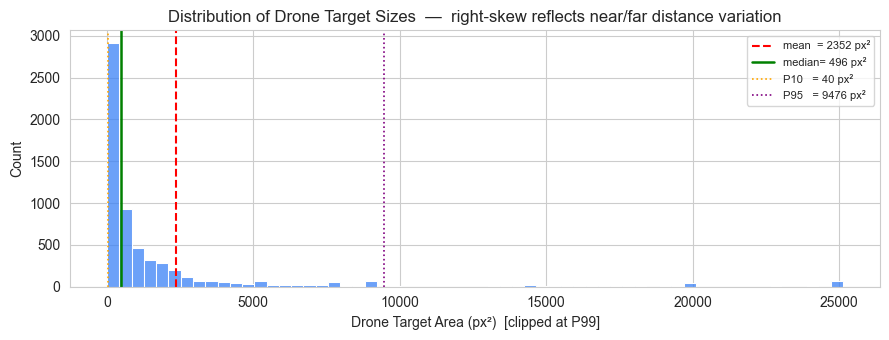

In [4]:
# ── 3a: Collect BBox dimensions ───────────────────────────────────────────────
widths, heights, areas, aspects = [], [], [], []
for rec in dataset:
    for (x1, y1, x2, y2) in rec["bboxes"]:
        w, h = x2 - x1, y2 - y1
        widths.append(w);  heights.append(h)
        areas.append(w * h)
        aspects.append(w / h if h > 0 else 0)

areas   = np.array(areas)
widths  = np.array(widths)
heights = np.array(heights)

mean_drone_size   = float(np.mean(areas))
median_drone_size = float(np.median(areas))
min_drone_size    = float(np.min(areas))

# Percentile table — documents full scale range (near/far drones)
pcts = [5, 10, 25, 50, 75, 90, 95, 99]
pct_vals = np.percentile(areas, pcts)
print("Drone target area percentiles (physical range = distance variation):")
for p, v in zip(pcts, pct_vals):
    print(f"  P{p:>2}  →  {v:>9.0f} px²   (side ≈ {np.sqrt(v):>6.1f} px)")

median_side = float(np.sqrt(median_drone_size))
mean_side   = float(np.mean(np.sqrt(areas)))
# median-based kernel is robust to near/far outliers
recommended_kernel_size = max(3, int(median_side // 2) * 2 + 1)

print(f"\nmean_drone_size    = {mean_drone_size:.0f} px²  (pulled high by close-range targets)")
print(f"median_drone_size  = {median_drone_size:.0f} px²  (representative of typical target)")
print(f"recommended_kernel_size = {recommended_kernel_size} px  (median-based, odd)")

# ── 3b: Histogram — full distribution preserved as documented finding ─────────
fig, ax = plt.subplots(figsize=(9, 3.5))
display_areas = areas[areas <= pct_vals[-1]]  # clip at P99 to avoid axis collapse
sns.histplot(display_areas, bins=60, ax=ax, color="#3b82f6", edgecolor="white")
ax.axvline(mean_drone_size,   color="red",    ls="--", lw=1.5, label=f"mean  = {mean_drone_size:.0f} px²")
ax.axvline(median_drone_size, color="green",  ls="-",  lw=1.8, label=f"median= {median_drone_size:.0f} px²")
ax.axvline(pct_vals[1],       color="orange", ls=":",  lw=1.2, label=f"P10   = {pct_vals[1]:.0f} px²")
ax.axvline(pct_vals[-2],      color="purple", ls=":",  lw=1.2, label=f"P95   = {pct_vals[-2]:.0f} px²")
ax.set_xlabel("Drone Target Area (px²)  [clipped at P99]")
ax.set_ylabel("Count")
ax.set_title("Distribution of Drone Target Sizes  —  right-skew reflects near/far distance variation")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "cell3_size_histogram.png"), dpi=150)
plt.show()

## Cell 3d — Biggest Drone Examples & Label Class Distribution
Shows the largest drone bboxes (by area) cropped from source images, and tallies
which annotation classes actually appear in the corrected labels.

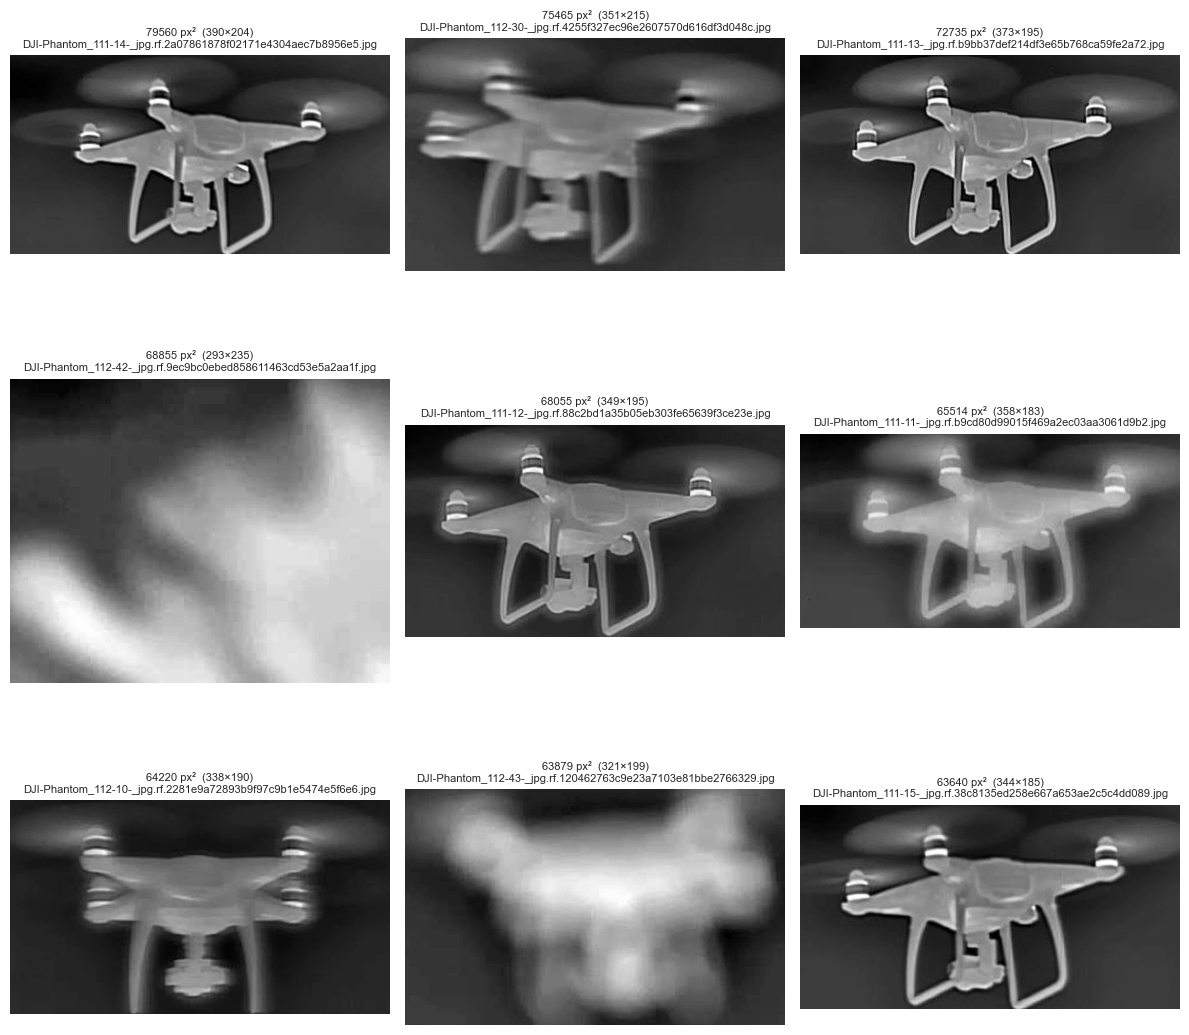

Biggest drone targets (by bbox area):
      79560 px²   390×204   DJI-Phantom_111-14-_jpg.rf.2a07861878f02171e4304aec7b8956e5.jpg
      75465 px²   351×215   DJI-Phantom_112-30-_jpg.rf.4255f327ec96e2607570d616df3d048c.jpg
      72735 px²   373×195   DJI-Phantom_111-13-_jpg.rf.b9bb37def214df3e65b768ca59fe2a72.jpg
      68855 px²   293×235   DJI-Phantom_112-42-_jpg.rf.9ec9bc0ebed858611463cd53e5a2aa1f.jpg
      68055 px²   349×195   DJI-Phantom_111-12-_jpg.rf.88c2bd1a35b05eb303fe65639f3ce23e.jpg
      65514 px²   358×183   DJI-Phantom_111-11-_jpg.rf.b9cd80d99015f469a2ec03aa3061d9b2.jpg
      64220 px²   338×190   DJI-Phantom_112-10-_jpg.rf.2281e9a72893b9f97c9b1e5474e5f6e6.jpg
      63879 px²   321×199   DJI-Phantom_112-43-_jpg.rf.120462763c9e23a7103e81bbe2766329.jpg
      63640 px²   344×185   DJI-Phantom_111-15-_jpg.rf.38c8135ed258e667a653ae2c5c4dd089.jpg



Label classes present in corrected_yolo annotations:
  class  0 (0              ) : 3011 boxes
  class  1 (DJI-Phantom    ) : 505 boxes
  class  2 (DRONE          ) : 1168 boxes
  class  3 (drone-thermal  ) : 64 boxes
  class  4 (fpv-drone      ) : 1333 boxes
  class  5 (ufo-thermal    ) : 28 boxes

Drone examples (all classes, incl. class 0) : 6109
Non-drone examples (pure-background images) : 927


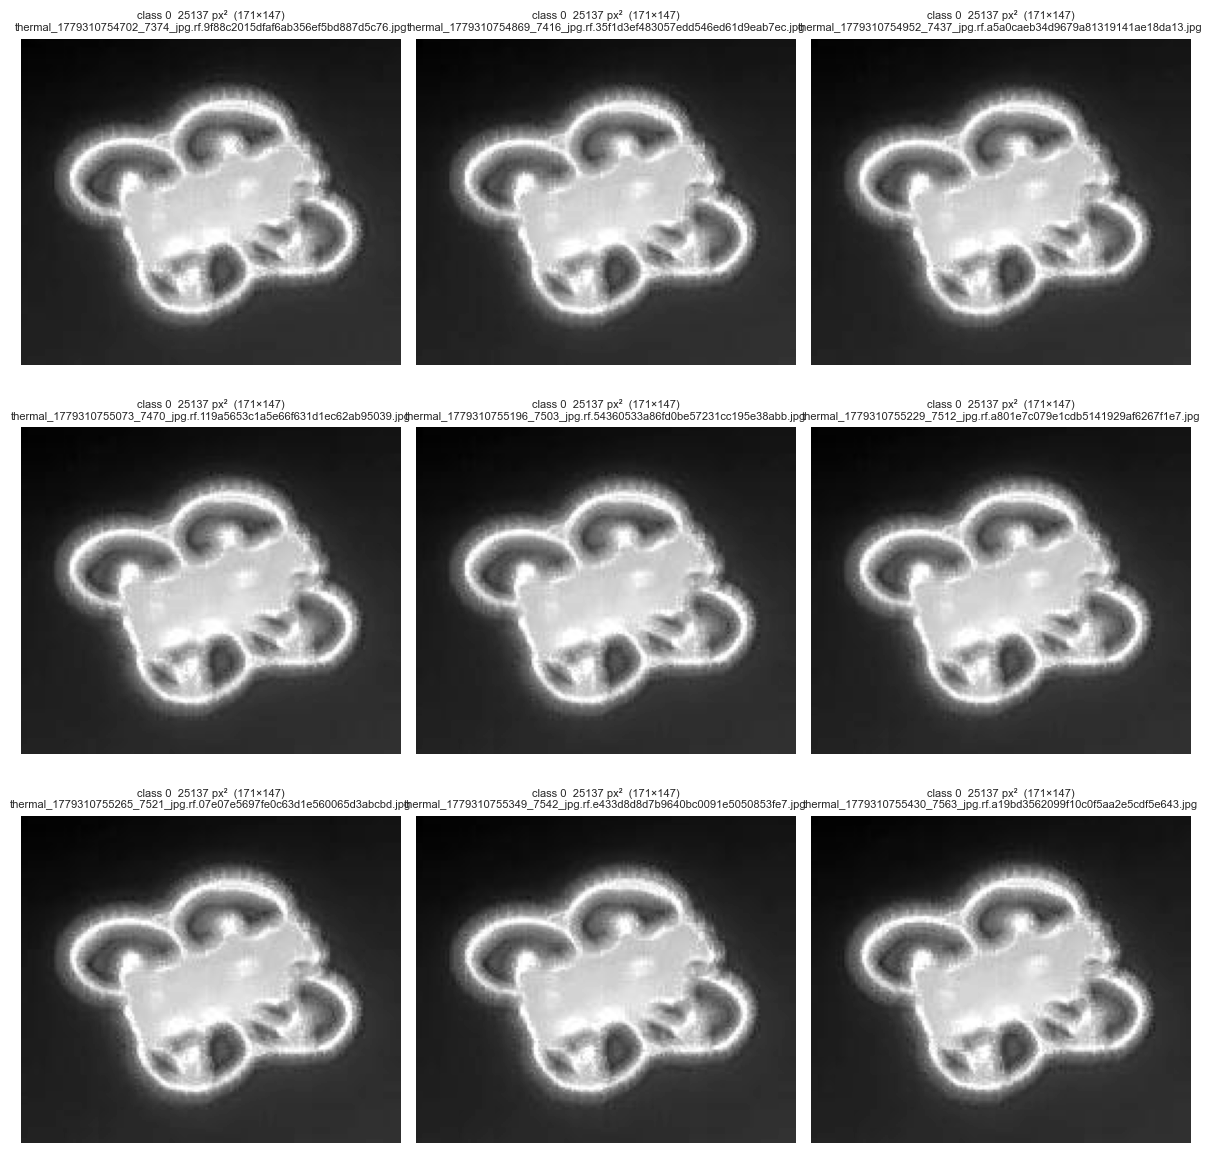


Class 0 examples:
      25137 px²   171×147   thermal_1779310754702_7374_jpg.rf.9f88c2015dfaf6ab356ef5bd887d5c76.jpg
      25137 px²   171×147   thermal_1779310754869_7416_jpg.rf.35f1d3ef483057edd546ed61d9eab7ec.jpg
      25137 px²   171×147   thermal_1779310754952_7437_jpg.rf.a5a0caeb34d9679a81319141ae18da13.jpg
      25137 px²   171×147   thermal_1779310755073_7470_jpg.rf.119a5653c1a5e66f631d1ec62ab95039.jpg
      25137 px²   171×147   thermal_1779310755196_7503_jpg.rf.54360533a86fd0be57231cc195e38abb.jpg
      25137 px²   171×147   thermal_1779310755229_7512_jpg.rf.a801e7c079e1cdb5141929af6267f1e7.jpg
      25137 px²   171×147   thermal_1779310755265_7521_jpg.rf.07e07e5697fe0c63d1e560065d3abcbd.jpg
      25137 px²   171×147   thermal_1779310755349_7542_jpg.rf.e433d8d8d7b9640bc0091e5050853fe7.jpg
      25137 px²   171×147   thermal_1779310755430_7563_jpg.rf.a19bd3562099f10c0f5aa2e5cdf5e643.jpg


In [5]:
# ── Biggest drone examples ─────────────────────────────────────────────────────
N_BIGGEST = 9

biggest = []
for rec in dataset:
    for (x1, y1, x2, y2) in rec["bboxes"]:
        biggest.append(((x2 - x1) * (y2 - y1), rec["path"], x1, y1, x2, y2))
biggest.sort(key=lambda t: t[0], reverse=True)
biggest = biggest[:N_BIGGEST]

ncols = 3
nrows = (len(biggest) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes_flat = np.atleast_1d(axes).ravel()
for ax, (area, path, x1, y1, x2, y2) in zip(axes_flat, biggest):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    ax.imshow(img[y1:y2, x1:x2], cmap="gray")
    ax.set_title(f"{area:.0f} px²  ({x2 - x1}×{y2 - y1})\n{Path(path).name}", fontsize=8)
    ax.axis("off")
for ax in axes_flat[len(biggest):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "cell3d_biggest_drones.png"), dpi=150)
plt.show()

print("Biggest drone targets (by bbox area):")
for area, path, x1, y1, x2, y2 in biggest:
    print(f"  {area:>9.0f} px²  {x2 - x1:>4}×{y2 - y1:<4}  {Path(path).name}")

# ── Label class distribution — from the corrected annotations actually used ───
_names_match = re.search(r"names:\s*\[(.*?)\]", (Path(EXTRACT_DIR) / "data.yaml").read_text())
CLASS_NAMES = [n.strip().strip("'\"") for n in _names_match.group(1).split(",")] if _names_match else []

class_counts = {}
for split in ("train", "valid", "test"):
    label_dir = CORRECTED_LABELS_ROOT / split / "labels"
    if not label_dir.exists():
        continue
    for label_file in label_dir.glob("*.txt"):
        with open(label_file) as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                class_counts[parts[0]] = class_counts.get(parts[0], 0) + 1

print("\nLabel classes present in corrected_yolo annotations:")
for class_id in sorted(class_counts, key=lambda c: int(c)):
    name = CLASS_NAMES[int(class_id)] if int(class_id) < len(CLASS_NAMES) else "?"
    print(f"  class {class_id:>2} ({name:<15}) : {class_counts[class_id]} boxes")

drone_example_count = sum(class_counts.values())
non_drone_example_count = len(bg_only_paths)
print(f"\nDrone examples (all classes, incl. class 0) : {drone_example_count}")
print(f"Non-drone examples (pure-background images) : {non_drone_example_count}")

# ── Class 0 examples ──────────────────────────────────────────────────────────
N_CLASS0_EXAMPLES = 9

class0_examples = []
for rec in dataset:
    label_path = _build_label_path(rec["path"])
    if not label_path or not os.path.exists(label_path):
        continue
    img = cv2.imread(rec["path"], cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    H, W = img.shape
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5 or parts[0] != "0":
                continue
            _, cx, cy, bw, bh = map(float, parts[:5])
            px_cx, px_cy = cx * W, cy * H
            px_w, px_h = bw * W, bh * H
            x1 = int(np.clip(px_cx - px_w / 2, 0, W)); x2 = int(np.clip(px_cx + px_w / 2, 0, W))
            y1 = int(np.clip(px_cy - px_h / 2, 0, H)); y2 = int(np.clip(px_cy + px_h / 2, 0, H))
            if (x2 - x1) < 2 or (y2 - y1) < 2:
                continue
            class0_examples.append(((x2 - x1) * (y2 - y1), rec["path"], x1, y1, x2, y2))

class0_examples.sort(key=lambda t: t[0], reverse=True)
class0_examples = class0_examples[:N_CLASS0_EXAMPLES]

if class0_examples:
    ncols0 = 3
    nrows0 = (len(class0_examples) + ncols0 - 1) // ncols0
    fig, axes = plt.subplots(nrows0, ncols0, figsize=(4 * ncols0, 4 * nrows0))
    axes_flat0 = np.atleast_1d(axes).ravel()
    for ax, (area, path, x1, y1, x2, y2) in zip(axes_flat0, class0_examples):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        ax.imshow(img[y1:y2, x1:x2], cmap="gray")
        ax.set_title(f"class 0  {area:.0f} px²  ({x2 - x1}×{y2 - y1})\n{Path(path).name}", fontsize=8)
        ax.axis("off")
    for ax in axes_flat0[len(class0_examples):]:
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "cell3d_class0_examples.png"), dpi=150)
    plt.show()

    print("\nClass 0 examples:")
    for area, path, x1, y1, x2, y2 in class0_examples:
        print(f"  {area:>9.0f} px²  {x2 - x1:>4}×{y2 - y1:<4}  {Path(path).name}")
else:
    print("\nNo class-0 boxes found in the corrected annotations used by `dataset`.")

## Cell 4 — EDA Patch Extraction
Uniform 48×48 patches (24×24 core, 12 px ring) for all EDA analyses, built from the
**DifIISR bicubic-×4 encoder input** (`new_dataset/exact_padded_float32` NPYs — valid split only).
Values are float32 around [-1, 1]; the reflect padding is cropped off using `manifest.csv`.
Three groups are compared in every analysis:
- **Drone**: only drones whose bbox width **and** height are both ≤ PATCH_CORE (24 px) — the drone fits inside the core, ring is clean background.
- **Non-drone**: random crops from pure-background images, same core/ring split.
- **NEW NON DRONE**: for every drone patch, one patch from the *same image* placed directly against it (edge-to-edge, no overlap). The side is deterministic — the first of right, left, below, above, then the four diagonals whose patch fits in the image and stays at least `NEW_NON_DRONE_MARGIN` px from every drone bbox — same scene and sensor conditions, no drone.


In [6]:
# ── Patch geometry ────────────────────────────────────────────────────────────
N_BG_CROPS_PER_IMAGE = 4  # random crops per pure-background image
NEW_NON_DRONE_MARGIN = 8  # px — min distance between a NEW NON DRONE patch and any drone bbox
PATCH_CORE  = 24                           # 24 px — fixed core side
PATCH_OUTER = 48                           # 48 px — total EDA patch (ring width 12 px)
HALF_OUTER  = PATCH_OUTER // 2             # 24

_ci = (PATCH_OUTER - PATCH_CORE) // 2     # 12 — core start index in 48×48
_co = _ci + PATCH_CORE                    # 36 — core end index (exclusive)

def patch_core(p):
    return p[_ci:_co, _ci:_co]

def patch_ring_flat(p):
    mask = np.ones((PATCH_OUTER, PATCH_OUTER), dtype=bool)
    mask[_ci:_co, _ci:_co] = False
    return p[mask].astype(np.float32)

def fits_in_core(bbox):
    """A drone qualifies when both its width and its height are at most PATCH_CORE px, so the ring stays clean background."""
    x1, y1, x2, y2 = bbox
    return (x2 - x1) <= PATCH_CORE and (y2 - y1) <= PATCH_CORE

# ── DifIISR NPY set covers the VALID split only — restrict EDA scope there ───
def _is_valid_split(path: str) -> bool:
    return "valid" in os.path.normpath(path).split(os.sep)


_eda_dataset = [rec for rec in dataset if _is_valid_split(rec["path"])]
_eda_bg_paths = [p for p in bg_only_paths if _is_valid_split(p)]
print("Valid-split restriction (DifIISR NPY only covers valid):")
print(f"  Drone images : {len(_eda_dataset)} kept of {len(dataset)} total")
print(f"  BG images    : {len(_eda_bg_paths)} kept of {len(bg_only_paths)} total")

# Small-drone images: at least one box whose width and height both fit inside the core.
_small_drone_paths = [
    rec["path"] for rec in _eda_dataset
    if any(fits_in_core(b) for b in rec["bboxes"])
]
print(f"Small-drone images (width and height <= {PATCH_CORE} px): {len(_small_drone_paths)} of {len(_eda_dataset)} valid-split drone images")


Valid-split restriction (DifIISR NPY only covers valid):
  Drone images : 1818 kept of 6104 total
  BG images    : 297 kept of 927 total
Small-drone images (width and height <= 24 px): 928 of 1818 valid-split drone images


In [7]:
# ── Extract the DifIISR NPY zips (valid split only) + build the HR→NPY index ──
_npy_zips = sorted(NEW_DATASET_DIR.glob("exact_padded_float32-*.zip"))
if not any(Path(NPY_EXTRACT_DIR).rglob("*.npy")):
    print(f"Extracting {len(_npy_zips)} NPY zip part(s) to {NPY_EXTRACT_DIR} ...")
    for _zp in _npy_zips:
        with zipfile.ZipFile(_zp) as z:
            z.extractall(NPY_EXTRACT_DIR)
else:
    print(f"Using existing extracted NPY set: {NPY_EXTRACT_DIR}")

_npy_files = {p.name: str(p) for p in Path(NPY_EXTRACT_DIR).rglob("*.npy")}

# manifest.csv 'exact_npy' holds a Colab path, so NPYs are located by file name instead.
MANIFEST = {}
with open(MANIFEST_PATH, newline="", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        MANIFEST[row["stem"]] = {
            "npy": _npy_files.get(row["stem"] + ".npy"),
            "cropped_w": int(row["cropped_width"]),
            "cropped_h": int(row["cropped_height"]),
            "lr_w": int(row["lr_width"]),
            "lr_h": int(row["lr_height"]),
            "enc_w": int(row["encoder_input_width"]),
            "enc_h": int(row["encoder_input_height"]),
        }
print(f"MANIFEST rows: {len(MANIFEST)}  |  NPY files on disk: {len(_npy_files)}")

# Padding is on the right/bottom only; the real FOV is LR size x4, so cropping needs no resize.
_bad = [s for s, m in MANIFEST.items() if m["npy"] is not None and (
    m["cropped_w"] != 4 * m["lr_w"] or m["cropped_h"] != 4 * m["lr_h"]
    or np.load(m["npy"], mmap_mode="r").shape != (3, m["enc_h"], m["enc_w"]))]
assert not _bad, f"{len(_bad)} NPY/manifest mismatches, e.g. {_bad[:3]}"


def _build_difiisr_stem_index() -> dict:
    """Map each valid-split HR image to its manifest stem — the NPY name matches the corrected label's hash, not the image's own."""
    index = {}
    for img_path in img_paths:
        if not _is_valid_split(img_path):
            continue
        label_path = _build_label_path(img_path)
        if label_path and Path(label_path).stem in MANIFEST:
            index[os.path.normpath(img_path)] = Path(label_path).stem
    return index



DIFIISR_STEM_INDEX = _build_difiisr_stem_index()

_eligible_paths = set(_small_drone_paths) | set(_eda_bg_paths)
_matched = sum(1 for p in _eligible_paths if os.path.normpath(p) in DIFIISR_STEM_INDEX)
print(f"DIFIISR_STEM_INDEX: {len(DIFIISR_STEM_INDEX)} valid-split images matched to the manifest")
print(f"Eligible images (small-drone + bg) matched: {_matched} / {len(_eligible_paths)}  (missing: {len(_eligible_paths) - _matched})")

Extracting 5 NPY zip part(s) to extracted\difiisr_npy ...


MANIFEST rows: 2115  |  NPY files on disk: 2115


DIFIISR_STEM_INDEX: 2115 valid-split images matched to the manifest
Eligible images (small-drone + bg) matched: 1225 / 1225  (missing: 0)


In [8]:
# ── Re-pair labels inside same-source-stem groups using the NPY content ───────
# Sorted-name pairing can swap augmentations of the same source image; the NPY name is tied to the label, so the NPY pixels decide.
import itertools

def _lr_by_label_stem(stem: str) -> np.ndarray:
    meta = MANIFEST[stem]
    arr = np.load(meta["npy"], mmap_mode="r")
    return np.ascontiguousarray(arr[0, :meta["cropped_h"], :meta["cropped_w"]]).astype(np.float32).ravel()


_img_groups, _lbl_groups = {}, {}
for _p in img_paths:
    if _is_valid_split(_p):
        _img_groups.setdefault(_extract_stem(os.path.basename(_p)), []).append(_p)
for _f in sorted((CORRECTED_LABELS_ROOT / "valid" / "labels").glob("*.txt")):
    _lbl_groups.setdefault(_extract_stem(_f.name), []).append(_f)

_changed_groups = _changed_images = 0
for _key, _imgs in _img_groups.items():
    _lbls = _lbl_groups.get(_key, [])
    if len(_imgs) < 2 or len(_imgs) != len(_lbls):
        continue
    _hr = {p: cv2.imread(p, cv2.IMREAD_GRAYSCALE).astype(np.float32).ravel() for p in _imgs}
    _lr = {l: _lr_by_label_stem(l.stem) for l in _lbls}
    _r = {(p, l): float(np.corrcoef(_hr[p], _lr[l])[0, 1]) for p in _imgs for l in _lbls}
    _current = [Path(_LABEL_PATH_INDEX[os.path.normpath(p)]) for p in _imgs]
    _best = max(itertools.permutations(_lbls), key=lambda perm: sum(_r[(p, l)] for p, l in zip(_imgs, perm)))
    _gain = sum(_r[(p, l)] for p, l in zip(_imgs, _best)) - sum(_r[(p, l)] for p, l in zip(_imgs, [next(x for x in _lbls if x.name == c.name) for c in _current]))
    if _gain > 0.05:
        _changed_groups += 1
        for p, l in zip(_imgs, _best):
            if Path(_LABEL_PATH_INDEX[os.path.normpath(p)]).name != l.name:
                _changed_images += 1
            _LABEL_PATH_INDEX[os.path.normpath(p)] = str(l)

print(f"Re-paired groups : {_changed_groups}  |  images whose label changed : {_changed_images}")

# Everything derived from the label pairing is rebuilt.
dataset, bg_only_paths, skipped = [], [], 0
for _p in img_paths:
    _lp = _build_label_path(_p)
    if os.path.exists(_lp) and os.path.getsize(_lp) == 0:
        bg_only_paths.append(_p)
        continue
    _rec = process_image(_p)
    if _rec:
        dataset.append(_rec)
    else:
        skipped += 1

_eda_dataset = [rec for rec in dataset if _is_valid_split(rec["path"])]
_eda_bg_paths = [p for p in bg_only_paths if _is_valid_split(p)]
_small_drone_paths = [
    rec["path"] for rec in _eda_dataset
    if any(fits_in_core(b) for b in rec["bboxes"])
]
DIFIISR_STEM_INDEX = _build_difiisr_stem_index()
_eligible_paths = set(_small_drone_paths) | set(_eda_bg_paths)

print(f"dataset: {len(dataset)} drone images, {len(bg_only_paths)} background images, {skipped} skipped")
print(f"valid split: {len(_eda_dataset)} drone images, {len(_eda_bg_paths)} background images, "
      f"{len(_small_drone_paths)} with a box that fits the {PATCH_CORE}x{PATCH_CORE} core")
print(f"DIFIISR_STEM_INDEX: {len(DIFIISR_STEM_INDEX)}  |  unique NPY stems: {len(set(DIFIISR_STEM_INDEX.values()))}")


Re-paired groups : 19  |  images whose label changed : 40


dataset: 6104 drone images, 927 background images, 1 skipped
valid split: 1818 drone images, 297 background images, 928 with a box that fits the 24x24 core
DIFIISR_STEM_INDEX: 2115  |  unique NPY stems: 2115


In [9]:
# ── Load DifIISR input (padding removed) + validate against the HR image size ─
def load_difiisr_input(hr_path: str):
    """Return the float32 DifIISR encoder input (HxW, ~[-1,1]) cropped to the real FOV, or None if unmatched."""
    stem = DIFIISR_STEM_INDEX.get(os.path.normpath(hr_path))
    meta = MANIFEST.get(stem) if stem else None
    if meta is None or meta["npy"] is None:
        return None
    arr = np.load(meta["npy"], mmap_mode="r")  # (3, H_pad, W_pad)
    if not (np.array_equal(arr[0], arr[1]) and np.array_equal(arr[0], arr[2])):
        raise ValueError(f"RGB channels differ in {meta['npy']}")
    return np.ascontiguousarray(arr[0, :meta["cropped_h"], :meta["cropped_w"]])


LR_VALID_PATHS = set()
_missing = _shape_bad = 0
for _hr_path in sorted(_eligible_paths):
    _lr = load_difiisr_input(_hr_path)
    if _lr is None:
        _missing += 1
        continue
    _hr = cv2.imread(_hr_path, cv2.IMREAD_GRAYSCALE)
    if _hr is None or _hr.shape != _lr.shape:
        _shape_bad += 1
        continue
    LR_VALID_PATHS.add(_hr_path)

print(f"LR_VALID_PATHS: {len(LR_VALID_PATHS)} / {len(_eligible_paths)} eligible images")
print(f"  no NPY / manifest entry : {_missing}")
print(f"  shape != HR image       : {_shape_bad}")


LR_VALID_PATHS: 1225 / 1225 eligible images
  no NPY / manifest entry : 0
  shape != HR image       : 0


DifIISR input sizes after padding removal (1 distinct shape(s) across 1225 images):
  640x512  (W=640, H=512)  : 1225 images

Random example: auto_000620_jpg.rf.0397cc70010e1bc6fcc17a7084061d96.jpg  HR shape=(512, 640)  DifIISR input shape=(512, 640)
YOLO drone bbox: (324, 212, 331, 220)  size=7x8
HR  (as [-1,1]) min=-1.000 max=1.000 mean=-0.450
LR input        min=-1.013 max=1.020 mean=-0.447


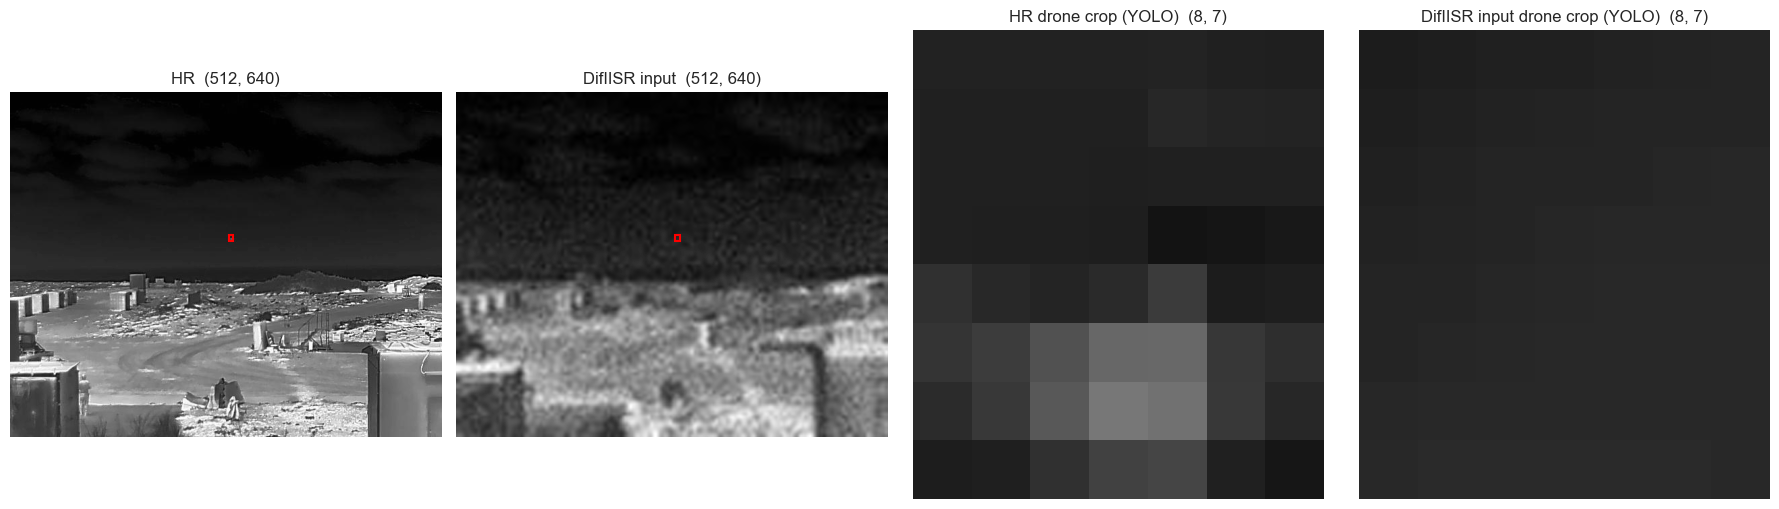

In [10]:
# ── DifIISR input size report + random example (before any patch cropping) ───
_lr_shapes = {}
for _p in LR_VALID_PATHS:
    _m = MANIFEST[DIFIISR_STEM_INDEX[os.path.normpath(_p)]]
    _key = (_m["cropped_h"], _m["cropped_w"])
    _lr_shapes[_key] = _lr_shapes.get(_key, 0) + 1

print(f"DifIISR input sizes after padding removal ({len(_lr_shapes)} distinct shape(s) across {sum(_lr_shapes.values())} images):")
for (_h, _w), _count in sorted(_lr_shapes.items(), key=lambda kv: -kv[1]):
    print(f"  {_w}x{_h}  (W={_w}, H={_h})  : {_count} images")

_drone_eligible = sorted(p for p in _small_drone_paths if p in LR_VALID_PATHS)
_example_path = np.random.choice(_drone_eligible)
_example_hr = cv2.imread(_example_path, cv2.IMREAD_GRAYSCALE)
_example_lr = load_difiisr_input(_example_path)
print(f"\nRandom example: {os.path.basename(_example_path)}  HR shape={_example_hr.shape}  DifIISR input shape={_example_lr.shape}")

_example_rec = next(rec for rec in _eda_dataset if rec["path"] == _example_path)
_ex_x1, _ex_y1, _ex_x2, _ex_y2 = next(b for b in _example_rec["bboxes"] if fits_in_core(b))
print(f"YOLO drone bbox: ({_ex_x1}, {_ex_y1}, {_ex_x2}, {_ex_y2})  size={_ex_x2 - _ex_x1}x{_ex_y2 - _ex_y1}")

# HR is mapped to the NPY's [-1, 1] units so both share one display scale.
_example_hr_f = _example_hr.astype(np.float32) / 127.5 - 1.0
_example_hr_patch = _example_hr_f[_ex_y1:_ex_y2, _ex_x1:_ex_x2]
_example_lr_patch = _example_lr[_ex_y1:_ex_y2, _ex_x1:_ex_x2]
print(f"HR  (as [-1,1]) min={_example_hr_f.min():.3f} max={_example_hr_f.max():.3f} mean={_example_hr_f.mean():.3f}")
print(f"LR input        min={_example_lr.min():.3f} max={_example_lr.max():.3f} mean={_example_lr.mean():.3f}")

_vmin = float(min(_example_hr_f.min(), _example_lr.min()))
_vmax = float(max(_example_hr_f.max(), _example_lr.max()))

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for _ax, _img, _title in (
    (axes[0], _example_hr_f, f"HR  {_example_hr.shape}"),
    (axes[1], _example_lr, f"DifIISR input  {_example_lr.shape}"),
):
    _ax.imshow(_img, cmap="gray", vmin=_vmin, vmax=_vmax)
    _ax.add_patch(plt.Rectangle((_ex_x1, _ex_y1), _ex_x2 - _ex_x1, _ex_y2 - _ex_y1, edgecolor="red", facecolor="none", linewidth=1.5))
    _ax.set_title(_title)
    _ax.axis("off")
axes[2].imshow(_example_hr_patch, cmap="gray", vmin=_vmin, vmax=_vmax)
axes[2].set_title(f"HR drone crop (YOLO)  {_example_hr_patch.shape}")
axes[2].axis("off")
axes[3].imshow(_example_lr_patch, cmap="gray", vmin=_vmin, vmax=_vmax)
axes[3].set_title(f"DifIISR input drone crop (YOLO)  {_example_lr_patch.shape}")
axes[3].axis("off")
plt.tight_layout()
plt.show()


Drone boxes in the new dataset: 1819  (from 1818 images)

Area percentiles (HR px²):
  P 5  →         30 px²   (side ≈    5.5 px)
  P10  →         40 px²   (side ≈    6.3 px)
  P25  →        104 px²   (side ≈   10.2 px)
  P50  →        396 px²   (side ≈   19.9 px)
  P75  →       1500 px²   (side ≈   38.7 px)
  P90  →       5248 px²   (side ≈   72.4 px)
  P95  →      14280 px²   (side ≈  119.5 px)
  P99  →      35565 px²   (side ≈  188.6 px)

mean area = 2428 px²   median area = 396 px²   min = 12   max = 75465
width  : median 23  min 3  max 388
height : median 16  min 3  max 224

Boxes with width and height <= 24 px (kept for the 24x24 core): 928 / 1819 (51.0%)


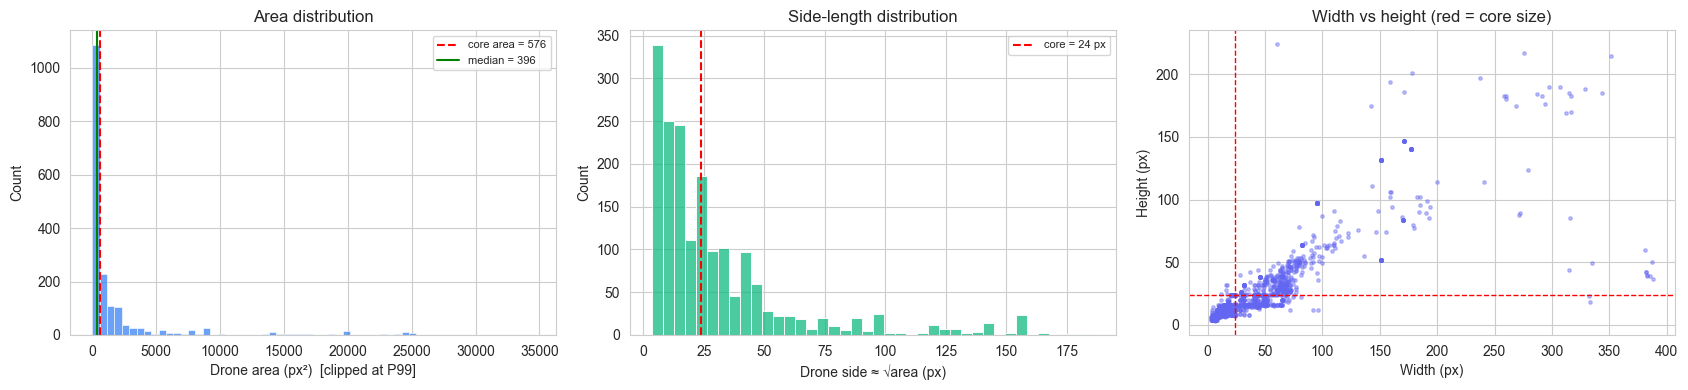

In [11]:
# ── Drone sizes in the new (DifIISR NPY, valid-split) dataset only ────────────
_nd_w, _nd_h = [], []
for rec in _eda_dataset:
    if os.path.normpath(rec["path"]) not in DIFIISR_STEM_INDEX:
        continue
    for (x1, y1, x2, y2) in rec["bboxes"]:
        _nd_w.append(x2 - x1)
        _nd_h.append(y2 - y1)

_nd_w, _nd_h = np.array(_nd_w), np.array(_nd_h)
_nd_area = _nd_w * _nd_h
_nd_side = np.sqrt(_nd_area)

print(f"Drone boxes in the new dataset: {_nd_area.size}  "
      f"(from {sum(os.path.normpath(r['path']) in DIFIISR_STEM_INDEX for r in _eda_dataset)} images)")
print("\nArea percentiles (HR px²):")
for p, v in zip([5, 10, 25, 50, 75, 90, 95, 99], np.percentile(_nd_area, [5, 10, 25, 50, 75, 90, 95, 99])):
    print(f"  P{p:>2}  →  {v:>9.0f} px²   (side ≈ {np.sqrt(v):>6.1f} px)")
print(f"\nmean area = {_nd_area.mean():.0f} px²   median area = {np.median(_nd_area):.0f} px²   "
      f"min = {_nd_area.min()}   max = {_nd_area.max()}")
print(f"width  : median {np.median(_nd_w):.0f}  min {_nd_w.min()}  max {_nd_w.max()}")
print(f"height : median {np.median(_nd_h):.0f}  min {_nd_h.min()}  max {_nd_h.max()}")
_n_fit = int(np.sum((_nd_w <= PATCH_CORE) & (_nd_h <= PATCH_CORE)))
print(f"\nBoxes with width and height <= {PATCH_CORE} px (kept for the {PATCH_CORE}x{PATCH_CORE} core): {_n_fit} / {_nd_area.size} ({_n_fit / _nd_area.size:.1%})")

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
_clip = np.percentile(_nd_area, 99)
sns.histplot(_nd_area[_nd_area <= _clip], bins=60, ax=axes[0], color="#3b82f6", edgecolor="white")
axes[0].axvline(PATCH_CORE ** 2, color="red", ls="--", lw=1.5, label=f"core area = {PATCH_CORE ** 2}")
axes[0].axvline(np.median(_nd_area), color="green", ls="-", lw=1.5, label=f"median = {np.median(_nd_area):.0f}")
axes[0].set_xlabel("Drone area (px²)  [clipped at P99]")
axes[0].set_ylabel("Count")
axes[0].set_title("Area distribution")
axes[0].legend(fontsize=8)

sns.histplot(_nd_side[_nd_side <= np.sqrt(_clip)], bins=40, ax=axes[1], color="#10b981", edgecolor="white")
axes[1].axvline(PATCH_CORE, color="red", ls="--", lw=1.5, label=f"core = {PATCH_CORE} px")
axes[1].set_xlabel("Drone side ≈ √area (px)")
axes[1].set_title("Side-length distribution")
axes[1].legend(fontsize=8)

axes[2].scatter(_nd_w, _nd_h, s=6, alpha=0.4, color="#6366f1")
axes[2].axvline(PATCH_CORE, color="red", ls="--", lw=1)
axes[2].axhline(PATCH_CORE, color="red", ls="--", lw=1)
axes[2].set_xlabel("Width (px)")
axes[2].set_ylabel("Height (px)")
axes[2].set_title("Width vs height (red = core size)")
plt.tight_layout()
plt.show()


In [12]:
# ── 4a: Drone EDA patches — DifIISR input, valid split, small drones only ───
eda_drone_patches = []
eda_drone_meta = []
skipped_large = skipped_edge = 0

for rec in _eda_dataset:
    if rec["path"] not in LR_VALID_PATHS:
        continue
    lr_img = load_difiisr_input(rec["path"])
    H, W = lr_img.shape  # identical to the HR image shape (validated above)
    for bbox in rec["bboxes"]:
        if not fits_in_core(bbox):
            skipped_large += 1
            continue
        x1, y1, x2, y2 = bbox
        cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
        r0, r1 = cy - HALF_OUTER, cy + HALF_OUTER
        c0, c1 = cx - HALF_OUTER, cx + HALF_OUTER
        if r0 < 0 or r1 > H or c0 < 0 or c1 > W:
            skipped_edge += 1
            continue
        eda_drone_patches.append(lr_img[r0:r1, c0:c1].copy())
        eda_drone_meta.append({"path": rec["path"], "r0": r0, "r1": r1, "c0": c0, "c1": c1})

print(f"Drone EDA patches : {len(eda_drone_patches)}")
print(f"  skipped (wider or taller than {PATCH_CORE} px) : {skipped_large}")
print(f"  skipped (near edge) : {skipped_edge}")

eda_non_drone_patches = []
eda_non_drone_meta = []
rng = np.random.default_rng(42)

for bg_path in _eda_bg_paths:
    if bg_path not in LR_VALID_PATHS:
        continue
    lr_img = load_difiisr_input(bg_path)
    H, W = lr_img.shape
    if H < PATCH_OUTER or W < PATCH_OUTER:
        continue
    for _ in range(N_BG_CROPS_PER_IMAGE):
        r0 = int(rng.integers(0, H - PATCH_OUTER))
        c0 = int(rng.integers(0, W - PATCH_OUTER))
        eda_non_drone_patches.append(lr_img[r0:r0 + PATCH_OUTER, c0:c0 + PATCH_OUTER].copy())
        eda_non_drone_meta.append({"path": bg_path, "r0": r0, "r1": r0 + PATCH_OUTER, "c0": c0, "c1": c0 + PATCH_OUTER})

print(f"Non-drone EDA patches : {len(eda_non_drone_patches)}")

# ── NEW NON DRONE: one patch placed edge-to-edge against each drone patch (same image) ──
# Deterministic: first side in this order whose patch fits in the image and stays clear of every drone bbox.
_NEW_NON_DRONE_SIDES = (
    ("right", 0, 1), ("left", 0, -1), ("below", 1, 0), ("above", -1, 0),
    ("below-right", 1, 1), ("below-left", 1, -1), ("above-right", -1, 1), ("above-left", -1, -1),
)
eda_new_non_drone_patches = []
eda_new_non_drone_meta = []
_boxes_by_path = {rec["path"]: rec["bboxes"] for rec in _eda_dataset}
_new_no_room = 0
_new_side_counts = {name: 0 for name, _, _ in _NEW_NON_DRONE_SIDES}


def _window_touches_box(r0, c0, boxes, margin=NEW_NON_DRONE_MARGIN):
    """True if the PATCH_OUTER window overlaps any bbox grown by `margin` px."""
    for (x1, y1, x2, y2) in boxes:
        if c0 < x2 + margin and c0 + PATCH_OUTER > x1 - margin and r0 < y2 + margin and r0 + PATCH_OUTER > y1 - margin:
            return True
    return False


def _windows_overlap(r0, c0, r0_other, c0_other):
    return abs(r0 - r0_other) < PATCH_OUTER and abs(c0 - c0_other) < PATCH_OUTER


_cached_path, _cached_img = None, None
for k, m in enumerate(eda_drone_meta):
    if m["path"] != _cached_path:
        _cached_path, _cached_img = m["path"], load_difiisr_input(m["path"])
    H, W = _cached_img.shape
    boxes = _boxes_by_path[m["path"]]
    for side, dr, dc in _NEW_NON_DRONE_SIDES:
        r0, c0 = m["r0"] + dr * PATCH_OUTER, m["c0"] + dc * PATCH_OUTER
        if r0 < 0 or c0 < 0 or r0 + PATCH_OUTER > H or c0 + PATCH_OUTER > W:
            continue
        if _window_touches_box(r0, c0, boxes):
            continue
        eda_new_non_drone_patches.append(_cached_img[r0:r0 + PATCH_OUTER, c0:c0 + PATCH_OUTER].copy())
        eda_new_non_drone_meta.append({"path": m["path"], "r0": r0, "r1": r0 + PATCH_OUTER, "c0": c0, "c1": c0 + PATCH_OUTER, "drone_index": k, "side": side})
        _new_side_counts[side] += 1
        break
    else:
        _new_no_room += 1

# Every NEW NON DRONE patch must touch its drone patch without overlapping it, and stay clear of every bbox.
for _m in eda_new_non_drone_meta:
    _d = eda_drone_meta[_m["drone_index"]]
    assert not _windows_overlap(_m["r0"], _m["c0"], _d["r0"], _d["c0"]), f"overlaps drone patch in {_m['path']}"
    assert max(abs(_m["r0"] - _d["r0"]), abs(_m["c0"] - _d["c0"])) == PATCH_OUTER, f"not adjacent in {_m['path']}"
    assert not _window_touches_box(_m["r0"], _m["c0"], _boxes_by_path[_m["path"]]), f"touches a bbox in {_m['path']}"

print(f"NEW NON DRONE EDA patches : {len(eda_new_non_drone_patches)}  (drone patches: {len(eda_drone_meta)}; no valid adjacent patch for {_new_no_room})")
print("  side used : " + "  ".join(f"{name}={n}" for name, n in _new_side_counts.items() if n))
print(f"  margin from any bbox : {NEW_NON_DRONE_MARGIN} px  |  adjacency and overlap checks passed")
print(f"\nGeometry : outer={PATCH_OUTER}×{PATCH_OUTER}  core={PATCH_CORE}×{PATCH_CORE}  ring_width={(PATCH_OUTER-PATCH_CORE)//2} px")
print(f"Filter   : bbox width ≤ {PATCH_CORE} and height ≤ {PATCH_CORE}  (drone fits inside core)")


Drone EDA patches : 922
  skipped (wider or taller than 24 px) : 0
  skipped (near edge) : 6


Non-drone EDA patches : 1188


NEW NON DRONE EDA patches : 922  (drone patches: 922; no valid adjacent patch for 0)
  side used : right=911  left=11
  margin from any bbox : 8 px  |  adjacency and overlap checks passed

Geometry : outer=48×48  core=24×24  ring_width=12 px
Filter   : bbox width ≤ 24 and height ≤ 24  (drone fits inside core)


Drone patches split: 922 valid, 0 malformed
Non-drone patches split : 1188 valid, 0 malformed
NEW NON DRONE patches split : 922 valid, 0 malformed
Combined records    : 3032 total
Core shape check    : (24, 24)
Ring size check     : 1728


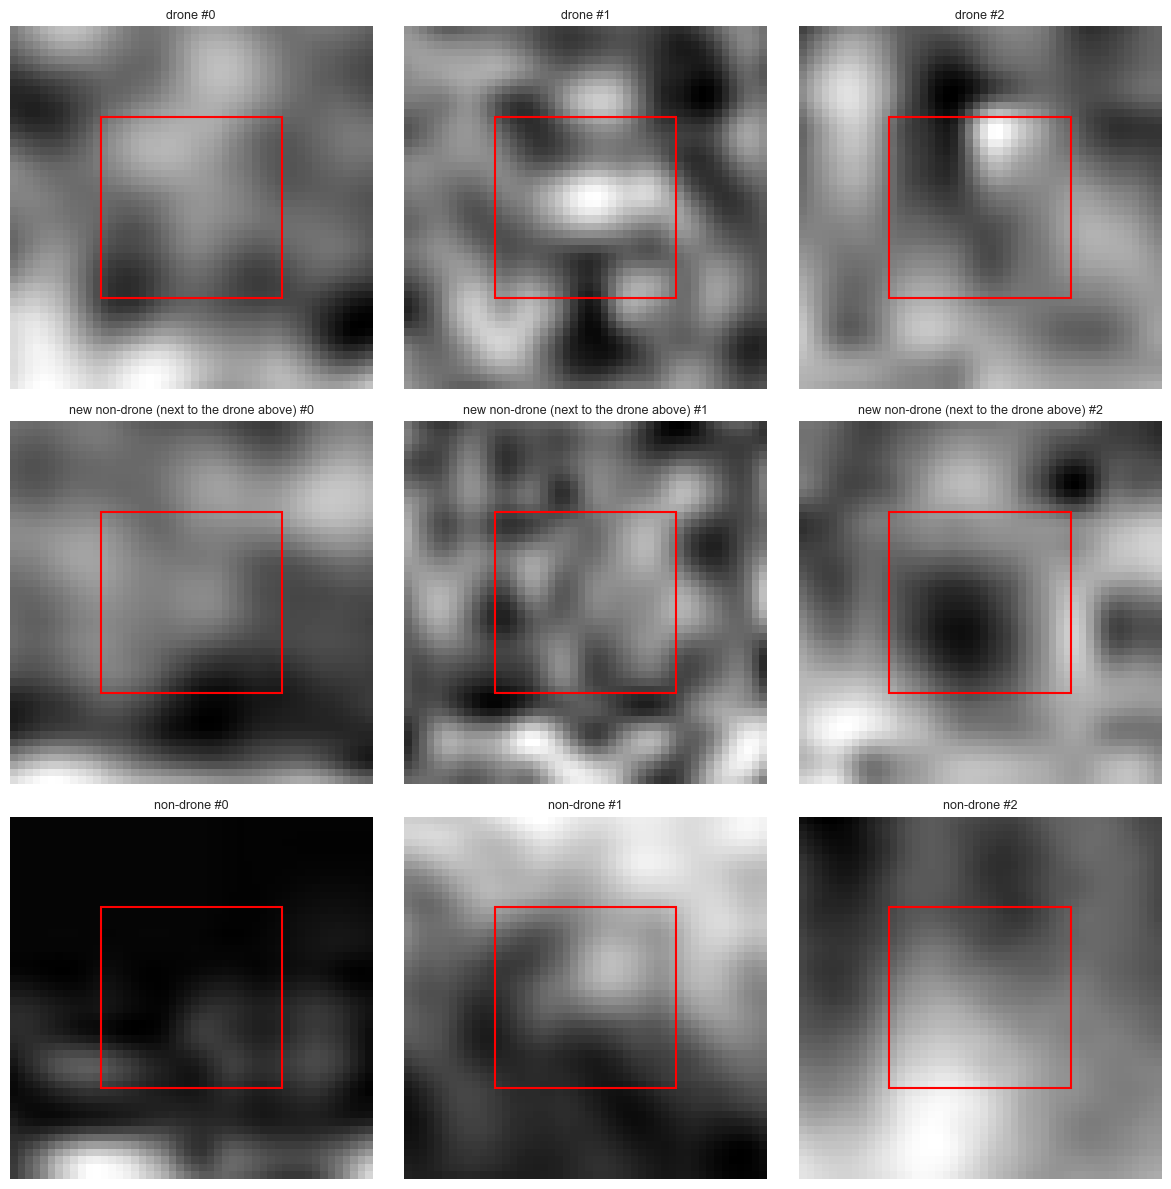

In [13]:
# ── 5: Explicit core/ring split with source labels ─────────────────────────────
# This cell must run before any metrics so each patch keeps its provenance.

PATCH_CORE_SIDE = PATCH_CORE
PATCH_RING_SIZE = PATCH_OUTER * PATCH_OUTER - PATCH_CORE_SIDE * PATCH_CORE_SIDE

assert PATCH_OUTER == 48, "Expected a 48x48 patch geometry"
assert PATCH_CORE == PATCH_CORE_SIDE == 24, "Expected a 24x24 core geometry"
assert PATCH_RING_SIZE == 1728, "Expected a 1728-pixel background ring"


def split_patch_into_core_and_ring(patch: np.ndarray):
    """Return the centered core and flattened outer ring for one PATCH_OUTER x PATCH_OUTER patch."""
    if patch.shape != (PATCH_OUTER, PATCH_OUTER):
        return None, None
    core = patch[_ci:_co, _ci:_co].copy()
    ring = patch_ring_flat(patch).copy()
    return core, ring


def build_source_split_records(patches, source_name: str, meta=None):
    """Attach source labels + source path/crop coords to each patch and keep split views for downstream metrics."""
    records = []
    malformed = 0
    meta = meta or [None] * len(patches)
    for patch, patch_meta in zip(patches, meta):
        core, ring = split_patch_into_core_and_ring(patch)
        if core is None or ring is None:
            malformed += 1
            continue
        if core.shape != (PATCH_CORE, PATCH_CORE):
            malformed += 1
            continue
        if ring.size != PATCH_RING_SIZE:
            malformed += 1
            continue
        record = {
            "source": source_name,
            "patch": patch,
            "core": core,
            "ring": ring,
        }
        if patch_meta is not None:
            record.update(patch_meta)
        records.append(record)
    return records, malformed


drone_patch_records, drone_malformed = build_source_split_records(eda_drone_patches, "drone", eda_drone_meta)
non_drone_patch_records, non_drone_malformed = build_source_split_records(eda_non_drone_patches, "non_drone", eda_non_drone_meta)
new_non_drone_patch_records, new_non_drone_malformed = build_source_split_records(eda_new_non_drone_patches, "new_non_drone", eda_new_non_drone_meta)

# Backward-compatible derived collections with explicit provenance.
drone_core_patches = [rec["core"] for rec in drone_patch_records]
drone_ring_patches = [rec["ring"] for rec in drone_patch_records]
non_drone_core_patches = [rec["core"] for rec in non_drone_patch_records]
non_drone_ring_patches = [rec["ring"] for rec in non_drone_patch_records]
new_non_drone_core_patches = [rec["core"] for rec in new_non_drone_patch_records]
new_non_drone_ring_patches = [rec["ring"] for rec in new_non_drone_patch_records]

all_patch_records = drone_patch_records + non_drone_patch_records + new_non_drone_patch_records
all_core_patches = drone_core_patches + non_drone_core_patches + new_non_drone_core_patches
all_ring_patches = drone_ring_patches + non_drone_ring_patches + new_non_drone_ring_patches
all_patch_sources = [rec["source"] for rec in all_patch_records]

print(f"Drone patches split: {len(drone_patch_records)} valid, {drone_malformed} malformed")
print(f"Non-drone patches split : {len(non_drone_patch_records)} valid, {non_drone_malformed} malformed")
print(f"NEW NON DRONE patches split : {len(new_non_drone_patch_records)} valid, {new_non_drone_malformed} malformed")
print(f"Combined records    : {len(all_patch_records)} total")
print(f"Core shape check    : {all_core_patches[0].shape if all_core_patches else 'n/a'}")
print(f"Ring size check     : {all_ring_patches[0].size if all_ring_patches else 'n/a'}")

# ── Example patches: 3 drone, then each drone's neighbouring NEW NON DRONE patch, then 3 non-drone ──
_n_examples = 3
_pick = np.random.choice(len(new_non_drone_patch_records), size=min(_n_examples, len(new_non_drone_patch_records)), replace=False)
_drone_examples = [drone_patch_records[new_non_drone_patch_records[int(i)]["drone_index"]] for i in _pick]
_new_examples = [new_non_drone_patch_records[int(i)] for i in _pick]
_non_drone_pick = np.random.choice(len(non_drone_patch_records), size=min(_n_examples, len(non_drone_patch_records)), replace=False)
_non_drone_examples = [non_drone_patch_records[int(i)] for i in _non_drone_pick]

fig, axes = plt.subplots(3, _n_examples, figsize=(4 * _n_examples, 12))
for row, (_name, _records) in enumerate((
    ("drone", _drone_examples),
    ("new non-drone (next to the drone above)", _new_examples),
    ("non-drone", _non_drone_examples),
)):
    for col in range(_n_examples):
        if col < len(_records):
            axes[row, col].imshow(_records[col]["patch"], cmap="gray")
            axes[row, col].add_patch(plt.Rectangle((_ci - 0.5, _ci - 0.5), PATCH_CORE, PATCH_CORE,
                                                   edgecolor="red", facecolor="none", linewidth=1.5))
        axes[row, col].set_title(f"{_name} #{col}", fontsize=9)
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()


In [14]:
# ── 6: Persist analysis-ready drone/non_drone/new_non_drone splits ───────────────────
# Save source-aware patch records so later metric cells can reload them directly.

from dataclasses import asdict, dataclass
from datetime import datetime


EDA_EXPORT_DIR = os.path.join(RESULTS_DIR, "eda_exports")
os.makedirs(EDA_EXPORT_DIR, exist_ok=True)


@dataclass
class PatchRecord:
    source: str
    index: int
    patch_shape: tuple
    core_shape: tuple
    ring_size: int
    core: np.ndarray
    ring: np.ndarray


analysis_records = []
for source_name, patch_records in (
    ("drone", drone_patch_records),
    ("non_drone", non_drone_patch_records),
    ("new_non_drone", new_non_drone_patch_records),
):
    for index, rec in enumerate(patch_records):
        analysis_records.append(PatchRecord(
            source=source_name,
            index=index,
            patch_shape=tuple(rec["patch"].shape),
            core_shape=tuple(rec["core"].shape),
            ring_size=int(rec["ring"].size),
            core=rec["core"].astype(np.float32, copy=False),
            ring=rec["ring"].astype(np.float32, copy=False),
        ))

save_payload = {
    "created_at": datetime.utcnow().isoformat(timespec="seconds") + "Z",
    "patch_outer": int(PATCH_OUTER),
    "patch_core": int(PATCH_CORE),
    "ring_size": int(PATCH_RING_SIZE),
    "drone_count": int(len(drone_patch_records)),
    "non_drone_count": int(len(non_drone_patch_records)),
    "new_non_drone_count": int(len(new_non_drone_patch_records)),
    "new_non_drone_margin_px": int(NEW_NON_DRONE_MARGIN),
    "records": [
        {
            "source": rec.source,
            "index": int(rec.index),
            "patch_shape": list(rec.patch_shape),
            "core_shape": list(rec.core_shape),
            "ring_size": int(rec.ring_size),
        }
        for rec in analysis_records
    ],
}

# Store analysis data in a compact NumPy archive for easy reuse.
np.savez_compressed(
    os.path.join(EDA_EXPORT_DIR, "patch_records.npz"),
    drone_core=np.array(drone_core_patches, dtype=np.float32),
    drone_ring=np.array(drone_ring_patches, dtype=np.float32),
    non_drone_core=np.array(non_drone_core_patches, dtype=np.float32),
    non_drone_ring=np.array(non_drone_ring_patches, dtype=np.float32),
    new_non_drone_core=np.array(new_non_drone_core_patches, dtype=np.float32),
    new_non_drone_ring=np.array(new_non_drone_ring_patches, dtype=np.float32),
    drone_source=np.array(["drone"] * len(drone_core_patches)),
    non_drone_source=np.array(["non_drone"] * len(non_drone_core_patches)),
    new_non_drone_source=np.array(["new_non_drone"] * len(new_non_drone_core_patches)),
)

with open(os.path.join(EDA_EXPORT_DIR, "patch_records_manifest.json"), "w", encoding="utf-8") as f:
    json.dump(save_payload, f, indent=2)

print(f"Saved analysis-ready patches to: {EDA_EXPORT_DIR}")
print(f"Manifest records           : {len(save_payload['records'])}")
print(f"Drone / Non-drone / New non-drone counts : {save_payload['drone_count']} / {save_payload['non_drone_count']} / {save_payload['new_non_drone_count']}")
print(f"Core shape / ring size     : {drone_core_patches[0].shape if drone_core_patches else 'n/a'} / {drone_ring_patches[0].size if drone_ring_patches else 'n/a'}")


Saved analysis-ready patches to: RESULTS\eda_exports
Manifest records           : 3032
Drone / Non-drone / New non-drone counts : 922 / 1188 / 922
Core shape / ring size     : (24, 24) / 1728


In [15]:
# ── 7: Ring background statistics ──────────────────────────────────────────────
# Estimate per-patch ring background stats used to stabilize the pooled-core SCR denominator.

EPS = 1e-8


def collect_ring_terms(ring_patches):
    bg_mean_values = []
    bg_std_values = []

    for ring in ring_patches:
        ring_f = ring.astype(np.float32)
        bg_mean_values.append(float(np.mean(ring_f)))
        bg_std_values.append(float(np.std(ring_f)))

    return {
        "bg_mean": np.asarray(bg_mean_values, dtype=np.float32),
        "bg_std": np.asarray(bg_std_values, dtype=np.float32),
    }


drone_ring_terms = collect_ring_terms(drone_ring_patches)
non_drone_ring_terms = collect_ring_terms(non_drone_ring_patches)
new_non_drone_ring_terms = collect_ring_terms(new_non_drone_ring_patches)

# Estimate the sensor noise floor from the lower tail of the non-drone ring std values (pure-background images only).
non_drone_bg_std_positive = non_drone_ring_terms["bg_std"][non_drone_ring_terms["bg_std"] > 0]
if non_drone_bg_std_positive.size > 0:
    SENSOR_NOISE_FLOOR = float(np.percentile(non_drone_bg_std_positive, 5))
else:
    SENSOR_NOISE_FLOOR = float(EPS)

# Stabilize denominators with the learned noise floor: sigma_floor.
drone_bg_std_stable = np.maximum(drone_ring_terms["bg_std"], SENSOR_NOISE_FLOOR)
non_drone_bg_std_stable = np.maximum(non_drone_ring_terms["bg_std"], SENSOR_NOISE_FLOOR)
new_non_drone_bg_std_stable = np.maximum(new_non_drone_ring_terms["bg_std"], SENSOR_NOISE_FLOOR)

print(f"Sensor noise floor (P5 of positive non-drone ring std): {SENSOR_NOISE_FLOOR:.6f}")
for _name, _terms in (("Drone", drone_ring_terms), ("Non-drone", non_drone_ring_terms), ("New non-drone", new_non_drone_ring_terms)):
    _n_floor = int(np.sum(_terms["bg_std"] < SENSOR_NOISE_FLOOR))
    print(f"{_name:<14} rings: {_terms['bg_std'].size}  using floor (std < floor): {_n_floor} ({_n_floor / _terms['bg_std'].size:.1%})")


Sensor noise floor (P5 of positive non-drone ring std): 0.013458
Drone          rings: 922  using floor (std < floor): 37 (4.0%)
Non-drone      rings: 1188  using floor (std < floor): 68 (5.7%)
New non-drone  rings: 922  using floor (std < floor): 40 (4.3%)


In [16]:
# ── 7b: Pooled Core SCR (top-2.5% core average) ──────────────────────────────────
# Replace the single brightest core pixel with the mean of the top-2.5% core pixels.
# SCR(i,j) = (Core_pool(i,j) - mu_ring(i,j)) / max(sigma_ring(i,j), sigma_floor)

TOP1_FRAC = 0.025


def collect_core_pool_terms(core_patches, ring_patches, top_frac=TOP1_FRAC):
    pooled_core_values = []
    bg_mean_values = []
    bg_std_values = []
    top_k_values = []

    for core, ring in zip(core_patches, ring_patches):
        core_f = core.astype(np.float32).ravel()
        ring_f = ring.astype(np.float32)

        k = max(1, int(np.ceil(core_f.size * top_frac)))
        top_k = np.partition(core_f, -k)[-k:]
        pooled_core_values.append(float(np.mean(top_k)))
        top_k_values.append(int(k))
        bg_mean_values.append(float(np.mean(ring_f)))
        bg_std_values.append(float(np.std(ring_f)))

    return {
        "core_pool": np.asarray(pooled_core_values, dtype=np.float32),
        "bg_mean": np.asarray(bg_mean_values, dtype=np.float32),
        "bg_std": np.asarray(bg_std_values, dtype=np.float32),
        "top_k": np.asarray(top_k_values, dtype=np.int32),
    }


def _scr_summary(values):
    return {
        "count": int(values.size),
        "mean": float(np.mean(values)),
        "std": float(np.std(values)),
        "median": float(np.median(values)),
        "min": float(np.min(values)),
        "max": float(np.max(values)),
    }


drone_pool_terms = collect_core_pool_terms(drone_core_patches, drone_ring_patches)
non_drone_pool_terms = collect_core_pool_terms(non_drone_core_patches, non_drone_ring_patches)
new_non_drone_pool_terms = collect_core_pool_terms(new_non_drone_core_patches, new_non_drone_ring_patches)

drone_core_pool_scr = (drone_pool_terms["core_pool"] - drone_pool_terms["bg_mean"]) / drone_bg_std_stable
non_drone_core_pool_scr = (non_drone_pool_terms["core_pool"] - non_drone_pool_terms["bg_mean"]) / non_drone_bg_std_stable
new_non_drone_core_pool_scr = (new_non_drone_pool_terms["core_pool"] - new_non_drone_pool_terms["bg_mean"]) / new_non_drone_bg_std_stable

# Keep the same output style as SCR so this metric can be compared directly.
drone_core_pool_scr_summary = {
    "drone": _scr_summary(drone_core_pool_scr),
    "non_drone": _scr_summary(non_drone_core_pool_scr),
    "new_non_drone": _scr_summary(new_non_drone_core_pool_scr),
    "meta": {
        "top_fraction": TOP1_FRAC,
        "core_pool_definition": "mean of the top-2.5% core pixels",
    },
}

np.savez_compressed(
    os.path.join(EDA_EXPORT_DIR, "scr_core_pool_metrics.npz"),
    drone_core_pool_scr=drone_core_pool_scr,
    drone_core_pool=drone_pool_terms["core_pool"],
    drone_bg_mean=drone_pool_terms["bg_mean"],
    drone_bg_std=drone_pool_terms["bg_std"],
    drone_top_k=drone_pool_terms["top_k"],
    non_drone_core_pool_scr=non_drone_core_pool_scr,
    non_drone_core_pool=non_drone_pool_terms["core_pool"],
    non_drone_bg_mean=non_drone_pool_terms["bg_mean"],
    non_drone_bg_std=non_drone_pool_terms["bg_std"],
    non_drone_top_k=non_drone_pool_terms["top_k"],
    new_non_drone_core_pool_scr=new_non_drone_core_pool_scr,
    new_non_drone_core_pool=new_non_drone_pool_terms["core_pool"],
    new_non_drone_bg_mean=new_non_drone_pool_terms["bg_mean"],
    new_non_drone_bg_std=new_non_drone_pool_terms["bg_std"],
    new_non_drone_top_k=new_non_drone_pool_terms["top_k"],
)

with open(os.path.join(EDA_EXPORT_DIR, "scr_core_pool_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(drone_core_pool_scr_summary, f, indent=2)

print(f"Core-pool SCR saved to: {os.path.join(EDA_EXPORT_DIR, 'scr_core_pool_metrics.npz')}")
print(f"Core-pool summary saved to: {os.path.join(EDA_EXPORT_DIR, 'scr_core_pool_metrics.json')}")
print(f"The Sensor noise floor (P5 of positive non-drone ring std): {SENSOR_NOISE_FLOOR:.6f}")
for _key, _label in (("drone", "DRONE"), ("non_drone", "NON-DRONE"), ("new_non_drone", "NEW NON-DRONE")):
    _s = drone_core_pool_scr_summary[_key]
    print(f"{_label:<14} n={_s['count']}  mean={_s['mean']:.4f}  std={_s['std']:.4f}  median={_s['median']:.4f}  range=[{_s['min']:.4f}, {_s['max']:.4f}]")
print(f"Top-2.5% core means computed with k = {int(np.unique(drone_pool_terms['top_k'])[0]) if drone_pool_terms['top_k'].size else 'n/a'}")


Core-pool SCR saved to: RESULTS\eda_exports\scr_core_pool_metrics.npz
Core-pool summary saved to: RESULTS\eda_exports\scr_core_pool_metrics.json
The Sensor noise floor (P5 of positive non-drone ring std): 0.013458
DRONE          n=922  mean=4.5515  std=9.1940  median=2.0350  range=[-0.0646, 127.3259]
NON-DRONE      n=1188  mean=1.3712  std=0.8088  median=1.2968  range=[-0.5251, 4.8862]
NEW NON-DRONE  n=922  mean=1.4358  std=0.7841  median=1.3544  range=[-0.5376, 4.8933]
Top-2.5% core means computed with k = 15


In [17]:
# ── 9b: Pool-SCR threshold analysis ──────────────────────────────────────────────
# Run twice with the same workflow: drone vs non-drone, and drone vs NEW NON DRONE.

drone_core_pool_values = drone_core_pool_scr
non_drone_core_pool_values = non_drone_core_pool_scr
new_non_drone_core_pool_values = new_non_drone_core_pool_scr

pool_max_allowed_fpr = 0.03  # same low-FPR constraint used for SCR


def pool_threshold_analysis(drone_values, negative_values, max_allowed_fpr=pool_max_allowed_fpr):
    """Percentile recall/FPR, Youden's J and constrained Youden's J for one drone-vs-negative comparison."""
    p95 = float(np.percentile(negative_values, 95))
    p99 = float(np.percentile(negative_values, 99))

    thresholds = np.sort(np.unique(np.concatenate([drone_values, negative_values])))
    tpr = np.array([np.mean(drone_values > tau) for tau in thresholds], dtype=np.float32)
    fpr = np.array([np.mean(negative_values > tau) for tau in thresholds], dtype=np.float32)
    j = tpr - fpr

    best = int(np.argmax(j))
    feasible = np.where(fpr <= max_allowed_fpr)[0]
    chosen = int(feasible[np.argmax(j[feasible])]) if feasible.size else best

    summary = {
        "negative_percentiles": {"p95": p95, "p99": p99},
        "recall_at_negative_thresholds": {
            "drone_recall_above_p95": float(np.mean(drone_values > p95)),
            "drone_recall_above_p99": float(np.mean(drone_values > p99)),
            "negative_fpr_at_p95": float(np.mean(negative_values > p95)),
            "negative_fpr_at_p99": float(np.mean(negative_values > p99)),
        },
        "youden_j": {
            "best_tau": float(thresholds[best]),
            "best_j": float(j[best]),
            "best_tpr": float(tpr[best]),
            "best_fpr": float(fpr[best]),
        },
        "constrained_youden_j": {
            "max_allowed_fpr": max_allowed_fpr,
            "tau": float(thresholds[chosen]),
            "j": float(j[chosen]),
            "tpr": float(tpr[chosen]),
            "fpr": float(fpr[chosen]),
        },
    }
    return summary, thresholds, j, tpr, fpr


pool_threshold_summary, pool_thresholds, pool_j_values, pool_tpr_values, pool_fpr_values = pool_threshold_analysis(
    drone_core_pool_values, non_drone_core_pool_values
)
pool_new_threshold_summary, pool_new_thresholds, pool_new_j_values, pool_new_tpr_values, pool_new_fpr_values = pool_threshold_analysis(
    drone_core_pool_values, new_non_drone_core_pool_values
)

# The first comparison keeps the original layout; the second sits under its own key.
pool_threshold_summary_export = {
    **{
        "non_drone_percentiles": pool_threshold_summary["negative_percentiles"],
        "recall_at_non_drone_thresholds": {
            "drone_recall_above_p95": pool_threshold_summary["recall_at_negative_thresholds"]["drone_recall_above_p95"],
            "drone_recall_above_p99": pool_threshold_summary["recall_at_negative_thresholds"]["drone_recall_above_p99"],
            "non_drone_fpr_at_p95": pool_threshold_summary["recall_at_negative_thresholds"]["negative_fpr_at_p95"],
            "non_drone_fpr_at_p99": pool_threshold_summary["recall_at_negative_thresholds"]["negative_fpr_at_p99"],
        },
        "youden_j": pool_threshold_summary["youden_j"],
        "constrained_youden_j": pool_threshold_summary["constrained_youden_j"],
    },
    "vs_new_non_drone": {
        "new_non_drone_percentiles": pool_new_threshold_summary["negative_percentiles"],
        "recall_at_new_non_drone_thresholds": {
            "drone_recall_above_p95": pool_new_threshold_summary["recall_at_negative_thresholds"]["drone_recall_above_p95"],
            "drone_recall_above_p99": pool_new_threshold_summary["recall_at_negative_thresholds"]["drone_recall_above_p99"],
            "new_non_drone_fpr_at_p95": pool_new_threshold_summary["recall_at_negative_thresholds"]["negative_fpr_at_p95"],
            "new_non_drone_fpr_at_p99": pool_new_threshold_summary["recall_at_negative_thresholds"]["negative_fpr_at_p99"],
        },
        "youden_j": pool_new_threshold_summary["youden_j"],
        "constrained_youden_j": pool_new_threshold_summary["constrained_youden_j"],
    },
}

with open(os.path.join(EDA_EXPORT_DIR, "scr_core_pool_threshold_analysis.json"), "w", encoding="utf-8") as f:
    json.dump(pool_threshold_summary_export, f, indent=2)

np.savez_compressed(
    os.path.join(EDA_EXPORT_DIR, "scr_core_pool_threshold_analysis.npz"),
    thresholds=pool_thresholds.astype(np.float32),
    j_values=pool_j_values,
    tpr_values=pool_tpr_values,
    fpr_values=pool_fpr_values,
    new_non_drone_thresholds=pool_new_thresholds.astype(np.float32),
    new_non_drone_j_values=pool_new_j_values,
    new_non_drone_tpr_values=pool_new_tpr_values,
    new_non_drone_fpr_values=pool_new_fpr_values,
    non_drone_core_pool_values=non_drone_core_pool_values.astype(np.float32),
    new_non_drone_core_pool_values=new_non_drone_core_pool_values.astype(np.float32),
    drone_core_pool_values=drone_core_pool_values.astype(np.float32),
)

for _title, _s in (("Drone vs NON-DRONE", pool_threshold_summary), ("Drone vs NEW NON-DRONE", pool_new_threshold_summary)):
    _r = _s["recall_at_negative_thresholds"]
    _y = _s["youden_j"]
    _c = _s["constrained_youden_j"]
    print(f"── {_title} ──")
    print(f"  Negative pool SCR P95: {_s['negative_percentiles']['p95']:.4f}   P99: {_s['negative_percentiles']['p99']:.4f}")
    print(f"  Drone recall above P95: {_r['drone_recall_above_p95']:.4f}   above P99: {_r['drone_recall_above_p99']:.4f}")
    print(f"  Best Youden J tau: {_y['best_tau']:.4f}  J={_y['best_j']:.4f}  TPR={_y['best_tpr']:.4f}  FPR={_y['best_fpr']:.4f}")
    print(f"  Constrained tau (FPR <= {pool_max_allowed_fpr:.2%}): {_c['tau']:.4f}  J={_c['j']:.4f}  TPR={_c['tpr']:.4f}  FPR={_c['fpr']:.4f}")
print(f"Saved threshold analysis to: {os.path.join(EDA_EXPORT_DIR, 'scr_core_pool_threshold_analysis.json')}")
print(f"Saved threshold curves to: {os.path.join(EDA_EXPORT_DIR, 'scr_core_pool_threshold_analysis.npz')}")


── Drone vs NON-DRONE ──
  Negative pool SCR P95: 2.7851   P99: 3.5412
  Drone recall above P95: 0.3210   above P99: 0.2256
  Best Youden J tau: 1.6160  J=0.3304  TPR=0.6638  FPR=0.3333
  Constrained tau (FPR <= 3.00%): 3.0746  J=0.2536  TPR=0.2831  FPR=0.0295
── Drone vs NEW NON-DRONE ──
  Negative pool SCR P95: 2.7896   P99: 3.5321
  Drone recall above P95: 0.3210   above P99: 0.2256
  Best Youden J tau: 1.8105  J=0.3124  TPR=0.5900  FPR=0.2777
  Constrained tau (FPR <= 3.00%): 3.0133  J=0.2711  TPR=0.2961  FPR=0.0249
Saved threshold analysis to: RESULTS\eda_exports\scr_core_pool_threshold_analysis.json
Saved threshold curves to: RESULTS\eda_exports\scr_core_pool_threshold_analysis.npz


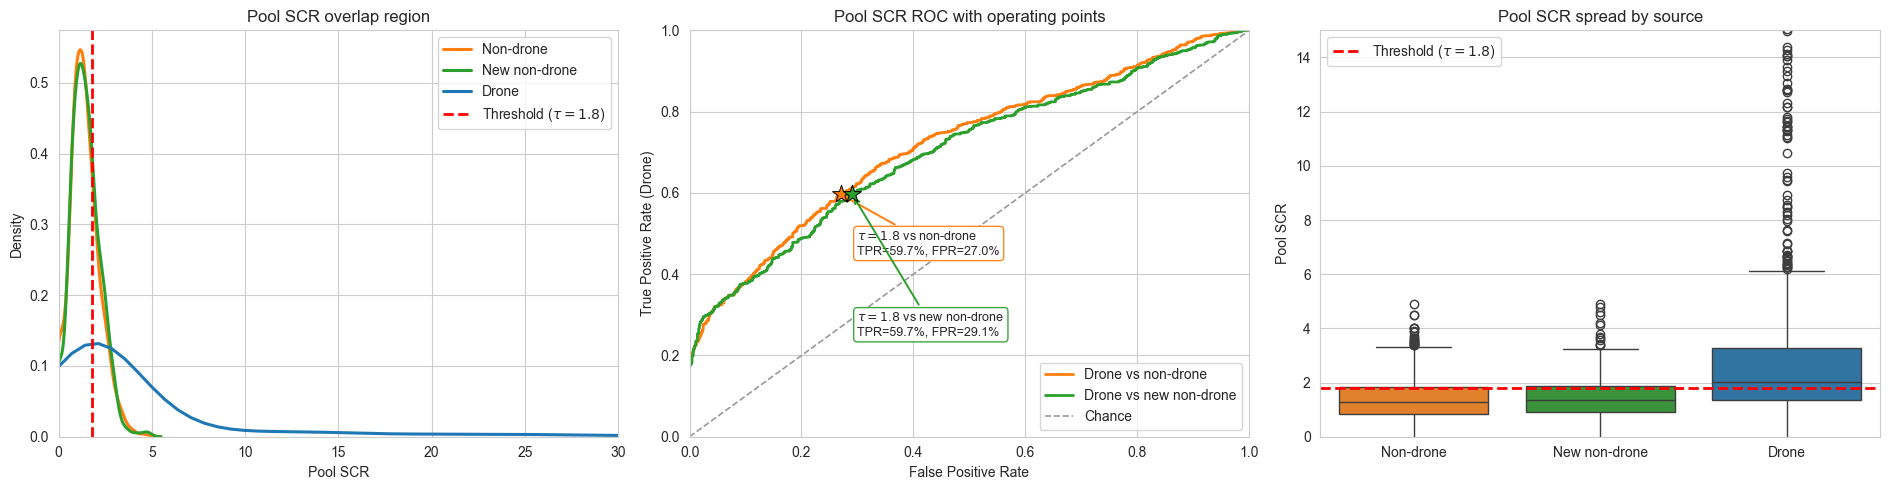

tau_fixed = 1.8
TPR (drone) at tau=1.8        : 0.5965
FPR (non-drone) at tau=1.8    : 0.2702
FPR (new non-drone) at tau=1.8: 0.2907
Saved comparison figure to: RESULTS\eda_exports\scr_core_pool_tau17_comparison.png


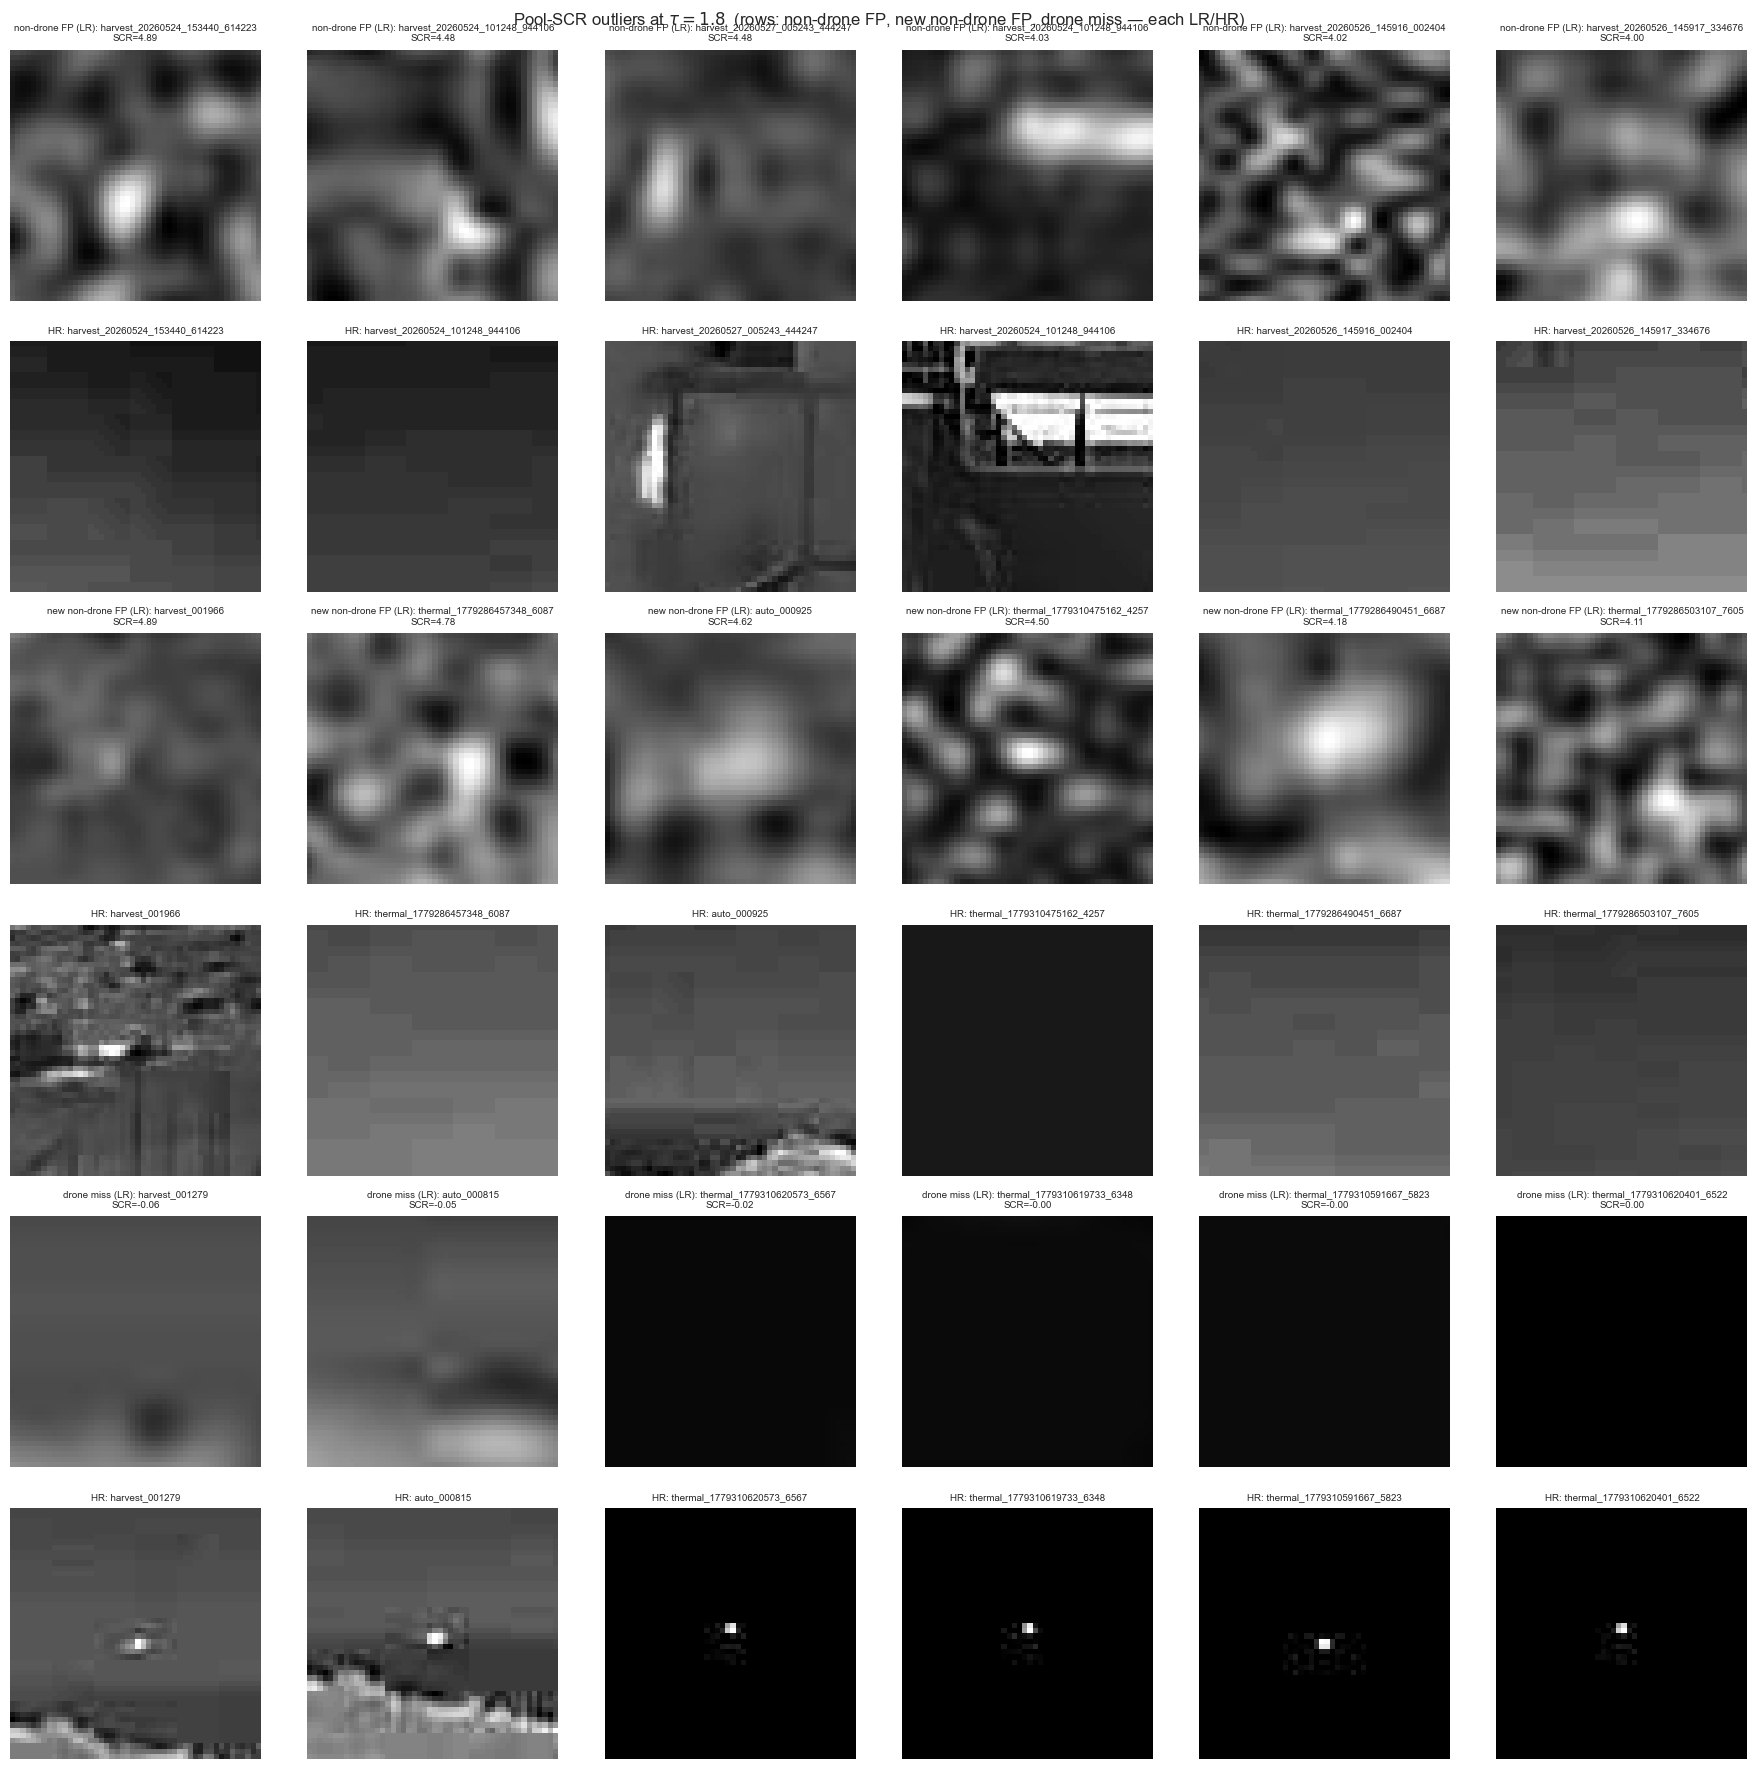

Non-drone false positives (SCR > 1.8)     : 6 shown of 321 total
New non-drone false positives (SCR > 1.8) : 6 shown of 268 total
Drone misses (SCR <= 1.8)                : 6 shown of 372 total
Saved outlier figure to: RESULTS\eda_exports\scr_core_pool_tau17_outliers.png
Saved outlier manifest (source image names) to: RESULTS\eda_exports\scr_core_pool_tau17_outliers.json

HR/LR patch shapes verified identical for all 18 shown examples.


In [18]:
# ── 9c: Pool-SCR tau=1.7 comparison views ───────────────────────────────────────
# Three groups: drone, non-drone, NEW NON DRONE, with a 1.7 operating threshold.

pool_tau_fixed = 1.8
pool_scr_drone_values = drone_core_pool_scr
pool_scr_non_drone_values = non_drone_core_pool_scr
pool_scr_new_non_drone_values = new_non_drone_core_pool_scr

# Threshold-derived operating points at tau = 1.8.
pool_tpr_at_tau33 = float(np.mean(pool_scr_drone_values > pool_tau_fixed))
pool_fpr_at_tau33 = float(np.mean(pool_scr_non_drone_values > pool_tau_fixed))
pool_fpr_new_at_tau33 = float(np.mean(pool_scr_new_non_drone_values > pool_tau_fixed))

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# Panel 1: KDE curves on a linear axis, zoomed to the overlap region.
ax = axes[0]
sns.kdeplot(pool_scr_non_drone_values, color="#ff7f0e", linewidth=2.2, fill=False, label="Non-drone", ax=ax)
sns.kdeplot(pool_scr_new_non_drone_values, color="#2ca02c", linewidth=2.2, fill=False, label="New non-drone", ax=ax)
sns.kdeplot(pool_scr_drone_values, color="#1f77b4", linewidth=2.2, fill=False, label="Drone", ax=ax)
ax.axvline(pool_tau_fixed, color="red", linestyle="--", linewidth=2, label=r"Threshold ($\tau = 1.8$)")
ax.set_xlim(0, 30)
ax.set_xlabel("Pool SCR")
ax.set_ylabel("Density")
ax.set_title("Pool SCR overlap region")
ax.legend(frameon=True)

# Panel 2: one ROC per comparison, each with its tau=1.7 operating point.
ax = axes[1]
ax.plot(pool_fpr_values, pool_tpr_values, color="#ff7f0e", linewidth=2.0, label="Drone vs non-drone")
ax.plot(pool_new_fpr_values, pool_new_tpr_values, color="#2ca02c", linewidth=2.0, label="Drone vs new non-drone")
ax.plot([0, 1], [0, 1], linestyle="--", color="#999999", linewidth=1.2, label="Chance")
ax.scatter([pool_fpr_at_tau33], [pool_tpr_at_tau33], s=180, marker="*", color="#ff7f0e", edgecolors="black", linewidths=0.7, zorder=5)
ax.scatter([pool_fpr_new_at_tau33], [pool_tpr_at_tau33], s=180, marker="*", color="#2ca02c", edgecolors="black", linewidths=0.7, zorder=5)
ax.annotate(
    f"$\\tau = 1.8$ vs non-drone\nTPR={pool_tpr_at_tau33:.1%}, FPR={pool_fpr_at_tau33:.1%}",
    xy=(pool_fpr_at_tau33, pool_tpr_at_tau33),
    xytext=(0.30, 0.45),
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", color="#ff7f0e", lw=1.4),
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#ff7f0e", alpha=0.92),
)
ax.annotate(
    f"$\\tau = 1.8$ vs new non-drone\nTPR={pool_tpr_at_tau33:.1%}, FPR={pool_fpr_new_at_tau33:.1%}",
    xy=(pool_fpr_new_at_tau33, pool_tpr_at_tau33),
    xytext=(0.30, 0.25),
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", color="#2ca02c", lw=1.4),
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#2ca02c", alpha=0.92),
)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Drone)")
ax.set_title("Pool SCR ROC with operating points")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=True, loc="lower right")

# Panel 3: Boxplots showing the spread of Pool SCR values, capped for readability.
ax = axes[2]
sns.boxplot(data=[pool_scr_non_drone_values, pool_scr_new_non_drone_values, pool_scr_drone_values],
            palette=["#ff7f0e", "#2ca02c", "#1f77b4"], ax=ax)
ax.axhline(pool_tau_fixed, color="red", linestyle="--", linewidth=2, label=r"Threshold ($\tau = 1.8$)")
ax.set_ylim(0, 15)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Non-drone", "New non-drone", "Drone"])
ax.set_ylabel("Pool SCR")
ax.set_title("Pool SCR spread by source")
ax.legend(frameon=True)

plt.tight_layout()
plt.savefig(os.path.join(EDA_EXPORT_DIR, "scr_core_pool_tau18_comparison.png"), dpi=160)
plt.show()

print(f"tau_fixed = {pool_tau_fixed:.1f}")
print(f"TPR (drone) at tau=1.8        : {pool_tpr_at_tau33:.4f}")
print(f"FPR (non-drone) at tau=1.8    : {pool_fpr_at_tau33:.4f}")
print(f"FPR (new non-drone) at tau=1.8: {pool_fpr_new_at_tau33:.4f}")
print(f"Saved comparison figure to: {os.path.join(EDA_EXPORT_DIR, 'scr_core_pool_tau17_comparison.png')}")

# ── Outliers at tau = 1.8: false positives of both negative groups + drone misses ──
N_OUTLIER_EXAMPLES = 6


def _top_idx(values, mask_fn, descending):
    idx = np.where(mask_fn(values))[0]
    order = np.argsort(values[idx])
    return idx[order[::-1] if descending else order][:N_OUTLIER_EXAMPLES]


# Rank each group by how far the score sits from the threshold — worst offenders first.
non_drone_fp_idx = _top_idx(pool_scr_non_drone_values, lambda v: v > pool_tau_fixed, True)
new_non_drone_fp_idx = _top_idx(pool_scr_new_non_drone_values, lambda v: v > pool_tau_fixed, True)
drone_miss_idx = _top_idx(pool_scr_drone_values, lambda v: v <= pool_tau_fixed, False)


def _load_hr_patch(record):
    """Crop the same pixel region from the HR image, mapped to the NPY's [-1,1] units so both share one display scale."""
    if "path" not in record:
        return None
    img = cv2.imread(record["path"], cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    return img[record["r0"]:record["r1"], record["c0"]:record["c1"]].astype(np.float32) / 127.5 - 1.0


def _shared_range(lr_patch, hr_patch):
    arrays = [lr_patch] if hr_patch is None else [lr_patch, hr_patch]
    return float(min(a.min() for a in arrays)), float(max(a.max() for a in arrays))


outlier_groups = (
    ("non_drone_fp", "non-drone FP", non_drone_fp_idx, non_drone_patch_records, pool_scr_non_drone_values, "non_drone_false_positives"),
    ("new_non_drone_fp", "new non-drone FP", new_non_drone_fp_idx, new_non_drone_patch_records, pool_scr_new_non_drone_values, "new_non_drone_false_positives"),
    ("drone_miss", "drone miss", drone_miss_idx, drone_patch_records, pool_scr_drone_values, "drone_misses"),
)

fig, axes = plt.subplots(2 * len(outlier_groups), N_OUTLIER_EXAMPLES, figsize=(3 * N_OUTLIER_EXAMPLES, 6 * len(outlier_groups)))
outlier_manifest = {"tau": pool_tau_fixed, **{g[5]: [] for g in outlier_groups}}
_shape_mismatches = []  # (group, stem, lr_shape, hr_shape) for any HR/LR patch pairs that don't match

for g, (group_key, group_label, idx_list, records, scores, manifest_key) in enumerate(outlier_groups):
    for col in range(N_OUTLIER_EXAMPLES):
        ax_lr, ax_hr = axes[2 * g, col], axes[2 * g + 1, col]
        if col < len(idx_list):
            idx = int(idx_list[col])
            record = records[idx]
            hr_patch = _load_hr_patch(record)
            _vmin, _vmax = _shared_range(record["patch"], hr_patch)
            _stem = _extract_stem(Path(record.get("path", "n/a")).name)
            if hr_patch is not None and hr_patch.shape != record["patch"].shape:
                _shape_mismatches.append((group_key, _stem, record["patch"].shape, hr_patch.shape))
            ax_lr.imshow(record["patch"], cmap="gray", vmin=_vmin, vmax=_vmax)
            ax_lr.set_title(f"{group_label} (LR): {_stem}\nSCR={scores[idx]:.2f}", fontsize=7)
            if hr_patch is not None:
                ax_hr.imshow(hr_patch, cmap="gray", vmin=_vmin, vmax=_vmax)
            ax_hr.set_title(f"HR: {_stem}", fontsize=7)
            outlier_manifest[manifest_key].append({
                "index": idx,
                "scr": float(scores[idx]),
                "path": record.get("path", "n/a"),
            })
        ax_lr.axis("off")
        ax_hr.axis("off")

fig.suptitle(f"Pool-SCR outliers at $\\tau = {pool_tau_fixed:.1f}$  (rows: non-drone FP, new non-drone FP, drone miss — each LR/HR)")
plt.tight_layout()
plt.savefig(os.path.join(EDA_EXPORT_DIR, "scr_core_pool_tau17_outliers.png"), dpi=160)
plt.show()

with open(os.path.join(EDA_EXPORT_DIR, "scr_core_pool_tau17_outliers.json"), "w", encoding="utf-8") as f:
    json.dump(outlier_manifest, f, indent=2)

print(f"Non-drone false positives (SCR > {pool_tau_fixed:.1f})     : {len(non_drone_fp_idx)} shown of {int(np.sum(pool_scr_non_drone_values > pool_tau_fixed))} total")
print(f"New non-drone false positives (SCR > {pool_tau_fixed:.1f}) : {len(new_non_drone_fp_idx)} shown of {int(np.sum(pool_scr_new_non_drone_values > pool_tau_fixed))} total")
print(f"Drone misses (SCR <= {pool_tau_fixed:.1f})                : {len(drone_miss_idx)} shown of {int(np.sum(pool_scr_drone_values <= pool_tau_fixed))} total")
print(f"Saved outlier figure to: {os.path.join(EDA_EXPORT_DIR, 'scr_core_pool_tau17_outliers.png')}")
print(f"Saved outlier manifest (source image names) to: {os.path.join(EDA_EXPORT_DIR, 'scr_core_pool_tau17_outliers.json')}")

if _shape_mismatches:
    print(f"\nWARNING: {len(_shape_mismatches)} HR/LR patch shape mismatch(es) in this gallery:")
    for group, stem, lr_shape, hr_shape in _shape_mismatches:
        print(f"  [{group}] {stem}: LR patch shape={lr_shape}  HR patch shape={hr_shape}")
else:
    print(f"\nHR/LR patch shapes verified identical for all {len(non_drone_fp_idx) + len(new_non_drone_fp_idx) + len(drone_miss_idx)} shown examples.")


In [19]:
# ── 10: Hoyer sparsity on core patches ──────────────────────────────────────────
# Hoyer over all PATCH_CORE x PATCH_CORE core pixels after subtracting the ring mean and clipping at 0 (non-negative energy only).
# The energy weight is disabled (kept commented below) so Hoyer measures shape only; SCR already carries the contrast.

HOYER_CORE_SIZE = PATCH_CORE * PATCH_CORE
HOYER_SQRT_N = float(np.sqrt(HOYER_CORE_SIZE))


def collect_hoyer_terms(core_patches, ring_patches):
    hoyer_values = []
    l1_values = []
    l2_values = []
    ring_mean_values = []
    zero_l2_count = 0

    for core, ring in zip(core_patches, ring_patches):
        core_f = core.astype(np.float32).reshape(-1)
        assert core_f.size == HOYER_CORE_SIZE, f"Hoyer expects the full {PATCH_CORE}x{PATCH_CORE} core, got {core_f.size} pixels"
        ring_f = ring.astype(np.float32).reshape(-1)
        ring_mean = float(np.mean(ring_f))
        # ring_std = float(np.std(ring_f))  # only needed by the energy weight below
        core_centered = np.maximum(0.0, core_f - ring_mean)

        l1 = float(np.sum(np.abs(core_centered)))
        l2 = float(np.linalg.norm(core_centered, ord=2))

        if l2 <= 0.0:
            hoyer = 0.0
            zero_l2_count += 1
        else:
            raw_hoyer = (HOYER_SQRT_N - (l1 / l2)) / (HOYER_SQRT_N - 1.0)
            # expected_noise_l2 = np.sqrt(len(core_centered) / 2.0) * ring_std
            # energy_weight = 1.0 / (1.0 + np.exp(-(l2 - expected_noise_l2) / (ring_std + 1e-6)))
            # hoyer = raw_hoyer * energy_weight
            hoyer = raw_hoyer

        hoyer_values.append(hoyer)
        l1_values.append(l1)
        l2_values.append(l2)
        ring_mean_values.append(ring_mean)

    return {
        "hoyer": np.asarray(hoyer_values, dtype=np.float32),
        "l1": np.asarray(l1_values, dtype=np.float32),
        "l2": np.asarray(l2_values, dtype=np.float32),
        "ring_mean": np.asarray(ring_mean_values, dtype=np.float32),
        "zero_l2_count": int(zero_l2_count),
    }


def summarize_metric(values):
    return {
        "count": int(values.size),
        "mean": float(np.mean(values)),
        "std": float(np.std(values)),
        "median": float(np.median(values)),
        "min": float(np.min(values)),
        "max": float(np.max(values)),
    }


drone_hoyer = collect_hoyer_terms(drone_core_patches, drone_ring_patches)
non_drone_hoyer = collect_hoyer_terms(non_drone_core_patches, non_drone_ring_patches)
new_non_drone_hoyer = collect_hoyer_terms(new_non_drone_core_patches, new_non_drone_ring_patches)

hoyer_summary = {
    "drone": summarize_metric(drone_hoyer["hoyer"]),
    "non_drone": summarize_metric(non_drone_hoyer["hoyer"]),
    "new_non_drone": summarize_metric(new_non_drone_hoyer["hoyer"]),
    "meta": {
        "core_size": int(HOYER_CORE_SIZE),
        "sqrt_n": float(HOYER_SQRT_N),
        "ring_centering": "core_minus_ring_mean_clipped_at_zero",
        "energy_weight": "disabled",
        "drone_zero_l2_count": int(drone_hoyer["zero_l2_count"]),
        "non_drone_zero_l2_count": int(non_drone_hoyer["zero_l2_count"]),
        "new_non_drone_zero_l2_count": int(new_non_drone_hoyer["zero_l2_count"]),
    },
}

np.savez_compressed(
    os.path.join(EDA_EXPORT_DIR, "hoyer_metrics.npz"),
    drone_hoyer=drone_hoyer["hoyer"],
    drone_l1=drone_hoyer["l1"],
    drone_l2=drone_hoyer["l2"],
    drone_ring_mean=drone_hoyer["ring_mean"],
    non_drone_hoyer=non_drone_hoyer["hoyer"],
    non_drone_l1=non_drone_hoyer["l1"],
    non_drone_l2=non_drone_hoyer["l2"],
    non_drone_ring_mean=non_drone_hoyer["ring_mean"],
    new_non_drone_hoyer=new_non_drone_hoyer["hoyer"],
    new_non_drone_l1=new_non_drone_hoyer["l1"],
    new_non_drone_l2=new_non_drone_hoyer["l2"],
    new_non_drone_ring_mean=new_non_drone_hoyer["ring_mean"],
)

with open(os.path.join(EDA_EXPORT_DIR, "hoyer_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(hoyer_summary, f, indent=2)

print(f"Hoyer saved to: {os.path.join(EDA_EXPORT_DIR, 'hoyer_metrics.npz')}")
print(f"Hoyer summary saved to: {os.path.join(EDA_EXPORT_DIR, 'hoyer_metrics.json')}")
print(f"Hoyer over all {HOYER_CORE_SIZE} core pixels: core minus ring mean, clipped at 0, no energy weight")
for _key, _label, _h in (("drone", "Drone", drone_hoyer), ("non_drone", "Non-drone", non_drone_hoyer), ("new_non_drone", "New non-drone", new_non_drone_hoyer)):
    print(f"{_label:<14} cores: {_h['hoyer'].size}  zero-L2: {_h['zero_l2_count']}  "
          f"Hoyer mean={hoyer_summary[_key]['mean']:.4f} median={hoyer_summary[_key]['median']:.4f}")


Hoyer saved to: RESULTS\eda_exports\hoyer_metrics.npz
Hoyer summary saved to: RESULTS\eda_exports\hoyer_metrics.json
Hoyer over all 576 core pixels: core minus ring mean, clipped at 0, no energy weight
Drone          cores: 922  zero-L2: 5  Hoyer mean=0.4113 median=0.4123
Non-drone      cores: 1188  zero-L2: 43  Hoyer mean=0.4494 median=0.4519
New non-drone  cores: 922  zero-L2: 21  Hoyer mean=0.4445 median=0.4499


In [20]:
# ── 11: Hoyer statistics ───────────────────────────────────────────────────────
# Report descriptive statistics and a threshold-free separation summary for both negative groups.

non_drone_hoyer_values = non_drone_hoyer["hoyer"]
new_non_drone_hoyer_values = new_non_drone_hoyer["hoyer"]
drone_hoyer_values = drone_hoyer["hoyer"]


def iqr(values):
    q25, q75 = np.percentile(values, [25, 75])
    return float(q75 - q25)


def percentile_map(values, percentiles):
    pct_values = np.percentile(values, percentiles)
    return {f"p{int(p)}": float(v) for p, v in zip(percentiles, pct_values)}


def summarize_distribution(values, percentiles):
    return {
        "count": int(values.size),
        "mean": float(np.mean(values)),
        "median": float(np.median(values)),
        "std": float(np.std(values)),
        "iqr": iqr(values),
        "min": float(np.min(values)),
        "max": float(np.max(values)),
        "percentiles": percentile_map(values, percentiles),
    }


def estimate_auc(positive_scores, negative_scores):
    # AUROC equals the probability that a random drone score exceeds a random negative score.
    comparisons = (positive_scores[:, None] > negative_scores[None, :]).mean()
    ties = (positive_scores[:, None] == negative_scores[None, :]).mean()
    return float(comparisons + 0.5 * ties)


NON_DRONE_PERCENTILES = np.array([90, 95, 99], dtype=np.float32)
DRONE_PERCENTILES = np.array([10, 25, 50], dtype=np.float32)


def separation_summary(drone_pct, negative_pct, negative_values):
    return {
        "auroc": estimate_auc(drone_hoyer_values, negative_values),
        "drone_p10_minus_negative_p90": drone_pct["p10"] - negative_pct["p90"],
        "drone_p25_minus_negative_p95": drone_pct["p25"] - negative_pct["p95"],
        "drone_p50_minus_negative_p99": drone_pct["p50"] - negative_pct["p99"],
    }


non_drone_pct = percentile_map(non_drone_hoyer_values, NON_DRONE_PERCENTILES)
new_non_drone_pct = percentile_map(new_non_drone_hoyer_values, NON_DRONE_PERCENTILES)
drone_pct = percentile_map(drone_hoyer_values, DRONE_PERCENTILES)

hoyer_statistics = {
    "drone": summarize_distribution(drone_hoyer_values, DRONE_PERCENTILES),
    "non_drone": summarize_distribution(non_drone_hoyer_values, NON_DRONE_PERCENTILES),
    "new_non_drone": summarize_distribution(new_non_drone_hoyer_values, NON_DRONE_PERCENTILES),
    "separation": separation_summary(drone_pct, non_drone_pct, non_drone_hoyer_values),
    "separation_vs_new_non_drone": separation_summary(drone_pct, new_non_drone_pct, new_non_drone_hoyer_values),
}

with open(os.path.join(EDA_EXPORT_DIR, "hoyer_statistics.json"), "w", encoding="utf-8") as f:
    json.dump(hoyer_statistics, f, indent=2)

np.savez_compressed(
    os.path.join(EDA_EXPORT_DIR, "hoyer_statistics.npz"),
    drone_hoyer_values=drone_hoyer_values.astype(np.float32),
    non_drone_hoyer_values=non_drone_hoyer_values.astype(np.float32),
    new_non_drone_hoyer_values=new_non_drone_hoyer_values.astype(np.float32),
    drone_selected_percentiles=np.array([drone_pct["p10"], drone_pct["p25"], drone_pct["p50"]], dtype=np.float32),
    non_drone_selected_percentiles=np.array([non_drone_pct["p90"], non_drone_pct["p95"], non_drone_pct["p99"]], dtype=np.float32),
    new_non_drone_selected_percentiles=np.array([new_non_drone_pct["p90"], new_non_drone_pct["p95"], new_non_drone_pct["p99"]], dtype=np.float32),
    separation_auc=np.array([hoyer_statistics["separation"]["auroc"]], dtype=np.float32),
    separation_auc_vs_new_non_drone=np.array([hoyer_statistics["separation_vs_new_non_drone"]["auroc"]], dtype=np.float32),
)

print(f"Hoyer statistics saved to: {os.path.join(EDA_EXPORT_DIR, 'hoyer_statistics.json')}")
print(f"Hoyer statistic arrays saved to: {os.path.join(EDA_EXPORT_DIR, 'hoyer_statistics.npz')}")
print("\nDrone summary:")
print(f"  mean={hoyer_statistics['drone']['mean']:.4f}  median={hoyer_statistics['drone']['median']:.4f}  std={hoyer_statistics['drone']['std']:.4f}  iqr={hoyer_statistics['drone']['iqr']:.4f}")
print(f"  P10={drone_pct['p10']:.4f}  P25={drone_pct['p25']:.4f}  P50={drone_pct['p50']:.4f}")
for _key, _label, _pct, _sep in (
    ("non_drone", "Non-drone", non_drone_pct, "separation"),
    ("new_non_drone", "New non-drone", new_non_drone_pct, "separation_vs_new_non_drone"),
):
    _s = hoyer_statistics[_key]
    print(f"\n{_label} summary:")
    print(f"  mean={_s['mean']:.4f}  median={_s['median']:.4f}  std={_s['std']:.4f}  iqr={_s['iqr']:.4f}")
    print(f"  P90={_pct['p90']:.4f}  P95={_pct['p95']:.4f}  P99={_pct['p99']:.4f}")
    _sp = hoyer_statistics[_sep]
    print(f"  Separation (drone vs {_label.lower()}): AUROC={_sp['auroc']:.4f}  "
          f"P10-P90={_sp['drone_p10_minus_negative_p90']:.4f}  "
          f"P25-P95={_sp['drone_p25_minus_negative_p95']:.4f}  "
          f"P50-P99={_sp['drone_p50_minus_negative_p99']:.4f}")


Hoyer statistics saved to: RESULTS\eda_exports\hoyer_statistics.json
Hoyer statistic arrays saved to: RESULTS\eda_exports\hoyer_statistics.npz

Drone summary:
  mean=0.4113  median=0.4123  std=0.1526  iqr=0.2070
  P10=0.2141  P25=0.3027  P50=0.4123

Non-drone summary:
  mean=0.4494  median=0.4519  std=0.1954  iqr=0.2173
  P90=0.7150  P95=0.7851  P99=0.9159
  Separation (drone vs non-drone): AUROC=0.4358  P10-P90=-0.5009  P25-P95=-0.4824  P50-P99=-0.5036

New non-drone summary:
  mean=0.4445  median=0.4499  std=0.1751  iqr=0.2030
  P90=0.6549  P95=0.7079  P99=0.8997
  Separation (drone vs new non-drone): AUROC=0.4342  P10-P90=-0.4408  P25-P95=-0.4052  P50-P99=-0.4874


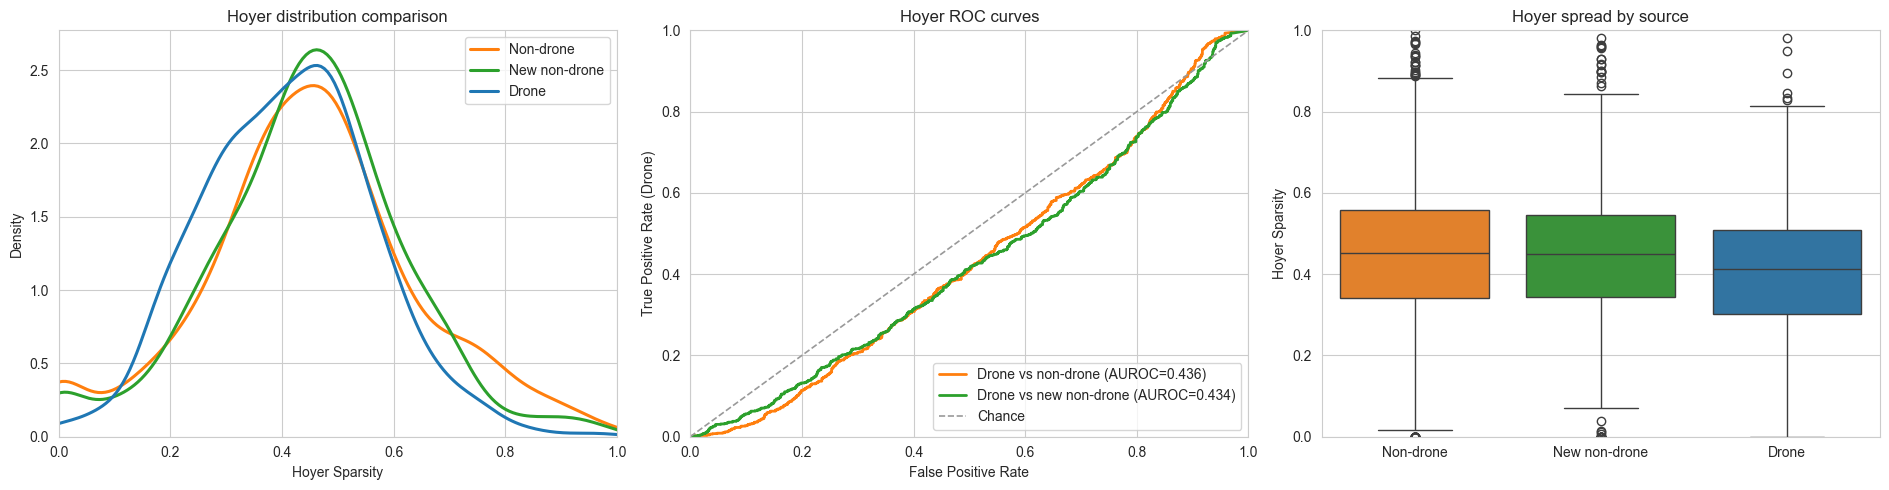

Hoyer comparison figure saved to: RESULTS\eda_exports\hoyer_comparison.png
Hoyer AUROC vs non-drone    : 0.4358
Hoyer AUROC vs new non-drone: 0.4342


In [21]:
# ── 12: Hoyer comparison plots ─────────────────────────────────────────────────
# Compare drone, non-drone and NEW NON DRONE Hoyer distributions without selecting a fixed threshold.


def estimate_roc_curve(positive_scores, negative_scores):
    thresholds = np.unique(np.concatenate([positive_scores, negative_scores]))
    thresholds = np.sort(thresholds)
    tpr = np.array([np.mean(positive_scores >= tau) for tau in thresholds], dtype=np.float32)
    fpr = np.array([np.mean(negative_scores >= tau) for tau in thresholds], dtype=np.float32)
    return thresholds, tpr, fpr


hoyer_thresholds_plot, hoyer_tpr_plot, hoyer_fpr_plot = estimate_roc_curve(drone_hoyer_values, non_drone_hoyer_values)
hoyer_auc_plot = estimate_auc(drone_hoyer_values, non_drone_hoyer_values)
hoyer_new_thresholds_plot, hoyer_new_tpr_plot, hoyer_new_fpr_plot = estimate_roc_curve(drone_hoyer_values, new_non_drone_hoyer_values)
hoyer_new_auc_plot = estimate_auc(drone_hoyer_values, new_non_drone_hoyer_values)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# Panel 1: KDE comparison on the natural Hoyer range.
ax = axes[0]
sns.kdeplot(non_drone_hoyer_values, color="#ff7f0e", linewidth=2.2, fill=False, label="Non-drone", ax=ax)
sns.kdeplot(new_non_drone_hoyer_values, color="#2ca02c", linewidth=2.2, fill=False, label="New non-drone", ax=ax)
sns.kdeplot(drone_hoyer_values, color="#1f77b4", linewidth=2.2, fill=False, label="Drone", ax=ax)
ax.set_xlim(0, 1)
ax.set_xlabel("Hoyer Sparsity")
ax.set_ylabel("Density")
ax.set_title("Hoyer distribution comparison")
ax.legend(frameon=True)

# Panel 2: ROC curves without a fixed operating threshold.
ax = axes[1]
ax.plot(hoyer_fpr_plot, hoyer_tpr_plot, color="#ff7f0e", linewidth=2.0, label=f"Drone vs non-drone (AUROC={hoyer_auc_plot:.3f})")
ax.plot(hoyer_new_fpr_plot, hoyer_new_tpr_plot, color="#2ca02c", linewidth=2.0, label=f"Drone vs new non-drone (AUROC={hoyer_new_auc_plot:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="#999999", linewidth=1.2, label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Drone)")
ax.set_title("Hoyer ROC curves")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=True, loc="lower right")

# Panel 3: Boxplots of Hoyer values by source.
ax = axes[2]
sns.boxplot(data=[non_drone_hoyer_values, new_non_drone_hoyer_values, drone_hoyer_values], palette=["#ff7f0e", "#2ca02c", "#1f77b4"], ax=ax)
ax.set_ylim(0, 1)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Non-drone", "New non-drone", "Drone"])
ax.set_ylabel("Hoyer Sparsity")
ax.set_title("Hoyer spread by source")

plt.tight_layout()
plt.savefig(os.path.join(EDA_EXPORT_DIR, "hoyer_comparison.png"), dpi=160)
plt.show()

print(f"Hoyer comparison figure saved to: {os.path.join(EDA_EXPORT_DIR, 'hoyer_comparison.png')}")
print(f"Hoyer AUROC vs non-drone    : {hoyer_auc_plot:.4f}")
print(f"Hoyer AUROC vs new non-drone: {hoyer_new_auc_plot:.4f}")


In [22]:
# ── 13: Hoyer hypothesis tests (drone vs non-drone, drone vs new non-drone) ─────
# Compare the Hoyer distributions with a mean test and a median-focused test.

from scipy import stats as scipy_stats


def hoyer_group_tests(drone_values, other_values, other_name):
    """Welch t-test + Mood median test of drone Hoyer against one negative group."""
    d = np.asarray(drone_values, dtype=np.float64)
    o = np.asarray(other_values, dtype=np.float64)
    d, o = d[np.isfinite(d)], o[np.isfinite(o)]

    welch_t = scipy_stats.ttest_ind(d, o, equal_var=False, alternative="two-sided")
    d_mean, o_mean = float(np.mean(d)), float(np.mean(o))
    mean_diff = d_mean - o_mean
    d_var, o_var = float(np.var(d, ddof=1)), float(np.var(o, ddof=1))
    d_n, o_n = int(d.size), int(o.size)

    df_num = (d_var / d_n + o_var / o_n) ** 2
    df_den = ((d_var / d_n) ** 2) / (d_n - 1) + ((o_var / o_n) ** 2) / (o_n - 1)
    welch_df = float(df_num / df_den)
    mean_diff_se = float(np.sqrt(d_var / d_n + o_var / o_n))
    t_crit = float(scipy_stats.t.ppf(0.975, welch_df))

    pooled_sd = float(np.sqrt(((d_n - 1) * d_var + (o_n - 1) * o_var) / (d_n + o_n - 2)))
    cohens_d = float(mean_diff / pooled_sd) if pooled_sd > 0 else 0.0

    d_med, o_med = float(np.median(d)), float(np.median(o))
    med_stat, med_p, grand_med, med_table = scipy_stats.median_test(d, o, ties="below")

    return {
        "mean_test": {
            "test": "Welch two-sample t-test",
            "null_hypothesis": f"drone and {other_name} Hoyer means are equal",
            "drone_count": d_n,
            f"{other_name}_count": o_n,
            "drone_mean": d_mean,
            f"{other_name}_mean": o_mean,
            "mean_difference": mean_diff,
            "t_statistic": float(welch_t.statistic),
            "p_value": float(welch_t.pvalue),
            "degrees_of_freedom": welch_df,
            "mean_difference_95ci": [float(mean_diff - t_crit * mean_diff_se), float(mean_diff + t_crit * mean_diff_se)],
            "cohens_d": cohens_d,
        },
        "median_test": {
            "test": "Mood median test",
            "null_hypothesis": f"drone and {other_name} Hoyer medians are equal",
            "drone_count": d_n,
            f"{other_name}_count": o_n,
            "drone_median": d_med,
            f"{other_name}_median": o_med,
            "median_difference": d_med - o_med,
            "grand_median": float(grand_med),
            "chi2_statistic": float(med_stat),
            "p_value": float(med_p),
            "contingency_table": med_table.astype(int).tolist(),
        },
    }


drone_hoyer_arr = np.asarray(drone_hoyer_values, dtype=np.float64)
non_drone_hoyer_arr = np.asarray(non_drone_hoyer_values, dtype=np.float64)
new_non_drone_hoyer_arr = np.asarray(new_non_drone_hoyer_values, dtype=np.float64)
drone_hoyer_arr = drone_hoyer_arr[np.isfinite(drone_hoyer_arr)]
non_drone_hoyer_arr = non_drone_hoyer_arr[np.isfinite(non_drone_hoyer_arr)]
new_non_drone_hoyer_arr = new_non_drone_hoyer_arr[np.isfinite(new_non_drone_hoyer_arr)]

hoyer_tests = hoyer_group_tests(drone_hoyer_arr, non_drone_hoyer_arr, "non_drone")
hoyer_tests_new = hoyer_group_tests(drone_hoyer_arr, new_non_drone_hoyer_arr, "new_non_drone")
hoyer_tests["vs_new_non_drone"] = hoyer_tests_new

with open(os.path.join(EDA_EXPORT_DIR, "hoyer_ttest.json"), "w", encoding="utf-8") as f:
    json.dump(hoyer_tests, f, indent=2)


def _test_arrays(prefix, tests, other_name):
    mt, md = tests["mean_test"], tests["median_test"]
    return {
        f"{prefix}t_statistic": np.array([mt["t_statistic"]], dtype=np.float32),
        f"{prefix}t_p_value": np.array([mt["p_value"]], dtype=np.float64),
        f"{prefix}degrees_of_freedom": np.array([mt["degrees_of_freedom"]], dtype=np.float32),
        f"{prefix}mean_difference": np.array([mt["mean_difference"]], dtype=np.float32),
        f"{prefix}cohens_d": np.array([mt["cohens_d"]], dtype=np.float32),
        f"{prefix}median_chi2": np.array([md["chi2_statistic"]], dtype=np.float32),
        f"{prefix}median_p_value": np.array([md["p_value"]], dtype=np.float64),
        f"{prefix}drone_median": np.array([md["drone_median"]], dtype=np.float32),
        f"{prefix}{other_name}_median": np.array([md[f"{other_name}_median"]], dtype=np.float32),
        f"{prefix}median_difference": np.array([md["median_difference"]], dtype=np.float32),
        f"{prefix}grand_median": np.array([md["grand_median"]], dtype=np.float32),
    }


np.savez_compressed(
    os.path.join(EDA_EXPORT_DIR, "hoyer_ttest.npz"),
    drone_hoyer_values=drone_hoyer_arr.astype(np.float32),
    non_drone_hoyer_values=non_drone_hoyer_arr.astype(np.float32),
    new_non_drone_hoyer_values=new_non_drone_hoyer_arr.astype(np.float32),
    **_test_arrays("", hoyer_tests, "non_drone"),
    **_test_arrays("new_non_drone_", hoyer_tests_new, "new_non_drone"),
)

print(f"Hoyer hypothesis tests saved to: {os.path.join(EDA_EXPORT_DIR, 'hoyer_ttest.json')}")
print(f"Hoyer hypothesis test arrays saved to: {os.path.join(EDA_EXPORT_DIR, 'hoyer_ttest.npz')}")
for _title, _name, _tests in (("drone vs NON-DRONE", "non_drone", hoyer_tests), ("drone vs NEW NON-DRONE", "new_non_drone", hoyer_tests_new)):
    mt, md = _tests["mean_test"], _tests["median_test"]
    print(f"\n══ {_title} ══")
    print("Welch two-sample t-test:")
    print(f"  drone mean = {mt['drone_mean']:.4f}   {_name} mean = {mt[_name + '_mean']:.4f}   diff = {mt['mean_difference']:.4f}")
    print(f"  t = {mt['t_statistic']:.4f}  df = {mt['degrees_of_freedom']:.2f}  p-value = {mt['p_value']:.6g}")
    print(f"  95% CI for mean diff = [{mt['mean_difference_95ci'][0]:.4f}, {mt['mean_difference_95ci'][1]:.4f}]  Cohen's d = {mt['cohens_d']:.4f}")
    print("Mood median test:")
    print(f"  drone median = {md['drone_median']:.4f}   {_name} median = {md[_name + '_median']:.4f}   diff = {md['median_difference']:.4f}")
    print(f"  grand median = {md['grand_median']:.4f}  chi2 = {md['chi2_statistic']:.4f}  p-value = {md['p_value']:.6g}")


Hoyer hypothesis tests saved to: RESULTS\eda_exports\hoyer_ttest.json
Hoyer hypothesis test arrays saved to: RESULTS\eda_exports\hoyer_ttest.npz

══ drone vs NON-DRONE ══
Welch two-sample t-test:
  drone mean = 0.4113   non_drone mean = 0.4494   diff = -0.0381
  t = -5.0286  df = 2107.90  p-value = 5.3568e-07
  95% CI for mean diff = [-0.0530, -0.0232]  Cohen's d = -0.2141
Mood median test:
  drone median = 0.4123   non_drone median = 0.4519   diff = -0.0397
  grand median = 0.4344  chi2 = 14.5805  p-value = 0.000134294

══ drone vs NEW NON-DRONE ══
Welch two-sample t-test:
  drone mean = 0.4113   new_non_drone mean = 0.4445   diff = -0.0332
  t = -4.3400  df = 1808.17  p-value = 1.50328e-05
  95% CI for mean diff = [-0.0482, -0.0182]  Cohen's d = -0.2021
Mood median test:
  drone median = 0.4123   new_non_drone median = 0.4499   diff = -0.0376
  grand median = 0.4349  chi2 = 17.9631  p-value = 2.25226e-05


In [23]:
# ── 14: Hoyer statistics inside the pool-SCR window ─────────────────────────────
# Compare Hoyer of the three groups only for patches with 1.7 <= pool SCR <= 2.5.

POOL_SCR_LOWER = 1.8
POOL_SCR_UPPER = 5000


def summarize_metric_or_empty(values):
    if values.size == 0:
        return {
            "count": 0,
            "mean": None,
            "std": None,
            "median": None,
            "min": None,
            "max": None,
        }
    return summarize_metric(values)


def pool_window_mask(scr_values):
    return (scr_values >= POOL_SCR_LOWER) & (scr_values <= POOL_SCR_UPPER)


def window_gaps(drone_window, other_window):
    both = drone_window.size > 0 and other_window.size > 0
    return {
        "count_gap": int(drone_window.size - other_window.size),
        "mean_gap": float(np.mean(drone_window) - np.mean(other_window)) if both else None,
        "median_gap": float(np.median(drone_window) - np.median(other_window)) if both else None,
    }


drone_pool_scr_window_mask = pool_window_mask(drone_core_pool_scr)
non_drone_pool_scr_window_mask = pool_window_mask(non_drone_core_pool_scr)
new_non_drone_pool_scr_window_mask = pool_window_mask(new_non_drone_core_pool_scr)

drone_hoyer_pool_window = drone_hoyer["hoyer"][drone_pool_scr_window_mask]
non_drone_hoyer_pool_window = non_drone_hoyer["hoyer"][non_drone_pool_scr_window_mask]
new_non_drone_hoyer_pool_window = new_non_drone_hoyer["hoyer"][new_non_drone_pool_scr_window_mask]

hoyer_pool_scr_window_stats = {
    "window": {
        "pool_scr_lower": POOL_SCR_LOWER,
        "pool_scr_upper": POOL_SCR_UPPER,
        "interval": f"[{POOL_SCR_LOWER}, {POOL_SCR_UPPER}]",
    },
    "drone": {
        **summarize_metric_or_empty(drone_hoyer_pool_window),
        "selection_rate": float(np.mean(drone_pool_scr_window_mask)),
    },
    "non_drone": {
        **summarize_metric_or_empty(non_drone_hoyer_pool_window),
        "selection_rate": float(np.mean(non_drone_pool_scr_window_mask)),
    },
    "new_non_drone": {
        **summarize_metric_or_empty(new_non_drone_hoyer_pool_window),
        "selection_rate": float(np.mean(new_non_drone_pool_scr_window_mask)),
    },
    "comparison": window_gaps(drone_hoyer_pool_window, non_drone_hoyer_pool_window),
    "comparison_vs_new_non_drone": window_gaps(drone_hoyer_pool_window, new_non_drone_hoyer_pool_window),
}

np.savez_compressed(
    os.path.join(EDA_EXPORT_DIR, "hoyer_pool_scr_window_stats.npz"),
    drone_hoyer_pool_window=drone_hoyer_pool_window.astype(np.float32),
    non_drone_hoyer_pool_window=non_drone_hoyer_pool_window.astype(np.float32),
    new_non_drone_hoyer_pool_window=new_non_drone_hoyer_pool_window.astype(np.float32),
    drone_pool_scr_window_mask=drone_pool_scr_window_mask.astype(bool),
    non_drone_pool_scr_window_mask=non_drone_pool_scr_window_mask.astype(bool),
    new_non_drone_pool_scr_window_mask=new_non_drone_pool_scr_window_mask.astype(bool),
)

with open(os.path.join(EDA_EXPORT_DIR, "hoyer_pool_scr_window_stats.json"), "w", encoding="utf-8") as f:
    json.dump(hoyer_pool_scr_window_stats, f, indent=2)

print(f"Pool-window Hoyer stats saved to: {os.path.join(EDA_EXPORT_DIR, 'hoyer_pool_scr_window_stats.json')}")
print(f"Hoyer stats for {POOL_SCR_LOWER} <= pool SCR <= {POOL_SCR_UPPER}:")
for _key, _label in (("drone", "Drone"), ("non_drone", "Non-drone"), ("new_non_drone", "New non-drone")):
    _s = hoyer_pool_scr_window_stats[_key]
    if _s["count"] == 0:
        print(f"  {_label:<14} count=0  selection_rate={_s['selection_rate']:.4f}")
    else:
        print(f"  {_label:<14} count={_s['count']}  selection_rate={_s['selection_rate']:.4f}  mean={_s['mean']:.4f}  median={_s['median']:.4f}")
for _key, _label in (("comparison", "drone - non-drone"), ("comparison_vs_new_non_drone", "drone - new non-drone")):
    _g = hoyer_pool_scr_window_stats[_key]
    if _g["mean_gap"] is not None:
        print(f"  {_label}: mean_gap={_g['mean_gap']:.4f}  median_gap={_g['median_gap']:.4f}")
    else:
        print(f"  {_label}: gaps unavailable because one group has no samples in the window.")


Pool-window Hoyer stats saved to: RESULTS\eda_exports\hoyer_pool_scr_window_stats.json
Hoyer stats for 1.8 <= pool SCR <= 5000:
  Drone          count=550  selection_rate=0.5965  mean=0.3873  median=0.3949
  Non-drone      count=321  selection_rate=0.2702  mean=0.4077  median=0.4144
  New non-drone  count=268  selection_rate=0.2907  mean=0.4062  median=0.4257
  drone - non-drone: mean_gap=-0.0204  median_gap=-0.0195
  drone - new non-drone: mean_gap=-0.0189  median_gap=-0.0308


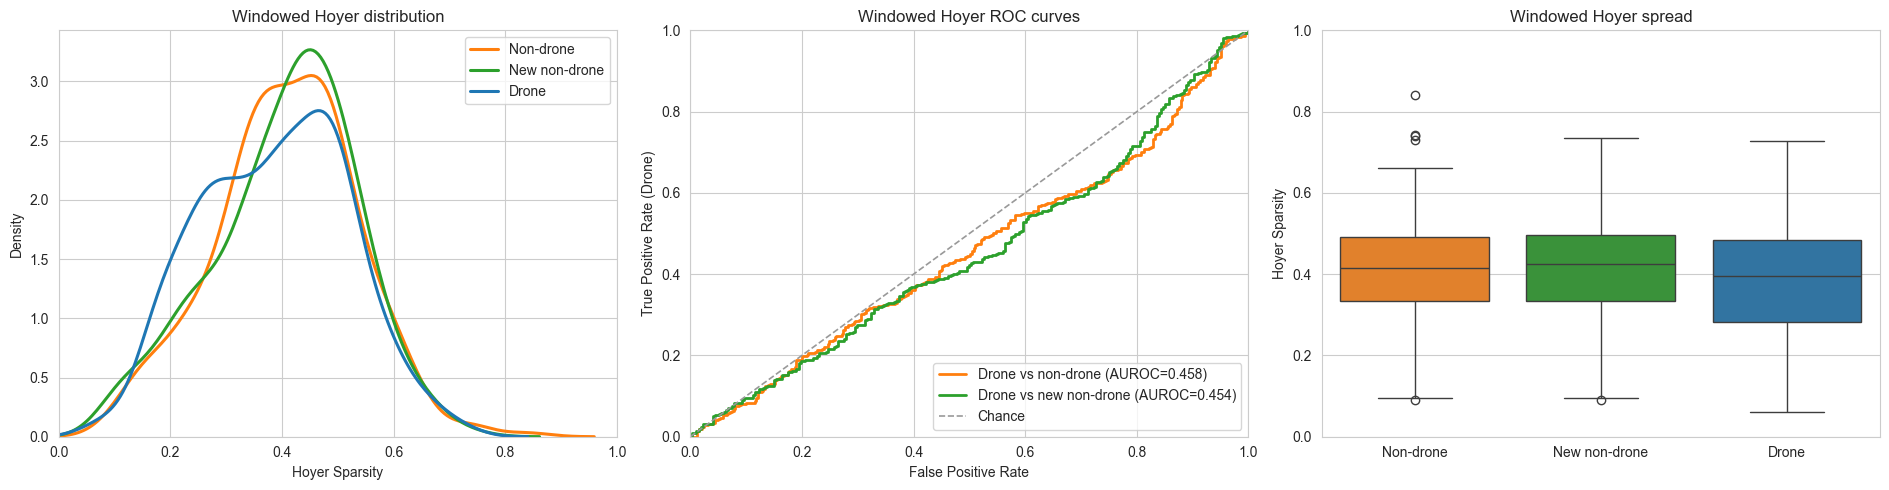

Windowed Hoyer comparison figure saved to: RESULTS\eda_exports\hoyer_pool_scr_window_comparison.png
Windowed Hoyer AUROC vs non-drone    : 0.4575
Windowed Hoyer AUROC vs new non-drone: 0.4543
Window sizes -> drone: 550, non_drone: 321, new_non_drone: 268


In [24]:
# ── 15: Hoyer plots inside the pool-SCR window ──────────────────────────────────
# Compare Hoyer of the three groups only for patches with 1.7 <= pool SCR <= 2.5.

if min(drone_hoyer_pool_window.size, non_drone_hoyer_pool_window.size, new_non_drone_hoyer_pool_window.size) == 0:
    raise ValueError("Need non-empty drone, non-drone and new non-drone subsets to plot Hoyer inside the pool-SCR window.")

window_hoyer_thresholds, window_hoyer_tpr, window_hoyer_fpr = estimate_roc_curve(
    drone_hoyer_pool_window,
    non_drone_hoyer_pool_window,
)
window_hoyer_auc = estimate_auc(drone_hoyer_pool_window, non_drone_hoyer_pool_window)
window_hoyer_new_thresholds, window_hoyer_new_tpr, window_hoyer_new_fpr = estimate_roc_curve(
    drone_hoyer_pool_window,
    new_non_drone_hoyer_pool_window,
)
window_hoyer_new_auc = estimate_auc(drone_hoyer_pool_window, new_non_drone_hoyer_pool_window)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# Panel 1: KDE comparison on the windowed Hoyer subset.
ax = axes[0]
sns.kdeplot(non_drone_hoyer_pool_window, color="#ff7f0e", linewidth=2.2, fill=False, label="Non-drone", ax=ax)
sns.kdeplot(new_non_drone_hoyer_pool_window, color="#2ca02c", linewidth=2.2, fill=False, label="New non-drone", ax=ax)
sns.kdeplot(drone_hoyer_pool_window, color="#1f77b4", linewidth=2.2, fill=False, label="Drone", ax=ax)
ax.set_xlim(0, 1)
ax.set_xlabel("Hoyer Sparsity")
ax.set_ylabel("Density")
ax.set_title("Windowed Hoyer distribution")
ax.legend(frameon=True)

# Panel 2: ROC curves on the same windowed subsets.
ax = axes[1]
ax.plot(window_hoyer_fpr, window_hoyer_tpr, color="#ff7f0e", linewidth=2.0, label=f"Drone vs non-drone (AUROC={window_hoyer_auc:.3f})")
ax.plot(window_hoyer_new_fpr, window_hoyer_new_tpr, color="#2ca02c", linewidth=2.0, label=f"Drone vs new non-drone (AUROC={window_hoyer_new_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="#999999", linewidth=1.2, label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Drone)")
ax.set_title("Windowed Hoyer ROC curves")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=True, loc="lower right")

# Panel 3: Boxplots of the windowed Hoyer values.
ax = axes[2]
sns.boxplot(data=[non_drone_hoyer_pool_window, new_non_drone_hoyer_pool_window, drone_hoyer_pool_window], palette=["#ff7f0e", "#2ca02c", "#1f77b4"], ax=ax)
ax.set_ylim(0, 1)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Non-drone", "New non-drone", "Drone"])
ax.set_ylabel("Hoyer Sparsity")
ax.set_title("Windowed Hoyer spread")

plt.tight_layout()
plt.savefig(os.path.join(EDA_EXPORT_DIR, "hoyer_pool_scr_window_comparison.png"), dpi=160)
plt.show()

print(f"Windowed Hoyer comparison figure saved to: {os.path.join(EDA_EXPORT_DIR, 'hoyer_pool_scr_window_comparison.png')}")
print(f"Windowed Hoyer AUROC vs non-drone    : {window_hoyer_auc:.4f}")
print(f"Windowed Hoyer AUROC vs new non-drone: {window_hoyer_new_auc:.4f}")
print(f"Window sizes -> drone: {drone_hoyer_pool_window.size}, non_drone: {non_drone_hoyer_pool_window.size}, new_non_drone: {new_non_drone_hoyer_pool_window.size}")


In [25]:
# ── 16: Sparsity features on noise-thresholded cores (complements SCR) ──────────
# z = (core - ring_mean) / sigma_ring, keep only pixels above k sigma, then measure how few / how compact the survivors are.
# Patches with fewer than SPARSITY_MIN_SUPPORT survivors carry no target evidence and get score 0 for every feature.
from scipy import ndimage
from scipy.stats import spearmanr

SPARSITY_K_SWEEP = (1.0, 1.5, 2.0, 3.0)
SPARSITY_K = 2.0
SPARSITY_MIN_SUPPORT = 3
SPARSITY_FEATURES = ("hoyer_thr", "l0_sparsity", "compactness")
_CONN8 = np.ones((3, 3), dtype=int)


def sparsity_features(core, ring_mean, sigma, k):
    z = (core.astype(np.float32) - ring_mean) / sigma
    s = np.maximum(0.0, z - k)
    mask = s > 0
    support = int(mask.sum())
    if support < SPARSITY_MIN_SUPPORT:
        return 0.0, 0.0, 0.0, support
    l1 = float(s.sum())
    l2 = float(np.sqrt((s ** 2).sum()))
    hoyer_thr = (HOYER_SQRT_N - l1 / l2) / (HOYER_SQRT_N - 1.0)
    l0_sparsity = 1.0 - support / HOYER_CORE_SIZE
    labels, _ = ndimage.label(mask, structure=_CONN8)
    compactness = float(np.bincount(labels.ravel())[1:].max()) / support
    return hoyer_thr, l0_sparsity, compactness, support


def collect_sparsity(core_patches, ring_terms, sigma_stable, k):
    rows = [sparsity_features(c, m, s, k) for c, m, s in zip(core_patches, ring_terms["bg_mean"], sigma_stable)]
    arr = np.asarray(rows, dtype=np.float32)
    out = {name: arr[:, i] for i, name in enumerate(SPARSITY_FEATURES)}
    out["support"] = arr[:, 3].astype(np.int32)
    return out


_SPARSITY_INPUTS = {
    "drone": (drone_core_patches, drone_ring_terms, drone_bg_std_stable, drone_core_pool_scr, drone_pool_scr_window_mask),
    "non_drone": (non_drone_core_patches, non_drone_ring_terms, non_drone_bg_std_stable, non_drone_core_pool_scr, non_drone_pool_scr_window_mask),
    "new_non_drone": (new_non_drone_core_patches, new_non_drone_ring_terms, new_non_drone_bg_std_stable, new_non_drone_core_pool_scr, new_non_drone_pool_scr_window_mask),
}


def run_sparsity(k):
    return {g: collect_sparsity(v[0], v[1], v[2], k) for g, v in _SPARSITY_INPUTS.items()}


# Sanity check: pure noise must score ~0; a compact blob on noise must score high.
_rng = np.random.default_rng(0)
_noise = _rng.normal(0.0, 1.0, (PATCH_CORE, PATCH_CORE)).astype(np.float32)
_yy, _xx = np.mgrid[:PATCH_CORE, :PATCH_CORE]
_blob = _noise + 6.0 * np.exp(-((_yy - 12) ** 2 + (_xx - 12) ** 2) / (2 * 1.5 ** 2))
print(f"Sanity (k={SPARSITY_K}) {SPARSITY_FEATURES}")
print("  gaussian noise :", np.round(sparsity_features(_noise, 0.0, 1.0, SPARSITY_K)[:3], 3))
print("  blob on noise  :", np.round(sparsity_features(_blob, 0.0, 1.0, SPARSITY_K)[:3], 3))

# Sweep k: AUROC (drone as positive) for every feature, on all patches and inside the SCR window.
print(f"\nAUROC sweep (SCR window = [{POOL_SCR_LOWER}, {POOL_SCR_UPPER}]); columns: vs non-drone / vs new non-drone, all | windowed")
sweep_results = {}
for _k in SPARSITY_K_SWEEP:
    _res = run_sparsity(_k)
    for _feat in SPARSITY_FEATURES:
        _d, _n, _nn = _res["drone"][_feat], _res["non_drone"][_feat], _res["new_non_drone"][_feat]
        _dw = _d[_SPARSITY_INPUTS["drone"][4]]
        _nw = _n[_SPARSITY_INPUTS["non_drone"][4]]
        _nnw = _nn[_SPARSITY_INPUTS["new_non_drone"][4]]
        _row = {
            "auc_non": estimate_auc(_d, _n), "auc_new": estimate_auc(_d, _nn),
            "auc_non_window": estimate_auc(_dw, _nw), "auc_new_window": estimate_auc(_dw, _nnw),
        }
        sweep_results[f"k={_k}/{_feat}"] = _row
        print(f"  k={_k:<3} {_feat:<12} {_row['auc_non']:.3f} / {_row['auc_new']:.3f}  |  {_row['auc_non_window']:.3f} / {_row['auc_new_window']:.3f}")

# Final features at SPARSITY_K, correlation with SCR to confirm the information is complementary.
sparsity = run_sparsity(SPARSITY_K)
scr_all = {g: _SPARSITY_INPUTS[g][3] for g in _SPARSITY_INPUTS}
correlations = {}
print(f"\nGroup coverage and Spearman correlation with pool-SCR (k={SPARSITY_K}):")
for _g in _SPARSITY_INPUTS:
    _valid = float(np.mean(sparsity[_g]["support"] >= SPARSITY_MIN_SUPPORT))
    _corr = {f: float(spearmanr(sparsity[_g][f], scr_all[_g])[0]) for f in SPARSITY_FEATURES}
    correlations[_g] = {"valid_fraction": _valid, **_corr}
    print(f"  {_g:<14} patches with >= {SPARSITY_MIN_SUPPORT} survivors: {_valid:.1%}  " + "  ".join(f"{f}: {_corr[f]:+.2f}" for f in SPARSITY_FEATURES))

np.savez_compressed(
    os.path.join(EDA_EXPORT_DIR, "sparsity_metrics.npz"),
    **{f"{_g}_{_f}": sparsity[_g][_f] for _g in sparsity for _f in (*SPARSITY_FEATURES, "support")},
)
with open(os.path.join(EDA_EXPORT_DIR, "sparsity_metrics.json"), "w", encoding="utf-8") as f:
    json.dump({"k": SPARSITY_K, "min_support": SPARSITY_MIN_SUPPORT, "sweep": sweep_results, "correlation_with_scr": correlations}, f, indent=2)
print(f"\nSparsity metrics saved to: {os.path.join(EDA_EXPORT_DIR, 'sparsity_metrics.json')}")


Sanity (k=2.0) ('hoyer_thr', 'l0_sparsity', 'compactness')
  gaussian noise : [0.948 0.984 0.222]
  blob on noise  : [0.889 0.955 0.654]

AUROC sweep (SCR window = [1.8, 5000]); columns: vs non-drone / vs new non-drone, all | windowed
  k=1.0 hoyer_thr    0.462 / 0.454  |  0.367 / 0.343
  k=1.0 l0_sparsity  0.455 / 0.448  |  0.336 / 0.321
  k=1.0 compactness  0.599 / 0.603  |  0.578 / 0.628
  k=1.5 hoyer_thr    0.587 / 0.564  |  0.322 / 0.292
  k=1.5 l0_sparsity  0.585 / 0.563  |  0.308 / 0.287
  k=1.5 compactness  0.658 / 0.653  |  0.577 / 0.617


  k=2.0 hoyer_thr    0.627 / 0.605  |  0.355 / 0.312
  k=2.0 l0_sparsity  0.627 / 0.605  |  0.352 / 0.312
  k=2.0 compactness  0.660 / 0.652  |  0.552 / 0.573
  k=3.0 hoyer_thr    0.629 / 0.624  |  0.645 / 0.634
  k=3.0 l0_sparsity  0.628 / 0.624  |  0.645 / 0.634
  k=3.0 compactness  0.634 / 0.631  |  0.677 / 0.674

Group coverage and Spearman correlation with pool-SCR (k=2.0):
  drone          patches with >= 3 survivors: 55.4%  hoyer_thr: +0.62  l0_sparsity: +0.61  compactness: +0.80
  non_drone      patches with >= 3 survivors: 24.2%  hoyer_thr: +0.71  l0_sparsity: +0.71  compactness: +0.73
  new_non_drone  patches with >= 3 survivors: 27.0%  hoyer_thr: +0.73  l0_sparsity: +0.73  compactness: +0.75

Sparsity metrics saved to: RESULTS\eda_exports\sparsity_metrics.json


In [26]:
# ── 17: Differentiable compactness (usable as a guidance term on a dense score map) ──
# Connected components cannot be back-propagated; this uses a sigmoid mask and a 5x5 box sum, which map 1:1 to torch avg_pool2d.
SOFT_T = 0.25          # sigmoid temperature in sigma units
PEAK_WIN = 5           # px — side of the box that must hold the target energy
SOFT_MIN_SUPPORT = 3.0 # soft pixel count below which the patch carries no target evidence


def soft_peak_concentration(core, ring_mean, sigma, k, t=SOFT_T, win=PEAK_WIN):
    z = (core.astype(np.float32) - ring_mean) / sigma
    m = 1.0 / (1.0 + np.exp(-(z - k) / t))
    total = float(m.sum())
    in_box = ndimage.uniform_filter(m, size=win, mode="constant") * (win * win)
    return float(in_box.max()) / max(total, SOFT_MIN_SUPPORT)


def collect_soft_peak(group, k, win=PEAK_WIN):
    cores, ring_terms, sigma = _SPARSITY_INPUTS[group][:3]
    return np.asarray([soft_peak_concentration(c, m, s, k, win=win) for c, m, s in zip(cores, ring_terms["bg_mean"], sigma)], dtype=np.float32)


print(f"Sanity: noise={soft_peak_concentration(_noise, 0.0, 1.0, SPARSITY_K):.3f}  blob={soft_peak_concentration(_blob, 0.0, 1.0, SPARSITY_K):.3f}")
print(f"\nSoft peak concentration AUROC (window={PEAK_WIN}px); columns: vs non-drone / vs new non-drone, all | windowed")
soft_peak_results = {}
for _win in (3, 5, 7):
    for _k in SPARSITY_K_SWEEP:
        _v = {g: collect_soft_peak(g, _k, _win) for g in _SPARSITY_INPUTS}
        _w = {g: _v[g][_SPARSITY_INPUTS[g][4]] for g in _v}
        _row = {
            "auc_non": estimate_auc(_v["drone"], _v["non_drone"]), "auc_new": estimate_auc(_v["drone"], _v["new_non_drone"]),
            "auc_non_window": estimate_auc(_w["drone"], _w["non_drone"]), "auc_new_window": estimate_auc(_w["drone"], _w["new_non_drone"]),
            "spearman_scr_drone": float(spearmanr(_v["drone"], scr_all["drone"])[0]),
        }
        soft_peak_results[f"win={_win}/k={_k}"] = _row
        print(f"  win={_win} k={_k:<3} {_row['auc_non']:.3f} / {_row['auc_new']:.3f}  |  {_row['auc_non_window']:.3f} / {_row['auc_new_window']:.3f}   rho(SCR, drone)={_row['spearman_scr_drone']:+.2f}")

with open(os.path.join(EDA_EXPORT_DIR, "soft_peak_concentration.json"), "w", encoding="utf-8") as f:
    json.dump(soft_peak_results, f, indent=2)


Sanity: noise=0.191  blob=0.482

Soft peak concentration AUROC (window=5px); columns: vs non-drone / vs new non-drone, all | windowed


  win=3 k=1.0 0.354 / 0.352  |  0.331 / 0.317   rho(SCR, drone)=-0.59
  win=3 k=1.5 0.402 / 0.389  |  0.313 / 0.295   rho(SCR, drone)=-0.42
  win=3 k=2.0 0.517 / 0.494  |  0.301 / 0.278   rho(SCR, drone)=+0.04


  win=3 k=3.0 0.674 / 0.652  |  0.442 / 0.417   rho(SCR, drone)=+0.77


  win=5 k=1.0 0.375 / 0.370  |  0.338 / 0.325   rho(SCR, drone)=-0.51
  win=5 k=1.5 0.433 / 0.417  |  0.328 / 0.312   rho(SCR, drone)=-0.30
  win=5 k=2.0 0.549 / 0.524  |  0.327 / 0.304   rho(SCR, drone)=+0.15


  win=5 k=3.0 0.687 / 0.666  |  0.508 / 0.486   rho(SCR, drone)=+0.82


  win=7 k=1.0 0.404 / 0.396  |  0.361 / 0.351   rho(SCR, drone)=-0.42
  win=7 k=1.5 0.468 / 0.452  |  0.363 / 0.353   rho(SCR, drone)=-0.18


  win=7 k=2.0 0.581 / 0.558  |  0.372 / 0.359   rho(SCR, drone)=+0.26


  win=7 k=3.0 0.696 / 0.677  |  0.556 / 0.544   rho(SCR, drone)=+0.85


In [27]:
# ── 18: Differentiable blob-ness (connected multi-pixel blob vs isolated hot pixels) ──
# soft_count: soft number of pixels above k sigma. neighbour_density: share of that mass with bright 3x3 neighbours
# (soft analogue of the largest connected component); both are sigmoid + 3x3 box filter, i.e. avg_pool2d in torch.
BLOB_FEATURES = ("soft_count", "neighbour_density")


def blob_features(core, ring_mean, sigma, k, t=SOFT_T):
    z = (core.astype(np.float32) - ring_mean) / sigma
    m = 1.0 / (1.0 + np.exp(-(z - k) / t))
    total = float(m.sum())
    neigh = float((m * ndimage.uniform_filter(m, size=3, mode="constant")).sum())
    return total, neigh / max(total, SOFT_MIN_SUPPORT)


def collect_blob(group, k):
    cores, ring_terms, sigma = _SPARSITY_INPUTS[group][:3]
    arr = np.asarray([blob_features(c, m, s, k) for c, m, s in zip(cores, ring_terms["bg_mean"], sigma)], dtype=np.float32)
    return {name: arr[:, i] for i, name in enumerate(BLOB_FEATURES)}


print(f"Sanity (k={SPARSITY_K}) {BLOB_FEATURES}")
print("  gaussian noise :", np.round(blob_features(_noise, 0.0, 1.0, SPARSITY_K), 3))
print("  blob on noise  :", np.round(blob_features(_blob, 0.0, 1.0, SPARSITY_K), 3))

print("\nBlob-ness AUROC (drone positive); columns: vs non-drone / vs new non-drone, all | windowed   + Spearman with SCR inside the window (drone)")
blob_results = {}
for _k in SPARSITY_K_SWEEP:
    _v = {g: collect_blob(g, _k) for g in _SPARSITY_INPUTS}
    for _feat in BLOB_FEATURES:
        _a = {g: _v[g][_feat] for g in _v}
        _w = {g: _a[g][_SPARSITY_INPUTS[g][4]] for g in _a}
        _row = {
            "auc_non": estimate_auc(_a["drone"], _a["non_drone"]), "auc_new": estimate_auc(_a["drone"], _a["new_non_drone"]),
            "auc_non_window": estimate_auc(_w["drone"], _w["non_drone"]), "auc_new_window": estimate_auc(_w["drone"], _w["new_non_drone"]),
            "spearman_scr_window_drone": float(spearmanr(_w["drone"], scr_all["drone"][_SPARSITY_INPUTS["drone"][4]])[0]),
        }
        blob_results[f"k={_k}/{_feat}"] = _row
        print(f"  k={_k:<3} {_feat:<18} {_row['auc_non']:.3f} / {_row['auc_new']:.3f}  |  {_row['auc_non_window']:.3f} / {_row['auc_new_window']:.3f}   rho(SCR|window)={_row['spearman_scr_window_drone']:+.2f}")

with open(os.path.join(EDA_EXPORT_DIR, "blob_features.json"), "w", encoding="utf-8") as f:
    json.dump(blob_results, f, indent=2)


Sanity (k=2.0) ('soft_count', 'neighbour_density')
  gaussian noise : [17.606  0.078]
  blob on noise  : [33.999  0.359]

Blob-ness AUROC (drone positive); columns: vs non-drone / vs new non-drone, all | windowed   + Spearman with SCR inside the window (drone)
  k=1.0 soft_count         0.707 / 0.694  |  0.671 / 0.685   rho(SCR|window)=+0.56
  k=1.0 neighbour_density  0.719 / 0.708  |  0.683 / 0.714   rho(SCR|window)=+0.75


  k=1.5 soft_count         0.720 / 0.706  |  0.692 / 0.710   rho(SCR|window)=+0.72
  k=1.5 neighbour_density  0.722 / 0.710  |  0.714 / 0.736   rho(SCR|window)=+0.91


  k=2.0 soft_count         0.724 / 0.710  |  0.709 / 0.725   rho(SCR|window)=+0.87
  k=2.0 neighbour_density  0.722 / 0.707  |  0.716 / 0.725   rho(SCR|window)=+0.97
  k=3.0 soft_count         0.724 / 0.709  |  0.716 / 0.721   rho(SCR|window)=+0.97
  k=3.0 neighbour_density  0.722 / 0.706  |  0.713 / 0.712   rho(SCR|window)=+0.99


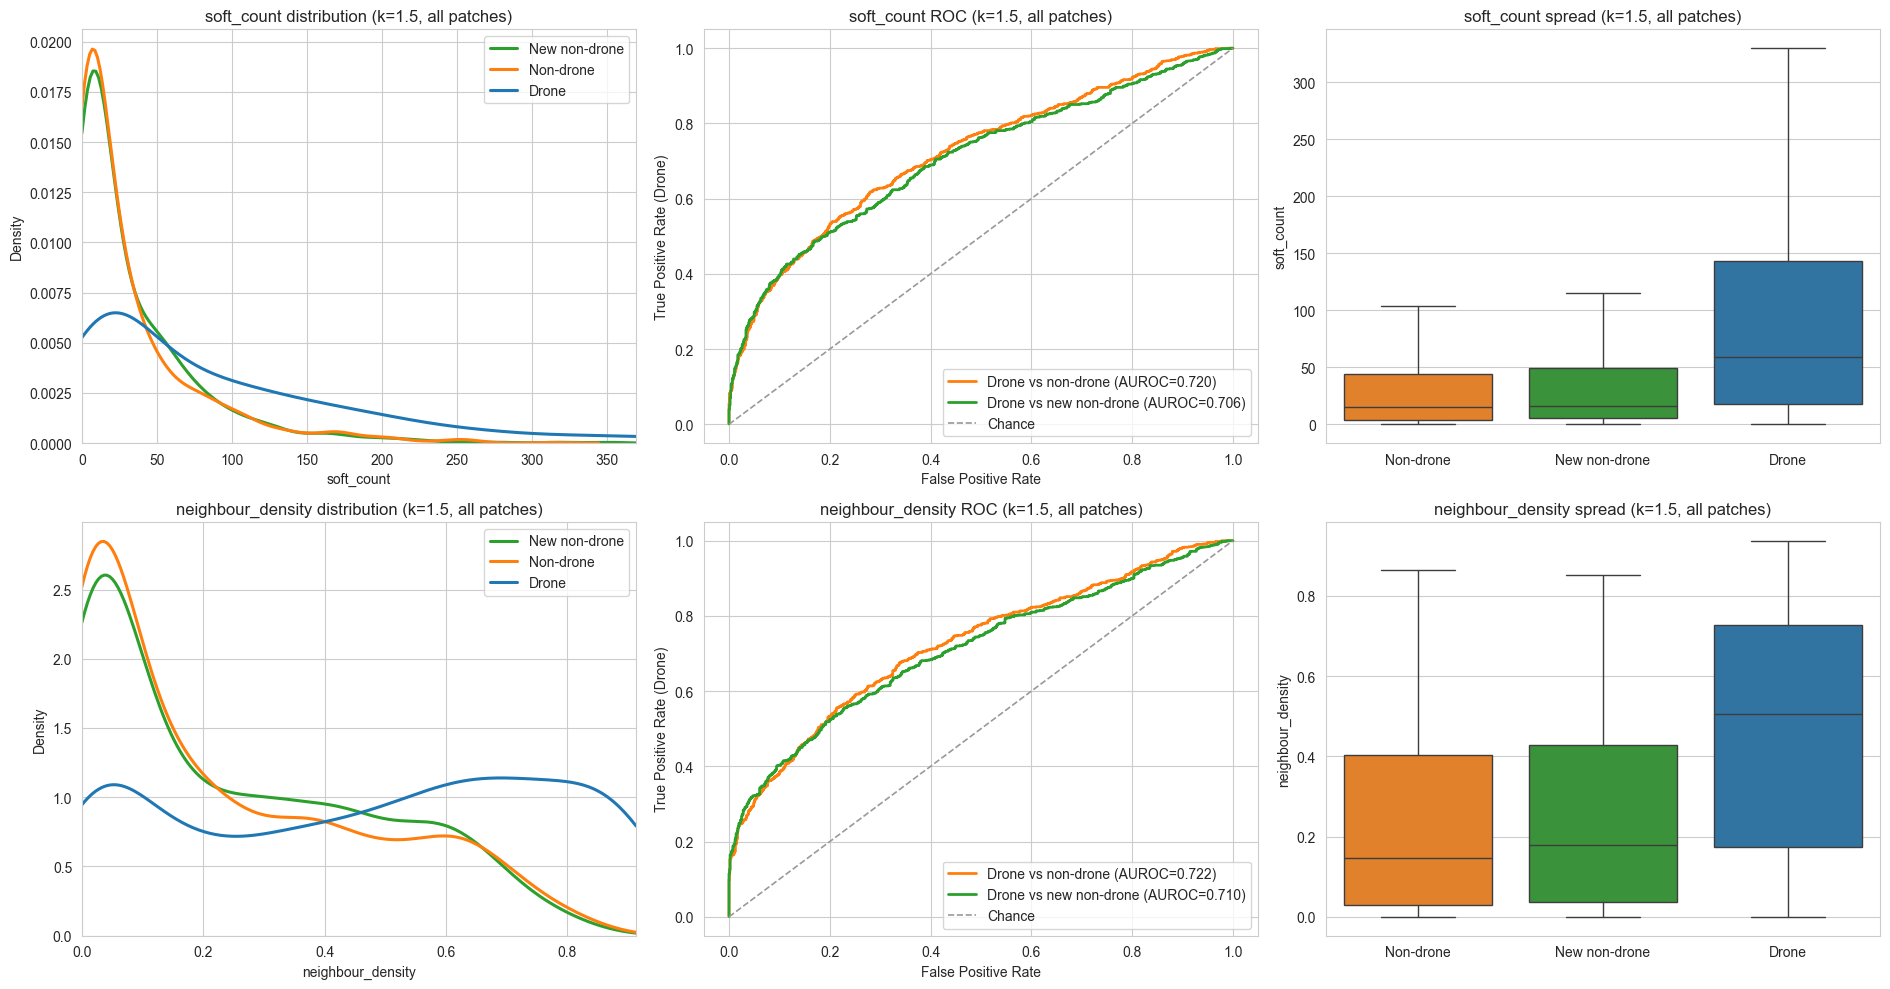

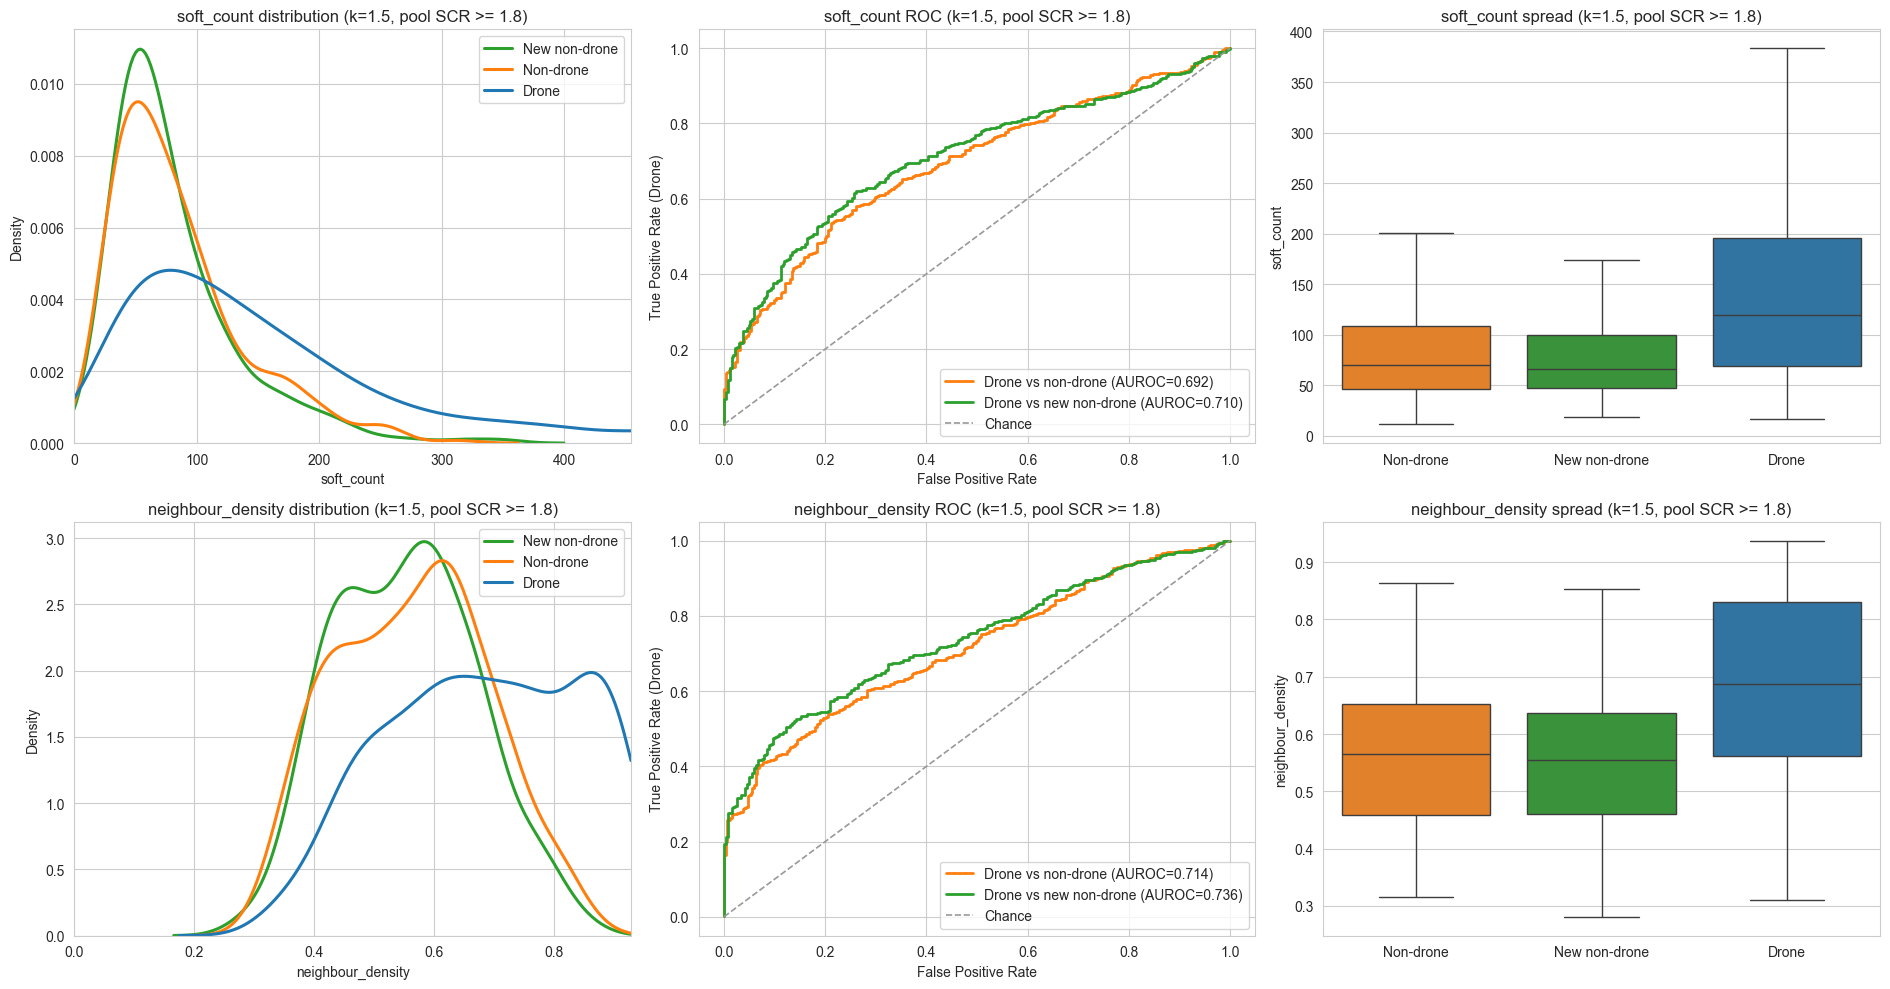

Pool SCR alone AUROC: vs non-drone 0.720 / vs new non-drone 0.705
soft_count         AUROC all: 0.720 / 0.706   windowed: 0.692 / 0.710
neighbour_density  AUROC all: 0.722 / 0.710   windowed: 0.714 / 0.736

Gate = pool SCR >= 1.8; rule = gate AND feature >= tau_feature   (rates over ALL patches of each group)
  SCR gate only                    TPR=0.597  FPR non-drone=0.270  FPR new non-drone=0.291
  soft_count         youden   tau= 105.959  TPR=0.341  FPR non-drone=0.068  FPR new non-drone=0.065
  soft_count         neg_p75  tau= 103.753  TPR=0.346  FPR non-drone=0.072  FPR new non-drone=0.068
  soft_count         neg_p90  tau= 162.000  TPR=0.208  FPR non-drone=0.030  FPR new non-drone=0.025
  neighbour_density  youden   tau=   0.680  TPR=0.312  FPR non-drone=0.051  FPR new non-drone=0.041
  neighbour_density  neg_p75  tau=   0.645  TPR=0.348  FPR non-drone=0.073  FPR new non-drone=0.066
  neighbour_density  neg_p90  tau=   0.719  TPR=0.258  FPR non-drone=0.031  FPR new non-drone=0.02

In [28]:
# ── 19: Blob-ness plots (all patches + inside the SCR window) and guidance thresholds ──
BLOB_K = 1.5
_GROUPS = ("drone", "non_drone", "new_non_drone")
_COLORS = {"drone": "#1f77b4", "non_drone": "#ff7f0e", "new_non_drone": "#2ca02c"}
_LABELS = {"drone": "Drone", "non_drone": "Non-drone", "new_non_drone": "New non-drone"}

blob_final = {g: collect_blob(g, BLOB_K) for g in _GROUPS}
_masks = {g: _SPARSITY_INPUTS[g][4] for g in _GROUPS}
blob_all = {g: blob_final[g] for g in _GROUPS}
blob_win = {g: {f: blob_final[g][f][_masks[g]] for f in BLOB_FEATURES} for g in _GROUPS}


def blob_figure(values, title, fname):
    fig, axes = plt.subplots(len(BLOB_FEATURES), 3, figsize=(19, 5 * len(BLOB_FEATURES)))
    aucs = {}
    for r, feat in enumerate(BLOB_FEATURES):
        d, n, nn = (values[g][feat] for g in _GROUPS)
        auc_n, auc_nn = estimate_auc(d, n), estimate_auc(d, nn)
        aucs[feat] = (auc_n, auc_nn)
        hi = float(np.percentile(np.concatenate([d, n, nn]), 99))

        ax = axes[r, 0]
        for g, v in zip(_GROUPS[::-1], (nn, n, d)):
            sns.kdeplot(v, color=_COLORS[g], linewidth=2.2, label=_LABELS[g], ax=ax, clip=(0, hi))
        ax.set_xlim(0, hi)
        ax.set_xlabel(feat)
        ax.set_title(f"{feat} distribution {title}")
        ax.legend(frameon=True)

        ax = axes[r, 1]
        _, tpr, fpr = estimate_roc_curve(d, n)
        ax.plot(fpr, tpr, color=_COLORS["non_drone"], linewidth=2.0, label=f"Drone vs non-drone (AUROC={auc_n:.3f})")
        _, tpr, fpr = estimate_roc_curve(d, nn)
        ax.plot(fpr, tpr, color=_COLORS["new_non_drone"], linewidth=2.0, label=f"Drone vs new non-drone (AUROC={auc_nn:.3f})")
        ax.plot([0, 1], [0, 1], linestyle="--", color="#999999", linewidth=1.2, label="Chance")
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate (Drone)")
        ax.set_title(f"{feat} ROC {title}")
        ax.legend(frameon=True, loc="lower right")

        ax = axes[r, 2]
        sns.boxplot(data=[n, nn, d], palette=[_COLORS["non_drone"], _COLORS["new_non_drone"], _COLORS["drone"]], showfliers=False, ax=ax)
        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels(["Non-drone", "New non-drone", "Drone"])
        ax.set_ylabel(feat)
        ax.set_title(f"{feat} spread {title}")
    plt.tight_layout()
    plt.savefig(os.path.join(EDA_EXPORT_DIR, fname), dpi=160)
    plt.show()
    return aucs


auc_all = blob_figure(blob_all, f"(k={BLOB_K}, all patches)", "blob_features_comparison.png")
auc_win = blob_figure(blob_win, f"(k={BLOB_K}, pool SCR >= {POOL_SCR_LOWER})", "blob_features_pool_scr_window_comparison.png")

# Reference: pool SCR on its own.
_scr = {g: _SPARSITY_INPUTS[g][3] for g in _GROUPS}
print(f"Pool SCR alone AUROC: vs non-drone {estimate_auc(_scr['drone'], _scr['non_drone']):.3f} / vs new non-drone {estimate_auc(_scr['drone'], _scr['new_non_drone']):.3f}")
for feat in BLOB_FEATURES:
    print(f"{feat:<18} AUROC all: {auc_all[feat][0]:.3f} / {auc_all[feat][1]:.3f}   windowed: {auc_win[feat][0]:.3f} / {auc_win[feat][1]:.3f}")

# Thresholds: chosen inside the SCR window (the guidance applies blob-ness only where SCR already fires).
print(f"\nGate = pool SCR >= {POOL_SCR_LOWER}; rule = gate AND feature >= tau_feature   (rates over ALL patches of each group)")
print(f"  SCR gate only                    TPR={np.mean(_masks['drone']):.3f}  FPR non-drone={np.mean(_masks['non_drone']):.3f}  FPR new non-drone={np.mean(_masks['new_non_drone']):.3f}")
guidance_thresholds = {"k": BLOB_K, "scr_gate": POOL_SCR_LOWER, "features": {}}
for feat in BLOB_FEATURES:
    d_w = blob_win["drone"][feat]
    neg_w = np.concatenate([blob_win["non_drone"][feat], blob_win["new_non_drone"][feat]])
    cand = np.unique(np.concatenate([d_w, neg_w]))
    youden = [(float(np.mean(d_w >= t) - np.mean(neg_w >= t)), float(t)) for t in cand]
    best_j, tau_j = max(youden)
    taus = {"youden": tau_j, "neg_p75": float(np.percentile(neg_w, 75)), "neg_p90": float(np.percentile(neg_w, 90))}
    guidance_thresholds["features"][feat] = {}
    for name, tau in taus.items():
        rates = {g: float(np.mean(_masks[g] & (blob_final[g][feat] >= tau))) for g in _GROUPS}
        guidance_thresholds["features"][feat][name] = {"tau": tau, **rates}
        print(f"  {feat:<18} {name:<8} tau={tau:8.3f}  TPR={rates['drone']:.3f}  FPR non-drone={rates['non_drone']:.3f}  FPR new non-drone={rates['new_non_drone']:.3f}")

with open(os.path.join(EDA_EXPORT_DIR, "blob_guidance_thresholds.json"), "w", encoding="utf-8") as f:
    json.dump(guidance_thresholds, f, indent=2)


SCR gate=1.8; feature 'high' = negative P90: nd>=0.611, soft_count>=88.2;  'low' = negative P50: nd<0.159, soft_count<15.5

Patches: drone=922, negatives=2110.  Drones below the gate: 40.3%; negatives below the gate: 72.1%

RESCUE  (SCR < gate AND feature high) — share of all drones vs all negatives, and the ratio (>1 means the feature finds drones SCR misses)
  nd     drones= 0.000  negatives= 0.000  ratio=  inf
  sc     drones= 0.008  negatives= 0.006  ratio= 1.33
  nd&sc  drones= 0.000  negatives= 0.000  ratio=  inf

FILTER  (SCR >= gate AND feature low) — share removed; ratio neg/drone > 1 means it removes more false than true detections
  nd     drones= 0.000  negatives= 0.000  ratio neg/drone=  inf
  sc     drones= 0.000  negatives= 0.000  ratio neg/drone=  inf
  nd|sc  drones= 0.000  negatives= 0.000  ratio neg/drone=  inf

Feature AUROC inside SCR bins (drone vs negatives; counts in brackets)
SCR bin     drone    neg  nd AUROC  sc AUROC
[-inf, 1.0)    144    684     0.560     0

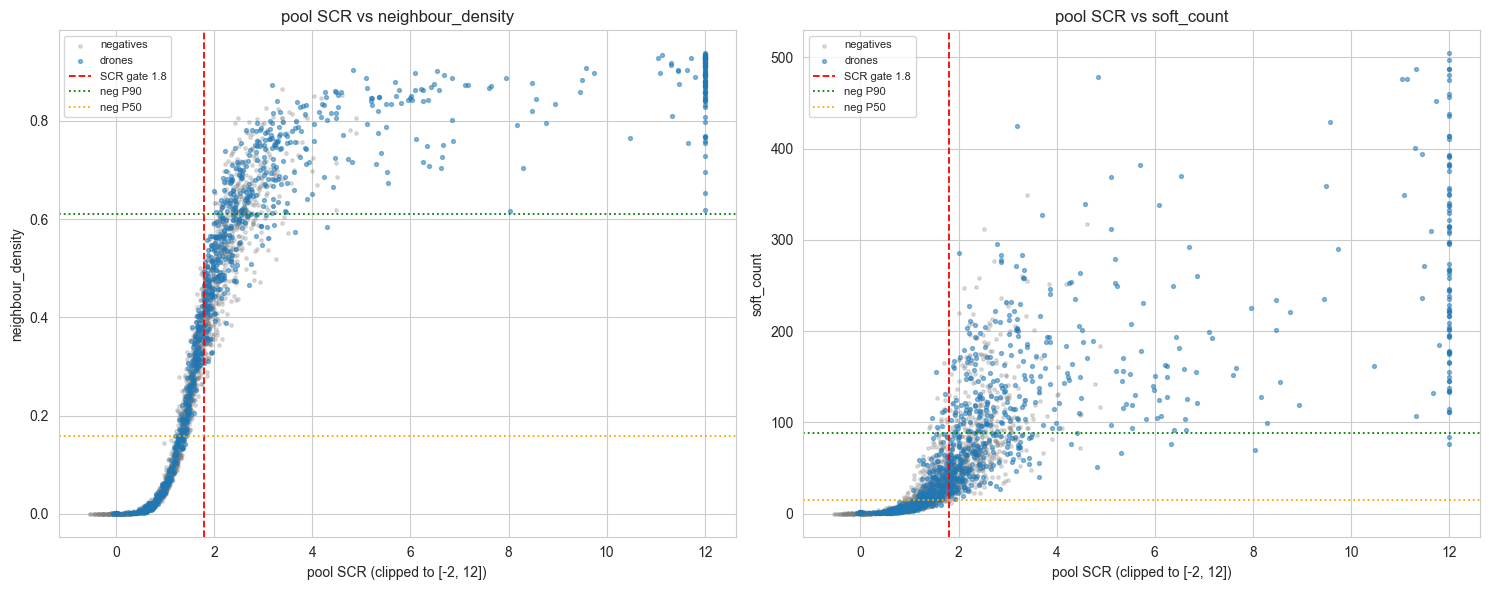

In [29]:
# ── 20: SCR vs blob metrics — rescue (SCR below gate, blob high) and filter (SCR above gate, blob low) ──
SCR_GATE = 1.8
Q_HIGH = 0.90   # a feature is "high" when it exceeds this quantile of ALL negative patches
Q_LOW = 0.50    # a feature is "low" when it is below this quantile of ALL negative patches
_NEGS = ("non_drone", "new_non_drone")

_neg = {k: np.concatenate([a[g] for g in _NEGS]) for k, a in (
    ("scr", _scr), ("nd", {g: blob_final[g]["neighbour_density"] for g in _GROUPS}), ("sc", {g: blob_final[g]["soft_count"] for g in _GROUPS}))}
_drn = {"scr": _scr["drone"], "nd": blob_final["drone"]["neighbour_density"], "sc": blob_final["drone"]["soft_count"]}
TAU_HIGH = {k: float(np.quantile(_neg[k], Q_HIGH)) for k in ("nd", "sc")}
TAU_LOW = {k: float(np.quantile(_neg[k], Q_LOW)) for k in ("nd", "sc")}
print(f"SCR gate={SCR_GATE}; feature 'high' = negative P{int(Q_HIGH * 100)}: nd>={TAU_HIGH['nd']:.3f}, soft_count>={TAU_HIGH['sc']:.1f};  'low' = negative P{int(Q_LOW * 100)}: nd<{TAU_LOW['nd']:.3f}, soft_count<{TAU_LOW['sc']:.1f}")

hi = {k: (_drn[k] >= TAU_HIGH[k], _neg[k] >= TAU_HIGH[k]) for k in ("nd", "sc")}
lo = {k: (_drn[k] < TAU_LOW[k], _neg[k] < TAU_LOW[k]) for k in ("nd", "sc")}
hi["nd&sc"] = (hi["nd"][0] & hi["sc"][0], hi["nd"][1] & hi["sc"][1])
lo["nd|sc"] = (lo["nd"][0] | lo["sc"][0], lo["nd"][1] | lo["sc"][1])
below = (_drn["scr"] < SCR_GATE, _neg["scr"] < SCR_GATE)
above = (~below[0], ~below[1])

print(f"\nPatches: drone={_drn['scr'].size}, negatives={_neg['scr'].size}.  Drones below the gate: {below[0].mean():.1%}; negatives below the gate: {below[1].mean():.1%}")
print("\nRESCUE  (SCR < gate AND feature high) — share of all drones vs all negatives, and the ratio (>1 means the feature finds drones SCR misses)")
rescue = {}
for name, (h_d, h_n) in hi.items():
    rd, rn = float(np.mean(below[0] & h_d)), float(np.mean(below[1] & h_n))
    rescue[name] = {"drone": rd, "neg": rn}
    print(f"  {name:<6} drones={rd:6.3f}  negatives={rn:6.3f}  ratio={rd / rn if rn else float('inf'):5.2f}")

print("\nFILTER  (SCR >= gate AND feature low) — share removed; ratio neg/drone > 1 means it removes more false than true detections")
filt = {}
for name, (l_d, l_n) in lo.items():
    fd, fn = float(np.mean(above[0] & l_d)), float(np.mean(above[1] & l_n))
    filt[name] = {"drone": fd, "neg": fn}
    print(f"  {name:<6} drones={fd:6.3f}  negatives={fn:6.3f}  ratio neg/drone={fn / fd if fd else float('inf'):5.2f}")

# Feature AUROC inside SCR bins: does the feature separate drones from negatives at a fixed SCR level?
print("\nFeature AUROC inside SCR bins (drone vs negatives; counts in brackets)")
print(f"{'SCR bin':<10} {'drone':>6} {'neg':>6} {'nd AUROC':>9} {'sc AUROC':>9}")
bins = [(-np.inf, 1.0), (1.0, 1.5), (1.5, 1.8), (1.8, 2.5), (2.5, 4.0), (4.0, np.inf)]
bin_results = []
for lo_b, hi_b in bins:
    md, mn = (_drn["scr"] >= lo_b) & (_drn["scr"] < hi_b), (_neg["scr"] >= lo_b) & (_neg["scr"] < hi_b)
    if md.sum() >= 20 and mn.sum() >= 20:
        a_nd, a_sc = estimate_auc(_drn["nd"][md], _neg["nd"][mn]), estimate_auc(_drn["sc"][md], _neg["sc"][mn])
    else:
        a_nd = a_sc = float("nan")
    bin_results.append({"lo": float(lo_b), "hi": float(hi_b), "drone": int(md.sum()), "neg": int(mn.sum()), "auc_nd": a_nd, "auc_sc": a_sc})
    print(f"[{lo_b:>4.1f},{hi_b:>4.1f}) {md.sum():6d} {mn.sum():6d} {a_nd:9.3f} {a_sc:9.3f}")

# Rules: TPR/FPR and the TPR of a single SCR threshold at the same FPR.
def scr_only_tpr(fpr_target):
    for t in np.sort(np.unique(_neg["scr"])):
        if np.mean(_neg["scr"] >= t) <= fpr_target:
            return float(np.mean(_drn["scr"] >= t))
    return 0.0


def rule_rates(d_mask, n_mask):
    return float(np.mean(d_mask)), float(np.mean(n_mask))


print("\nRULES (rates over all patches)                          TPR     FPR | SCR-only TPR at same FPR")
rule_results = {}
base = rule_rates(~below[0], ~below[1])
rule_results["scr_only"] = base
print(f"  {'SCR >= gate':<48} {base[0]:6.3f}  {base[1]:6.3f} | {scr_only_tpr(base[1]):.3f}")
for name in ("nd", "sc", "nd&sc"):
    d, n = rule_rates(~below[0] | hi[name][0], ~below[1] | hi[name][1])
    rule_results[f"rescue_{name}"] = (d, n)
    print(f"  {'SCR >= gate OR ' + name + ' high':<48} {d:6.3f}  {n:6.3f} | {scr_only_tpr(n):.3f}")
for name in ("nd", "sc", "nd|sc"):
    d, n = rule_rates(~below[0] & ~lo[name][0], ~below[1] & ~lo[name][1])
    rule_results[f"filter_{name}"] = (d, n)
    print(f"  {'SCR >= gate AND NOT ' + name + ' low':<48} {d:6.3f}  {n:6.3f} | {scr_only_tpr(n):.3f}")
for rname, hname, lname in (("both (nd)", "nd", "nd"), ("both (nd&sc / nd|sc)", "nd&sc", "nd|sc")):
    d, n = rule_rates((~below[0] & ~lo[lname][0]) | hi[hname][0], (~below[1] & ~lo[lname][1]) | hi[hname][1])
    rule_results[f"rescue_and_filter_{hname}"] = (d, n)
    print(f"  {'rescue + filter: ' + rname:<48} {d:6.3f}  {n:6.3f} | {scr_only_tpr(n):.3f}")

# Scatter plots of SCR against each blob metric.
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, key, label in ((axes[0], "nd", "neighbour_density"), (axes[1], "sc", "soft_count")):
    ax.scatter(np.clip(_neg["scr"], -2, 12), _neg[key], s=6, alpha=0.25, color="#7f7f7f", label="negatives")
    ax.scatter(np.clip(_drn["scr"], -2, 12), _drn[key], s=8, alpha=0.5, color="#1f77b4", label="drones")
    ax.axvline(SCR_GATE, color="red", ls="--", lw=1.3, label=f"SCR gate {SCR_GATE}")
    ax.axhline(TAU_HIGH[key], color="green", ls=":", lw=1.3, label=f"neg P{int(Q_HIGH * 100)}")
    ax.axhline(TAU_LOW[key], color="orange", ls=":", lw=1.3, label=f"neg P{int(Q_LOW * 100)}")
    ax.set_xlabel("pool SCR (clipped to [-2, 12])")
    ax.set_ylabel(label)
    ax.set_title(f"pool SCR vs {label}")
    ax.legend(frameon=True, loc="best", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(EDA_EXPORT_DIR, "scr_vs_blob_scatter.png"), dpi=160)
plt.show()

with open(os.path.join(EDA_EXPORT_DIR, "scr_vs_blob_analysis.json"), "w", encoding="utf-8") as f:
    json.dump({"scr_gate": SCR_GATE, "q_high": Q_HIGH, "q_low": Q_LOW, "tau_high": TAU_HIGH, "tau_low": TAU_LOW,
               "rescue": rescue, "filter": filt, "scr_bins": bin_results, "rules": rule_results}, f, indent=2)


In [30]:
# ── 21: Threshold sweep for rescue (SCR < gate, feature >= t) and filter (SCR >= gate, feature < t) ──
RESCUE_T = {"nd": (0.25, 0.35, 0.45, 0.55), "sc": (30, 50, 70, 90)}
FILTER_T = {"nd": (0.30, 0.40, 0.50), "sc": (20, 35, 50, 70)}


def _tpr_at_same_fpr(fpr_target):
    for t in np.sort(np.unique(_neg["scr"])):
        if np.mean(_neg["scr"] >= t) <= fpr_target:
            return float(np.mean(_drn["scr"] >= t))
    return 0.0


sweep_rescue, sweep_filter = [], []
print(f"RESCUE: SCR < {SCR_GATE} and feature >= t   (rates over all drones / all negatives)")
print(f"{'feat':<4} {'t':>6} {'drone':>7} {'neg':>7} {'ratio':>6} | rule TPR/FPR vs SCR-only TPR at same FPR")
for key, ts in RESCUE_T.items():
    for t in ts:
        rd, rn = float(np.mean(below[0] & (_drn[key] >= t))), float(np.mean(below[1] & (_neg[key] >= t)))
        tpr, fpr = float(np.mean(~below[0] | (_drn[key] >= t))), float(np.mean(~below[1] | (_neg[key] >= t)))
        sweep_rescue.append({"feat": key, "t": t, "drone": rd, "neg": rn, "tpr": tpr, "fpr": fpr, "scr_only_tpr": _tpr_at_same_fpr(fpr)})
        print(f"{key:<4} {t:6.2f} {rd:7.3f} {rn:7.3f} {rd / rn if rn else float('inf'):6.2f} | {tpr:.3f}/{fpr:.3f} vs {_tpr_at_same_fpr(fpr):.3f}")

print(f"\nFILTER: SCR >= {SCR_GATE} and feature < t removed   (rates over all drones / all negatives)")
print(f"{'feat':<4} {'t':>6} {'drone':>7} {'neg':>7} {'neg/drone':>9} | rule TPR/FPR vs SCR-only TPR at same FPR")
for key, ts in FILTER_T.items():
    for t in ts:
        fd, fn = float(np.mean(above[0] & (_drn[key] < t))), float(np.mean(above[1] & (_neg[key] < t)))
        tpr, fpr = float(np.mean(above[0] & (_drn[key] >= t))), float(np.mean(above[1] & (_neg[key] >= t)))
        sweep_filter.append({"feat": key, "t": t, "drone_removed": fd, "neg_removed": fn, "tpr": tpr, "fpr": fpr, "scr_only_tpr": _tpr_at_same_fpr(fpr)})
        print(f"{key:<4} {t:6.2f} {fd:7.3f} {fn:7.3f} {fn / fd if fd else float('inf'):9.2f} | {tpr:.3f}/{fpr:.3f} vs {_tpr_at_same_fpr(fpr):.3f}")

with open(os.path.join(EDA_EXPORT_DIR, "scr_vs_blob_threshold_sweep.json"), "w", encoding="utf-8") as f:
    json.dump({"rescue": sweep_rescue, "filter": sweep_filter}, f, indent=2)


RESCUE: SCR < 1.8 and feature >= t   (rates over all drones / all negatives)
feat      t   drone     neg  ratio | rule TPR/FPR vs SCR-only TPR at same FPR
nd     0.25   0.106   0.123   0.87 | 0.703/0.402 vs 0.696
nd     0.35   0.040   0.040   1.00 | 0.637/0.319 vs 0.628
nd     0.45   0.002   0.004   0.51 | 0.599/0.283 vs 0.600
nd     0.55   0.000   0.000    inf | 0.597/0.279 vs 0.597
sc    30.00   0.088   0.089   0.99 | 0.684/0.368 vs 0.674
sc    50.00   0.034   0.030   1.11 | 0.630/0.309 vs 0.623
sc    70.00   0.013   0.015   0.86 | 0.610/0.294 vs 0.607
sc    90.00   0.008   0.006   1.33 | 0.604/0.285 vs 0.601

FILTER: SCR >= 1.8 and feature < t removed   (rates over all drones / all negatives)
feat      t   drone     neg neg/drone | rule TPR/FPR vs SCR-only TPR at same FPR
nd     0.30   0.000   0.001       inf | 0.597/0.278 vs 0.597
nd     0.40   0.017   0.030      1.72 | 0.579/0.249 vs 0.562
nd     0.50   0.093   0.098      1.05 | 0.503/0.181 vs 0.479
sc    20.00   0.003   0.002    

sc    50.00   0.091   0.085      0.93 | 0.505/0.194 vs 0.491
sc    70.00   0.152   0.144      0.95 | 0.445/0.136 vs 0.423


In [31]:
# ── 22: Rank-based adjacency of the K brightest core pixels (no amplitude threshold, so no SCR coupling) ──
# mean_nb: mean number of top-K neighbours (8-connectivity, /8) per top-K pixel; lcc: largest connected component / K.
TOPK_SWEEP = (8, 15, 25)
TOPK_FEATURES = ("mean_nb", "lcc")
_K8 = np.ones((3, 3), dtype=np.int8)
_K8[1, 1] = 0
_BIN_EDGES = [(-np.inf, 1.0), (1.0, 1.5), (1.5, 1.8), (1.8, 2.5), (2.5, 4.0)]


def topk_adjacency(core, k):
    flat = core.ravel()
    mask = np.zeros(flat.size, dtype=bool)
    mask[np.argpartition(flat, -k)[-k:]] = True
    mask = mask.reshape(core.shape)
    nb = ndimage.convolve(mask.astype(np.int8), _K8, mode="constant")[mask]
    labels, _ = ndimage.label(mask, structure=_CONN8)
    return float(nb.mean()) / 8.0, float(np.bincount(labels.ravel())[1:].max()) / k


def collect_topk(group, k):
    arr = np.asarray([topk_adjacency(c, k) for c in _SPARSITY_INPUTS[group][0]], dtype=np.float32)
    return {f: arr[:, i] for i, f in enumerate(TOPK_FEATURES)}


topk_results = {}
print(f"K  feature  | AUROC all (non / new) | rho(SCR) drones / negatives | rescue below SCR {SCR_GATE}: drones / negs / ratio (neg P90) | AUROC inside SCR bins " + " ".join(f"[{a:.1f},{b:.1f})" for a, b in _BIN_EDGES))
for k_top in TOPK_SWEEP:
    vals = {g: collect_topk(g, k_top) for g in _GROUPS}
    for feat in TOPK_FEATURES:
        v = {g: vals[g][feat] for g in _GROUPS}
        v_neg = np.concatenate([v[g] for g in _NEGS])
        tau = float(np.quantile(v_neg, 0.90))
        rd, rn = float(np.mean(below[0] & (v["drone"] >= tau))), float(np.mean(below[1] & (v_neg >= tau)))
        in_bin = []
        for lo_b, hi_b in _BIN_EDGES:
            md, mn = (_drn["scr"] >= lo_b) & (_drn["scr"] < hi_b), (_neg["scr"] >= lo_b) & (_neg["scr"] < hi_b)
            in_bin.append(estimate_auc(v["drone"][md], v_neg[mn]) if md.sum() >= 20 and mn.sum() >= 20 else float("nan"))
        row = {
            "auc_non": estimate_auc(v["drone"], v["non_drone"]), "auc_new": estimate_auc(v["drone"], v["new_non_drone"]),
            "rho_scr_drone": float(spearmanr(v["drone"], _drn["scr"])[0]), "rho_scr_neg": float(spearmanr(v_neg, _neg["scr"])[0]),
            "tau_p90": tau, "rescue_drone": rd, "rescue_neg": rn, "auc_in_scr_bins": in_bin,
        }
        topk_results[f"K={k_top}/{feat}"] = row
        print(f"{k_top:<3}{feat:<8} | {row['auc_non']:.3f} / {row['auc_new']:.3f} | {row['rho_scr_drone']:+.2f} / {row['rho_scr_neg']:+.2f} | "
              f"{rd:.3f} / {rn:.3f} / {rd / rn if rn else float('inf'):.2f} | " + "  ".join(f"{a:.3f}" for a in in_bin))

with open(os.path.join(EDA_EXPORT_DIR, "topk_adjacency.json"), "w", encoding="utf-8") as f:
    json.dump(topk_results, f, indent=2)


K  feature  | AUROC all (non / new) | rho(SCR) drones / negatives | rescue below SCR 1.8: drones / negs / ratio (neg P90) | AUROC inside SCR bins [-inf,1.0) [1.0,1.5) [1.5,1.8) [1.8,2.5) [2.5,4.0)
8  mean_nb  | 0.639 / 0.635 | +0.58 / +0.47 | 0.052 / 0.076 / 0.69 | 0.495  0.493  0.498  0.535  0.608
8  lcc      | 0.549 / 0.567 | +0.39 / +0.23 | 0.257 / 0.463 / 0.56 | 0.467  0.497  0.499  0.536  0.532


15 mean_nb  | 0.654 / 0.651 | +0.64 / +0.48 | 0.070 / 0.097 / 0.73 | 0.478  0.505  0.488  0.553  0.628
15 lcc      | 0.574 / 0.589 | +0.44 / +0.26 | 0.205 / 0.357 / 0.57 | 0.474  0.504  0.496  0.544  0.536
25 mean_nb  | 0.663 / 0.658 | +0.68 / +0.45 | 0.052 / 0.075 / 0.70 | 0.490  0.509  0.474  0.549  0.679
25 lcc      | 0.597 / 0.598 | +0.35 / +0.13 | 0.208 / 0.338 / 0.62 | 0.564  0.515  0.501  0.553  0.570


In [32]:
# ── 23: Share of the K brightest core pixels that touch at least one other top-K pixel ──
def topk_connected_share(core, k):
    flat = core.ravel()
    mask = np.zeros(flat.size, dtype=bool)
    mask[np.argpartition(flat, -k)[-k:]] = True
    mask = mask.reshape(core.shape)
    nb = ndimage.convolve(mask.astype(np.int8), _K8, mode="constant")[mask]
    return float(np.mean(nb >= 1))


share_results = {}
print(f"K  | AUROC all (non / new) | rho(SCR) drones / negatives | rescue below SCR {SCR_GATE}: drones / negs / ratio (neg P90) | AUROC inside SCR bins " + " ".join(f"[{a:.1f},{b:.1f})" for a, b in _BIN_EDGES))
for k_top in TOPK_SWEEP:
    v = {g: np.asarray([topk_connected_share(c, k_top) for c in _SPARSITY_INPUTS[g][0]], dtype=np.float32) for g in _GROUPS}
    v_neg = np.concatenate([v[g] for g in _NEGS])
    tau = float(np.quantile(v_neg, 0.90))
    rd, rn = float(np.mean(below[0] & (v["drone"] >= tau))), float(np.mean(below[1] & (v_neg >= tau)))
    in_bin = []
    for lo_b, hi_b in _BIN_EDGES:
        md, mn = (_drn["scr"] >= lo_b) & (_drn["scr"] < hi_b), (_neg["scr"] >= lo_b) & (_neg["scr"] < hi_b)
        in_bin.append(estimate_auc(v["drone"][md], v_neg[mn]) if md.sum() >= 20 and mn.sum() >= 20 else float("nan"))
    row = {
        "auc_non": estimate_auc(v["drone"], v["non_drone"]), "auc_new": estimate_auc(v["drone"], v["new_non_drone"]),
        "rho_scr_drone": float(spearmanr(v["drone"], _drn["scr"])[0]), "rho_scr_neg": float(spearmanr(v_neg, _neg["scr"])[0]),
        "tau_p90": tau, "rescue_drone": rd, "rescue_neg": rn, "auc_in_scr_bins": in_bin,
        "median_share_drone": float(np.median(v["drone"])), "median_share_neg": float(np.median(v_neg)),
    }
    share_results[f"K={k_top}"] = row
    print(f"{k_top:<3}| {row['auc_non']:.3f} / {row['auc_new']:.3f} | {row['rho_scr_drone']:+.2f} / {row['rho_scr_neg']:+.2f} | "
          f"{rd:.3f} / {rn:.3f} / {rd / rn if rn else float('inf'):.2f} | " + "  ".join(f"{a:.3f}" for a in in_bin)
          + f" | median share drone/neg {row['median_share_drone']:.2f}/{row['median_share_neg']:.2f}")

with open(os.path.join(EDA_EXPORT_DIR, "topk_connected_share.json"), "w", encoding="utf-8") as f:
    json.dump(share_results, f, indent=2)


K  | AUROC all (non / new) | rho(SCR) drones / negatives | rescue below SCR 1.8: drones / negs / ratio (neg P90) | AUROC inside SCR bins [-inf,1.0) [1.0,1.5) [1.5,1.8) [1.8,2.5) [2.5,4.0)
8  | 0.520 / 0.534 | +0.27 / +0.18 | 0.342 / 0.609 / 0.56 | 0.481  0.515  0.491  0.515  0.507 | median share drone/neg 1.00/1.00
15 | 0.511 / 0.526 | +0.25 / +0.17 | 0.345 / 0.618 / 0.56 | 0.474  0.523  0.491  0.487  0.507 | median share drone/neg 1.00/1.00


25 | 0.520 / 0.532 | +0.17 / +0.14 | 0.363 / 0.628 / 0.58 | 0.507  0.522  0.509  0.511  0.500 | median share drone/neg 1.00/1.00
